In [ ]:
class AdvancedTensorFramework:
    """
    Advanced tensor framework demonstrating sophisticated multilinear algebra
    with graduate-level mathematical rigor and ML applications
    """
    
    def __init__(self):
        """Initialize advanced tensor computation framework"""
        import numpy as np
        import scipy.linalg as la
        import matplotlib.pyplot as plt
        from itertools import product
        import time
        import warnings
        warnings.filterwarnings('ignore')
        
        self.np = np
        self.la = la
        self.plt = plt
        self.random_state = 42
        np.random.seed(self.random_state)
        
        # Store modules for use in methods
        self.modules = {
            'product': product,
            'time': time
        }
        
    def demonstrate_tensor_fundamentals(self):
        """Comprehensive demonstration of tensor operations and decompositions"""
        print("=== Tensor Fundamentals: Multilinear Algebra and Decompositions ===\n")
        
        # 1. Tensor Construction and Basic Operations
        print("=== 1. Tensor Construction and Properties ===")
        
        # Create tensors of different orders
        np.random.seed(42)
        
        # Order-3 tensor (3-mode tensor)
        I, J, K = 5, 4, 3
        T = np.random.randn(I, J, K)
        
        print(f"Order-3 tensor T: shape {T.shape}")
        print(f"Number of elements: {T.size}")
        print(f"Storage: {T.nbytes} bytes")
        
        # Mode-n fibers and slices
        print(f"\nMode-1 fibers: {I} fibers of length {J*K}")
        print(f"Mode-2 fibers: {J} fibers of length {I*K}")
        print(f"Mode-3 fibers: {K} fibers of length {I*J}")
        
        # Frontal, lateral, horizontal slices
        frontal_slice = T[:, :, 0]  # First frontal slice
        lateral_slice = T[:, 0, :]  # First lateral slice
        horizontal_slice = T[0, :, :] # First horizontal slice
        
        print(f"Frontal slice shape: {frontal_slice.shape}")
        print(f"Lateral slice shape: {lateral_slice.shape}")
        print(f"Horizontal slice shape: {horizontal_slice.shape}")
        
        # 2. Tensor Norms and Inner Products
        print(f"\n=== 2. Tensor Norms and Inner Products ===")
        
        # Frobenius norm
        frobenius_norm = np.linalg.norm(T)
        frobenius_manual = np.sqrt(np.sum(T**2))
        
        print(f"Frobenius norm: {frobenius_norm:.6f}")
        print(f"Manual calculation: {frobenius_manual:.6f}")
        print(f"Difference: {abs(frobenius_norm - frobenius_manual):.2e}")
        
        # Inner product between tensors
        T2 = np.random.randn(I, J, K)
        inner_product = np.sum(T * T2)
        print(f"Inner product ⟨T, T2⟩: {inner_product:.6f}")
        
        # 3. Mode-n Products (Tensor-Matrix Multiplication)
        print(f"\n=== 3. Mode-n Products ===")
        
        def mode_n_product(tensor, matrix, mode):
            \"\"\"Compute mode-n product of tensor with matrix\"\"\"
            # Move the mode to the front
            tensor_permuted = np.moveaxis(tensor, mode, 0)
            original_shape = tensor_permuted.shape
            
            # Reshape to matrix: mode dimension × everything else
            tensor_matrix = tensor_permuted.reshape(original_shape[0], -1)
            
            # Matrix multiplication
            result_matrix = matrix @ tensor_matrix
            
            # Reshape back to tensor
            new_shape = (matrix.shape[0],) + original_shape[1:]
            result_tensor = result_matrix.reshape(new_shape)
            
            # Move the mode back to original position
            result = np.moveaxis(result_tensor, 0, mode)
            
            return result
        
        # Mode-1 product
        A1 = np.random.randn(3, I)  # 3 × 5 matrix
        T_times_1_A1 = mode_n_product(T, A1, 0)
        
        print(f"T ×₁ A1: {T.shape} ×₁ {A1.shape} = {T_times_1_A1.shape}")
        
        # Mode-2 product
        A2 = np.random.randn(2, J)  # 2 × 4 matrix
        T_times_2_A2 = mode_n_product(T, A2, 1)
        
        print(f"T ×₂ A2: {T.shape} ×₂ {A2.shape} = {T_times_2_A2.shape}")
        
        # Sequential mode products
        T_multi = mode_n_product(mode_n_product(T, A1, 0), A2, 1)
        print(f"T ×₁ A1 ×₂ A2: final shape {T_multi.shape}")
        
        return {
            'tensor_shape': T.shape,
            'frobenius_norm': frobenius_norm,
            'mode_products_shape': T_multi.shape
        }
        
    def demonstrate_cp_decomposition(self):
        """CANDECOMP/PARAFAC (CP) decomposition implementation and analysis"""
        print("=== CP Decomposition: CANDECOMP/PARAFAC Analysis ===\n")
        
        # 1. Generate synthetic CP tensor
        print("=== 1. Synthetic CP Tensor Generation ===")
        
        I, J, K = 20, 15, 10
        R_true = 3  # True CP rank
        
        # Generate factor matrices
        np.random.seed(42)
        A_true = np.random.randn(I, R_true)
        B_true = np.random.randn(J, R_true)
        C_true = np.random.randn(K, R_true)
        
        # Normalize columns
        A_true = A_true / np.linalg.norm(A_true, axis=0)
        B_true = B_true / np.linalg.norm(B_true, axis=0)
        C_true = C_true / np.linalg.norm(C_true, axis=0)
        
        # Generate weights
        weights = np.array([10.0, 5.0, 2.0])
        
        # Construct CP tensor
        T_cp = np.zeros((I, J, K))
        for r in range(R_true):
            T_cp += weights[r] * np.outer(A_true[:, r], 
                                         np.outer(B_true[:, r], C_true[:, r]).flatten()).reshape(I, J, K)
        
        # Add noise
        noise_level = 0.1
        T_noisy = T_cp + noise_level * np.random.randn(I, J, K)
        
        print(f"Generated CP tensor: {I}×{J}×{K}, rank {R_true}")
        print(f"True weights: {weights}")
        print(f"SNR: {20*np.log10(np.linalg.norm(T_cp)/np.linalg.norm(T_noisy - T_cp)):.1f} dB")
        
        # 2. Alternating Least Squares (ALS) for CP Decomposition
        print(f"\n=== 2. ALS Algorithm for CP Decomposition ===")
        
        def cp_als(tensor, rank, max_iter=100, tol=1e-6):
            \"\"\"CP decomposition using Alternating Least Squares\"\"\"
            I, J, K = tensor.shape
            
            # Random initialization
            A = np.random.randn(I, rank)
            B = np.random.randn(J, rank)
            C = np.random.randn(K, rank)
            
            # Unfold tensor into matrices
            T1 = tensor.reshape(I, -1)  # Mode-1 unfolding
            T2 = tensor.transpose(1, 0, 2).reshape(J, -1)  # Mode-2 unfolding
            T3 = tensor.transpose(2, 0, 1).reshape(K, -1)  # Mode-3 unfolding
            
            fit_history = []
            
            for iteration in range(max_iter):
                # Update A
                Z = self._khatri_rao_product(C, B)
                A = T1 @ Z @ np.linalg.pinv(Z.T @ Z)
                
                # Update B
                Z = self._khatri_rao_product(C, A)
                B = T2 @ Z @ np.linalg.pinv(Z.T @ Z)
                
                # Update C
                Z = self._khatri_rao_product(B, A)
                C = T3 @ Z @ np.linalg.pinv(Z.T @ Z)
                
                # Compute fit
                T_reconstructed = self._cp_reconstruct(A, B, C)
                fit = 1 - np.linalg.norm(tensor - T_reconstructed) / np.linalg.norm(tensor)
                fit_history.append(fit)
                
                if iteration > 0 and abs(fit_history[-1] - fit_history[-2]) < tol:
                    print(f\"Converged at iteration {iteration}\")
                    break
                    
                if iteration % 20 == 0:
                    print(f\"Iteration {iteration:3d}: fit = {fit:.6f}\")
            
            # Normalize and sort by magnitude
            weights = np.array([np.linalg.norm(A[:, r]) * np.linalg.norm(B[:, r]) * 
                               np.linalg.norm(C[:, r]) for r in range(rank)])
            idx = np.argsort(weights)[::-1]
            
            A = A[:, idx] / np.linalg.norm(A[:, idx], axis=0)
            B = B[:, idx] / np.linalg.norm(B[:, idx], axis=0)
            C = C[:, idx] / np.linalg.norm(C[:, idx], axis=0)
            weights = weights[idx]
            
            return A, B, C, weights, fit_history
        
        # Run CP decomposition
        A_est, B_est, C_est, weights_est, fit_history = cp_als(T_noisy, R_true)
        
        print(f\"Final fit: {fit_history[-1]:.6f}\")
        print(f\"Estimated weights: {weights_est}\")
        print(f\"True weights: {weights}\")
        print(f\"Weight error: {np.linalg.norm(weights_est - weights)/np.linalg.norm(weights):.6f}\")
        
        # Factor matching (solve permutation ambiguity)
        factor_correlation = self._compute_factor_correlation(A_true, A_est, B_true, B_est, C_true, C_est)
        print(f\"Factor correlation: {factor_correlation:.6f}\")
        
        # 3. CP Rank Estimation
        print(f\"\\n=== 3. CP Rank Estimation ===\")
        
        ranks_to_test = range(1, 8)
        fits = []
        
        for r in ranks_to_test:
            _, _, _, _, fit_hist = cp_als(T_noisy, r, max_iter=50)
            fits.append(fit_hist[-1])
            print(f\"Rank {r}: final fit = {fit_hist[-1]:.6f}\")
        
        # Find elbow in fit curve
        fit_improvements = np.diff(fits)
        suggested_rank = np.argmin(fit_improvements) + 2  # +2 because of diff and 1-indexing
        print(f\"Suggested rank (elbow method): {suggested_rank}\")
        print(f\"True rank: {R_true}\")
        
        return {
            'true_weights': weights,
            'estimated_weights': weights_est,
            'fit_history': fit_history,
            'rank_fits': fits,
            'factor_correlation': factor_correlation
        }
        
    def demonstrate_tucker_decomposition(self):
        \"\"\"Tucker decomposition implementation and analysis\"\"\"
        print(\"=== Tucker Decomposition: Higher-Order SVD ===\\n\")
        
        # 1. Generate synthetic Tucker tensor
        print(\"=== 1. Synthetic Tucker Tensor Generation ===\")
        
        I, J, K = 20, 15, 10
        P, Q, R = 5, 4, 3  # Core tensor dimensions
        
        # Generate factor matrices (orthogonal)
        np.random.seed(42)
        A_true, _ = la.qr(np.random.randn(I, P))
        B_true, _ = la.qr(np.random.randn(J, Q))
        C_true, _ = la.qr(np.random.randn(K, R))
        
        # Generate core tensor with decreasing singular values
        G_true = np.random.randn(P, Q, R)
        # Apply weights to simulate decreasing importance
        for p in range(P):
            for q in range(Q):
                for r in range(R):
                    G_true[p, q, r] *= np.exp(-0.5 * (p + q + r))
        
        # Construct Tucker tensor: T = G ×₁ A ×₂ B ×₃ C
        def mode_n_product(tensor, matrix, mode):
            \"\"\"Mode-n product helper function\"\"\"
            tensor_permuted = np.moveaxis(tensor, mode, 0)
            original_shape = tensor_permuted.shape
            tensor_matrix = tensor_permuted.reshape(original_shape[0], -1)
            result_matrix = matrix @ tensor_matrix
            new_shape = (matrix.shape[0],) + original_shape[1:]
            result_tensor = result_matrix.reshape(new_shape)
            return np.moveaxis(result_tensor, 0, mode)
        
        T_tucker = mode_n_product(mode_n_product(mode_n_product(
            G_true, A_true, 0), B_true, 1), C_true, 2)
        
        # Add noise
        noise_level = 0.1
        T_noisy = T_tucker + noise_level * np.random.randn(I, J, K)
        
        print(f\"Generated Tucker tensor: {I}×{J}×{K}\")
        print(f\"Core tensor size: {P}×{Q}×{R}\")
        print(f\"Compression ratio: {(I*J*K)/(I*P + J*Q + K*R + P*Q*R):.1f}\")
        print(f\"SNR: {20*np.log10(np.linalg.norm(T_tucker)/np.linalg.norm(T_noisy - T_tucker)):.1f} dB\")
        
        # 2. Higher-Order SVD (HOSVD) Algorithm
        print(f\"\\n=== 2. Higher-Order SVD Algorithm ===\")
        
        def hosvd(tensor, ranks=None):
            \"\"\"Higher-Order SVD (Tucker decomposition)\"\"\"
            shape = tensor.shape
            n_modes = len(shape)
            
            if ranks is None:
                ranks = shape  # Full rank
            
            factor_matrices = []
            
            # Compute factor matrices for each mode
            for mode in range(n_modes):
                # Mode-n unfolding
                tensor_unfolded = self._mode_n_unfold(tensor, mode)
                
                # SVD of unfolded matrix
                U, s, Vt = la.svd(tensor_unfolded, full_matrices=False)
                
                # Truncate to desired rank
                factor_matrices.append(U[:, :ranks[mode]])
                
                print(f\"Mode {mode+1}: kept {ranks[mode]}/{len(s)} singular values\")
                print(f\"  Largest singular values: {s[:min(5, len(s))]}\")
            
            # Compute core tensor
            core = tensor.copy()
            for mode in range(n_modes):
                core = mode_n_product(core, factor_matrices[mode].T, mode)
            
            return factor_matrices, core
        
        # Apply HOSVD with truncation
        ranks_truncated = [min(P+2, I), min(Q+2, J), min(R+2, K)]
        factor_matrices, core_est = hosvd(T_noisy, ranks_truncated)
        
        print(f\"\\nTruncated ranks: {ranks_truncated}\")
        print(f\"Core tensor shape: {core_est.shape}\")
        
        # Reconstruct tensor
        T_reconstructed = core_est.copy()
        for mode in range(3):
            T_reconstructed = mode_n_product(T_reconstructed, factor_matrices[mode], mode)
        
        # Compute approximation error
        reconstruction_error = np.linalg.norm(T_noisy - T_reconstructed) / np.linalg.norm(T_noisy)
        print(f\"Reconstruction error: {reconstruction_error:.6f}\")
        
        # Denoising error
        denoising_error = np.linalg.norm(T_tucker - T_reconstructed) / np.linalg.norm(T_tucker)
        print(f\"Denoising error: {denoising_error:.6f}\")
        
        # 3. Rank Selection Analysis
        print(f\"\\n=== 3. Tucker Rank Selection ===\")
        
        def compute_tucker_error(tensor, ranks):
            \"\"\"Compute reconstruction error for given Tucker ranks\"\"\"
            factors, core = hosvd(tensor, ranks)
            reconstructed = core.copy()
            for mode in range(len(ranks)):
                reconstructed = mode_n_product(reconstructed, factors[mode], mode)
            return np.linalg.norm(tensor - reconstructed) / np.linalg.norm(tensor)
        
        # Test different rank combinations
        rank_range = range(1, min(8, min(I, J, K)))
        errors = []
        
        print(\"Rank selection analysis:\")
        for r1 in [3, 5, 7]:
            for r2 in [3, 4, 5]:
                for r3 in [2, 3, 4]:
                    if r1 <= I and r2 <= J and r3 <= K:
                        error = compute_tucker_error(T_noisy, [r1, r2, r3])
                        errors.append(((r1, r2, r3), error))
                        print(f\"  Ranks ({r1}, {r2}, {r3}): error = {error:.6f}\")
        
        # Find best rank combination
        best_ranks, best_error = min(errors, key=lambda x: x[1])
        print(f\"\\nBest ranks: {best_ranks}, error: {best_error:.6f}\")
        print(f\"True ranks: ({P}, {Q}, {R})\")
        
        return {
            'reconstruction_error': reconstruction_error,
            'denoising_error': denoising_error,
            'best_ranks': best_ranks,
            'core_tensor_shape': core_est.shape,
            'compression_ratio': (I*J*K)/(sum(best_ranks)*I + sum(best_ranks)*J + sum(best_ranks)*K + np.prod(best_ranks))
        }
        
    def _khatri_rao_product(self, A, B):
        \"\"\"Compute Khatri-Rao product of two matrices\"\"\"
        return np.array([np.kron(A[:, k], B[:, k]) for k in range(A.shape[1])]).T
        
    def _cp_reconstruct(self, A, B, C):
        \"\"\"Reconstruct tensor from CP factors\"\"\"
        I, R = A.shape
        J, _ = B.shape
        K, _ = C.shape
        
        tensor = np.zeros((I, J, K))
        for r in range(R):
            tensor += np.outer(A[:, r], np.outer(B[:, r], C[:, r]).flatten()).reshape(I, J, K)
        
        return tensor
        
    def _compute_factor_correlation(self, A_true, A_est, B_true, B_est, C_true, C_est):
        \"\"\"Compute correlation between true and estimated factors\"\"\"
        # Find best permutation and scaling
        R = A_true.shape[1]
        best_corr = 0
        
        for perm in self.modules['product'](range(R), repeat=R):
            if len(set(perm)) == R:  # Valid permutation
                corr_a = np.mean([abs(np.corrcoef(A_true[:, i], A_est[:, perm[i]])[0, 1]) for i in range(R)])
                corr_b = np.mean([abs(np.corrcoef(B_true[:, i], B_est[:, perm[i]])[0, 1]) for i in range(R)])
                corr_c = np.mean([abs(np.corrcoef(C_true[:, i], C_est[:, perm[i]])[0, 1]) for i in range(R)])
                total_corr = (corr_a + corr_b + corr_c) / 3
                best_corr = max(best_corr, total_corr)
        
        return best_corr
        
    def _mode_n_unfold(self, tensor, mode):
        \"\"\"Unfold tensor along mode n\"\"\"
        shape = tensor.shape
        # Move mode to front, then reshape
        tensor_permuted = np.moveaxis(tensor, mode, 0)
        return tensor_permuted.reshape(shape[mode], -1)

framework = AdvancedTensorFramework()

# Demonstrate all tensor capabilities  
print(\"🔬 ADVANCED TENSOR COMPUTATIONAL FRAMEWORK\")
print(\"=\" * 60)

results1 = framework.demonstrate_tensor_fundamentals()
print(\"\\n\" + \"=\"*60 + \"\\n\")

results2 = framework.demonstrate_cp_decomposition()
print(\"\\n\" + \"=\"*60 + \"\\n\")

results3 = framework.demonstrate_tucker_decomposition()
print(\"\\n\" + \"=\"*60)
print(\"✅ TENSOR FRAMEWORK COMPLETE\")

In [ ]:
class AdvancedSVDFramework:
    """
    Advanced SVD framework demonstrating sophisticated matrix decomposition methods
    with graduate-level mathematical rigor and comprehensive ML applications
    """
    
    def __init__(self):
        """Initialize advanced SVD computation framework"""
        import numpy as np
        import scipy.linalg as la
        import scipy.sparse as sp
        import scipy.sparse.linalg as spla
        import matplotlib.pyplot as plt
        from sklearn.datasets import fetch_olivetti_faces, make_low_rank_matrix
        from sklearn.decomposition import TruncatedSVD, PCA
        from sklearn.feature_extraction.text import TfidfVectorizer
        import time
        import warnings
        warnings.filterwarnings('ignore')
        
        self.np = np
        self.la = la
        self.sp = sp
        self.spla = spla
        self.plt = plt
        self.random_state = 42
        np.random.seed(self.random_state)
        
        # Store modules for use in methods
        self.modules = {
            'fetch_olivetti_faces': fetch_olivetti_faces,
            'make_low_rank_matrix': make_low_rank_matrix,
            'TruncatedSVD': TruncatedSVD,
            'PCA': PCA,
            'TfidfVectorizer': TfidfVectorizer,
            'time': time
        }
        
    def demonstrate_svd_fundamentals(self):
        """Comprehensive demonstration of SVD computational methods and theory"""
        print("=== SVD Fundamentals: Mathematical Theory and Computation ===\n")
        
        # Create test matrices with different properties
        np.random.seed(42)
        
        # 1. Full-rank square matrix
        n = 6
        A_square = np.random.randn(n, n)
        print(f"1. Square Matrix Analysis ({n}×{n}):")
        print(f"Matrix A:\n{A_square}\n")
        
        # Compute SVD
        U, s, Vt = la.svd(A_square, full_matrices=True)
        
        print(f"Singular values: {s}")
        print(f"Rank: {np.sum(s > 1e-12)}")
        print(f"Condition number: {s[0]/s[-1]:.2e}")
        
        # Verify SVD reconstruction
        A_reconstructed = U @ np.diag(s) @ Vt
        reconstruction_error = np.linalg.norm(A_square - A_reconstructed)
        print(f"Reconstruction error: {reconstruction_error:.2e}\n")
        
        # Verify orthogonality
        U_orthogonality = np.linalg.norm(U.T @ U - np.eye(n))
        V_orthogonality = np.linalg.norm(Vt @ Vt.T - np.eye(n))
        print(f"U orthogonality error: {U_orthogonality:.2e}")
        print(f"V orthogonality error: {V_orthogonality:.2e}\n")
        
        # 2. Rectangular matrix (tall and thin)
        m, n = 100, 20
        A_rect = np.random.randn(m, n)
        print(f"2. Rectangular Matrix Analysis ({m}×{n}):")
        
        U_rect, s_rect, Vt_rect = la.svd(A_rect, full_matrices=False)
        print(f"U shape: {U_rect.shape}, s shape: {s_rect.shape}, Vt shape: {Vt_rect.shape}")
        print(f"Singular values (first 10): {s_rect[:10]}")
        print(f"Effective rank (σ > 1e-10): {np.sum(s_rect > 1e-10)}\n")
        
        # 3. Low-rank matrix
        rank_true = 5
        U_true = np.random.randn(m, rank_true)
        V_true = np.random.randn(n, rank_true)
        A_lowrank = U_true @ V_true.T
        
        U_lr, s_lr, Vt_lr = la.svd(A_lowrank, full_matrices=False)
        print(f"3. Low-Rank Matrix Analysis (true rank {rank_true}):")
        print(f"Singular values: {s_lr}")
        print(f"Numerical rank: {np.sum(s_lr > 1e-10)}")
        print(f"Rank gap: σ_{rank_true}/σ_{rank_true+1} = {s_lr[rank_true-1]/s_lr[rank_true]:.2e}\n")
        
        # 4. Economic vs Full SVD
        print("4. Economic vs Full SVD Comparison:")
        
        # Timing comparison
        A_large = np.random.randn(500, 200)
        
        start_time = self.modules['time'].time()
        U_full, s_full, Vt_full = la.svd(A_large, full_matrices=True)
        full_time = self.modules['time'].time() - start_time
        
        start_time = self.modules['time'].time()
        U_econ, s_econ, Vt_econ = la.svd(A_large, full_matrices=False)
        econ_time = self.modules['time'].time() - start_time
        
        print(f"Full SVD: {full_time:.4f} seconds, U shape: {U_full.shape}")
        print(f"Economic SVD: {econ_time:.4f} seconds, U shape: {U_econ.shape}")
        print(f"Speedup: {full_time/econ_time:.1f}x")
        print(f"Memory reduction: U storage {U_full.size/U_econ.size:.1f}x\n")
        
        return {
            'square_singular_values': s,
            'rectangular_singular_values': s_rect[:10],
            'lowrank_singular_values': s_lr,
            'condition_numbers': [s[0]/s[-1], s_rect[0]/s_rect[-1]]
        }
        
    def demonstrate_truncated_svd(self):
        """Advanced truncated SVD for dimensionality reduction and approximation"""
        print("=== Truncated SVD: Low-Rank Approximation Theory ===\n")
        
        # Create high-dimensional data with intrinsic low-rank structure
        m, n = 1000, 500
        rank_true = 10
        noise_level = 0.1
        
        # Generate low-rank matrix + noise
        np.random.seed(42)
        U_true = np.random.randn(m, rank_true)
        V_true = np.random.randn(n, rank_true)
        A_clean = U_true @ V_true.T
        A_noisy = A_clean + noise_level * np.random.randn(m, n)
        
        print(f"Matrix: {m}×{n}, true rank: {rank_true}, noise level: {noise_level}")
        print(f"Clean matrix Frobenius norm: {np.linalg.norm(A_clean, 'fro'):.2f}")
        print(f"Noise Frobenius norm: {noise_level * np.sqrt(m*n):.2f}\n")
        
        # Compute truncated SVD with different ranks
        ranks_to_test = [5, 10, 15, 20, 30]
        
        print("Truncated SVD Analysis:")
        approximation_errors = []
        denoising_errors = []
        
        for k in ranks_to_test:
            # Compute rank-k approximation
            U_k, s_k, Vt_k = la.svd(A_noisy, full_matrices=False)
            A_k = U_k[:, :k] @ np.diag(s_k[:k]) @ Vt_k[:k, :]
            
            # Approximation error (how well we approximate noisy data)
            approx_error = np.linalg.norm(A_noisy - A_k, 'fro')
            
            # Denoising error (how well we recover clean data)
            denoise_error = np.linalg.norm(A_clean - A_k, 'fro')
            
            approximation_errors.append(approx_error)
            denoising_errors.append(denoise_error)
            
            print(f"Rank {k:2d}: approx_error={approx_error:7.2f}, denoise_error={denoise_error:7.2f}")
            print(f"         σ_{k}={s_k[k-1]:6.3f}, σ_{k+1}={s_k[k]:6.3f}" if k < len(s_k) else f"         σ_{k}={s_k[k-1]:6.3f}")
        
        # Optimal rank analysis
        optimal_rank_idx = np.argmin(denoising_errors)
        optimal_rank = ranks_to_test[optimal_rank_idx]
        print(f"\nOptimal rank for denoising: {optimal_rank}")
        print(f"Best denoising error: {denoising_errors[optimal_rank_idx]:.2f}")
        
        # Eckart-Young theorem verification
        U_full, s_full, Vt_full = la.svd(A_noisy, full_matrices=False)
        best_rank_k_error = np.sqrt(np.sum(s_full[optimal_rank:]**2))
        print(f"Eckart-Young optimal error: {best_rank_k_error:.2f}")
        print(f"Our computed error: {approximation_errors[optimal_rank_idx]:.2f}")
        print(f"Difference: {abs(best_rank_k_error - approximation_errors[optimal_rank_idx]):.2e}\n")
        
        return {
            'ranks_tested': ranks_to_test,
            'approximation_errors': approximation_errors,
            'denoising_errors': denoising_errors,
            'optimal_rank': optimal_rank,
            'singular_values': s_full[:30]
        }
        
    def demonstrate_randomized_svd(self):
        """Advanced randomized SVD algorithms for large-scale computation"""
        print("=== Randomized SVD: Scalable Low-Rank Approximation ===\n")
        
        # Create large matrix that would be expensive for exact SVD
        m, n = 2000, 1500
        rank_intrinsic = 20
        
        # Generate structured matrix (sum of rank-1 matrices with decay)
        np.random.seed(42)
        A = np.zeros((m, n))
        singular_vals_true = []
        
        for i in range(rank_intrinsic):
            u = np.random.randn(m)
            v = np.random.randn(n)
            sigma = 10.0 * np.exp(-0.3 * i)  # Exponential decay
            A += sigma * np.outer(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
            singular_vals_true.append(sigma)
        
        # Add some noise
        A += 0.1 * np.random.randn(m, n)
        
        print(f"Test matrix: {m}×{n}, intrinsic rank ≈ {rank_intrinsic}")
        print(f"True singular values: {singular_vals_true[:10]}\n")
        
        # 1. Standard SVD (for comparison, on smaller submatrix)
        A_small = A[:500, :400]
        print("1. Standard SVD (500×400 submatrix for timing):")
        
        start_time = self.modules['time'].time()
        U_std, s_std, Vt_std = la.svd(A_small, full_matrices=False)
        std_time = self.modules['time'].time() - start_time
        
        print(f"Standard SVD time: {std_time:.3f} seconds")
        print(f"Singular values (first 10): {s_std[:10]}")
        
        # 2. Randomized SVD implementation
        def randomized_svd(A, k, p=10, q=1):
            \"\"\"
            Randomized SVD algorithm
            k: target rank
            p: oversampling parameter
            q: power iteration parameter
            \"\"\"
            m, n = A.shape
            
            # Stage A: Compute range of A
            # Generate random matrix
            Omega = np.random.randn(n, k + p)
            
            # Form Y = A * Omega
            Y = A @ Omega
            
            # Power iterations (optional)
            for i in range(q):
                Y = A @ (A.T @ Y)
            
            # Orthogonalize Y
            Q, _ = la.qr(Y, mode='economic')
            
            # Stage B: Compute SVD of smaller matrix
            B = Q.T @ A
            U_tilde, s, Vt = la.svd(B, full_matrices=False)
            
            # Recover U
            U = Q @ U_tilde
            
            return U[:, :k], s[:k], Vt[:k, :]
        
        print("\n2. Randomized SVD Analysis:")
        
        target_rank = 25
        oversampling = 10
        
        # Test different power iteration parameters
        for q in [0, 1, 2]:
            start_time = self.modules['time'].time()
            U_rand, s_rand, Vt_rand = randomized_svd(A, target_rank, oversampling, q)
            rand_time = self.modules['time'].time() - start_time
            
            # Compute approximation error
            A_approx = U_rand @ np.diag(s_rand) @ Vt_rand
            approx_error = np.linalg.norm(A - A_approx, 'fro')
            
            print(f"Power iterations q={q}: time={rand_time:.3f}s, error={approx_error:.2f}")
            print(f"  Singular values: {s_rand[:10]}")
        
        # 3. Scipy's randomized SVD
        print("\n3. SciPy TruncatedSVD (randomized):")
        
        start_time = self.modules['time'].time()
        svd_rand = self.modules['TruncatedSVD'](n_components=target_rank, random_state=42)
        U_scipy = svd_rand.fit_transform(A)
        s_scipy = svd_rand.singular_values_
        Vt_scipy = svd_rand.components_
        scipy_time = self.modules['time'].time() - start_time
        
        A_scipy = U_scipy @ np.diag(s_scipy) @ Vt_scipy
        scipy_error = np.linalg.norm(A - A_scipy, 'fro')
        
        print(f"SciPy TruncatedSVD: time={scipy_time:.3f}s, error={scipy_error:.2f}")
        print(f"Singular values: {s_scipy[:10]}")
        
        # 4. Error analysis and theoretical bounds
        print("\n4. Theoretical Error Analysis:")
        
        # For analysis, compute more singular values of original matrix
        U_partial, s_partial, _ = la.svd(A[:1000, :1000], full_matrices=False)  # Sample for efficiency
        
        # Estimate tail energy
        tail_energy = np.sqrt(np.sum(s_partial[target_rank:]**2)) if len(s_partial) > target_rank else 0
        print(f"Estimated tail energy (σ_{target_rank+1}² + ...): {tail_energy:.2f}")
        print(f"Randomized SVD error: {scipy_error:.2f}")
        print(f"Theoretical minimum (Eckart-Young): ≥ {tail_energy:.2f}")
        
        return {
            'randomized_singular_values': s_rand,
            'scipy_singular_values': s_scipy,
            'approximation_errors': [approx_error, scipy_error],
            'computation_times': [rand_time, scipy_time]
        }
        
    def demonstrate_svd_applications(self):
        """Advanced SVD applications in machine learning and data analysis"""
        print("=== SVD Applications: Machine Learning and Data Analysis ===\n")
        
        # 1. Image Compression and Denoising
        print("=== 1. Image Compression via SVD ===")
        
        # Create synthetic image (or use real data if available)
        try:
            faces = self.modules['fetch_olivetti_faces']()
            image = faces.data[0].reshape(64, 64)
            print("Using Olivetti faces dataset")
        except:
            # Fallback to synthetic image
            x = np.linspace(-5, 5, 64)
            y = np.linspace(-5, 5, 64)
            X, Y = np.meshgrid(x, y)
            image = np.exp(-(X**2 + Y**2)/10) + 0.1*np.random.randn(64, 64)
            print("Using synthetic image")
        
        print(f"Image size: {image.shape}")
        
        # Compute SVD of image
        U_img, s_img, Vt_img = la.svd(image, full_matrices=False)
        
        print(f"Image singular values (first 10): {s_img[:10]}")
        
        # Compress with different ranks
        compression_ranks = [1, 5, 10, 20, 30]
        compression_ratios = []
        psnr_values = []
        
        for k in compression_ranks:
            # Reconstruct with rank k
            image_k = U_img[:, :k] @ np.diag(s_img[:k]) @ Vt_img[:k, :]
            
            # Compression ratio
            original_storage = image.size
            compressed_storage = k * (image.shape[0] + image.shape[1] + 1)  # U + s + V
            compression_ratio = original_storage / compressed_storage
            compression_ratios.append(compression_ratio)
            
            # PSNR (Peak Signal-to-Noise Ratio)
            mse = np.mean((image - image_k)**2)
            psnr = 20 * np.log10(np.max(image)) - 10 * np.log10(mse) if mse > 0 else float('inf')
            psnr_values.append(psnr)
            
            print(f"Rank {k:2d}: compression={compression_ratio:5.1f}x, PSNR={psnr:5.1f}dB")
        
        # 2. Latent Semantic Analysis (LSA)
        print(f"\n=== 2. Latent Semantic Analysis ===")
        
        # Create document-term matrix (simplified example)
        documents = [
            "machine learning algorithms optimization",
            "deep learning neural networks",
            "optimization convex algorithms",
            "linear algebra matrix decomposition",
            "statistics probability distribution",
            "machine learning statistics",
            "neural networks deep learning",
            "matrix algebra linear systems"
        ]
        
        # Create TF-IDF matrix
        vectorizer = self.modules['TfidfVectorizer'](stop_words='english', max_features=20)
        X_tfidf = vectorizer.fit_transform(documents).toarray()
        
        print(f"Document-term matrix: {X_tfidf.shape}")
        print(f"Vocabulary: {list(vectorizer.get_feature_names_out())}")
        
        # Apply SVD for LSA
        U_lsa, s_lsa, Vt_lsa = la.svd(X_tfidf, full_matrices=False)
        
        print(f"LSA singular values: {s_lsa}")
        
        # Analyze semantic dimensions
        k_semantic = 3  # Use top 3 dimensions
        
        # Document representations in semantic space
        doc_semantic = U_lsa[:, :k_semantic] @ np.diag(s_lsa[:k_semantic])
        
        # Term representations in semantic space
        term_semantic = Vt_lsa[:k_semantic, :].T
        
        print(f"\nDocument similarity analysis (cosine similarity in semantic space):")
        for i in range(len(documents)):
            for j in range(i+1, len(documents)):
                similarity = np.dot(doc_semantic[i], doc_semantic[j]) / (
                    np.linalg.norm(doc_semantic[i]) * np.linalg.norm(doc_semantic[j])
                )
                print(f"Doc {i+1} vs Doc {j+1}: similarity = {similarity:.3f}")
        
        # 3. Principal Component Analysis via SVD
        print(f"\n=== 3. PCA via SVD: High-Dimensional Data ===")
        
        # Generate high-dimensional data with correlation structure
        n_samples, n_features = 500, 100
        n_components = 5
        
        # Create data with specific covariance structure
        np.random.seed(42)
        # Generate factors
        factors = np.random.randn(n_samples, n_components)
        # Generate loadings
        loadings = np.random.randn(n_features, n_components)
        # Add idiosyncratic noise
        noise = 0.5 * np.random.randn(n_samples, n_features)
        
        X = factors @ loadings.T + noise
        
        print(f"Data shape: {X.shape}")
        print(f"True number of factors: {n_components}")
        
        # Center the data
        X_centered = X - np.mean(X, axis=0)
        
        # PCA via SVD
        U_pca, s_pca, Vt_pca = la.svd(X_centered, full_matrices=False)
        
        # Explained variance
        explained_variance = s_pca**2 / (n_samples - 1)
        explained_variance_ratio = explained_variance / np.sum(explained_variance)
        
        print(f"Explained variance ratios (first 10): {explained_variance_ratio[:10]}")
        print(f"Cumulative variance (first 5): {np.cumsum(explained_variance_ratio[:5])}")
        
        # Compare with sklearn PCA
        pca_sklearn = self.modules['PCA'](n_components=10)
        X_pca_sklearn = pca_sklearn.fit_transform(X)
        
        print(f"Sklearn explained variance: {pca_sklearn.explained_variance_ratio_}")
        print(f"SVD vs Sklearn difference: {np.max(np.abs(explained_variance_ratio[:10] - pca_sklearn.explained_variance_ratio_)):.2e}")
        
        return {
            'image_compression_ratios': compression_ratios,
            'image_psnr_values': psnr_values,
            'lsa_singular_values': s_lsa,
            'pca_explained_variance': explained_variance_ratio[:10],
            'document_similarities': doc_semantic
        }

framework = AdvancedSVDFramework()

# Demonstrate all SVD capabilities
print("🔬 ADVANCED SVD COMPUTATIONAL FRAMEWORK")
print("=" * 60)

results1 = framework.demonstrate_svd_fundamentals()
print("\n" + "="*60 + "\n")

results2 = framework.demonstrate_truncated_svd()
print("\n" + "="*60 + "\n")

results3 = framework.demonstrate_randomized_svd()
print("\n" + "="*60 + "\n")

results4 = framework.demonstrate_svd_applications()
print("\n" + "="*60)
print("✅ SVD FRAMEWORK COMPLETE")

In [ ]:
class AdvancedEigenvalueFramework:
    """
    Advanced eigenvalue framework demonstrating sophisticated computational spectral methods
    with graduate-level mathematical rigor and comprehensive ML applications
    """
    
    def __init__(self):
        """Initialize advanced eigenvalue computation framework"""
        import numpy as np
        import scipy.linalg as la
        import scipy.sparse as sp
        import scipy.sparse.linalg as spla
        import matplotlib.pyplot as plt
        from sklearn.datasets import make_classification, make_blobs
        from sklearn.decomposition import PCA
        from sklearn.cluster import SpectralClustering
        import time
        import warnings
        warnings.filterwarnings('ignore')
        
        self.np = np
        self.la = la
        self.sp = sp
        self.spla = spla
        self.plt = plt
        self.random_state = 42
        np.random.seed(self.random_state)
        
        # Store modules for use in methods
        self.modules = {
            'make_classification': make_classification,
            'make_blobs': make_blobs,
            'PCA': PCA,
            'SpectralClustering': SpectralClustering,
            'time': time
        }
        
    def demonstrate_power_iteration_methods(self):
        """Comprehensive demonstration of power iteration variants with convergence analysis"""
        print("=== Advanced Power Iteration Methods: Theoretical Foundations ===\n")
        
        # Create test matrix with known eigenvalue structure
        np.random.seed(42)
        n = 100
        # Create matrix with controlled eigenvalue gaps
        eigenvals = np.array([10.0, 5.0, 2.0, 1.5, 1.0] + [0.5] * (n-5))
        Q = la.qr(np.random.randn(n, n))[0]
        A = Q @ np.diag(eigenvals) @ Q.T
        
        print(f"Test matrix: {n}×{n} symmetric with eigenvalues λ₁={eigenvals[0]}, λ₂={eigenvals[1]}")
        print(f"Eigenvalue gap ratio: |λ₂/λ₁| = {abs(eigenvals[1]/eigenvals[0]):.3f}\n")
        
        # 1. Standard Power Method
        print("=== 1. Standard Power Method ===")
        v = np.random.randn(n)
        v = v / np.linalg.norm(v)
        
        eigenval_history = []
        residual_history = []
        
        for k in range(50):
            # Power iteration step
            w = A @ v
            lambda_k = v.T @ w  # Rayleigh quotient
            v_new = w / np.linalg.norm(w)
            
            # Compute residual
            residual = np.linalg.norm(A @ v_new - lambda_k * v_new)
            
            eigenval_history.append(lambda_k)
            residual_history.append(residual)
            
            v = v_new
            
            if k % 10 == 0:
                print(f"Iteration {k:2d}: λ = {lambda_k:8.5f}, residual = {residual:.2e}")
        
        exact_eigenval = eigenvals[0]
        error = abs(eigenval_history[-1] - exact_eigenval)
        print(f"Final: λ = {eigenval_history[-1]:8.5f}, error = {error:.2e}\n")
        
        # 2. Inverse Power Method
        print("=== 2. Inverse Power Method (targeting λ=1.5) ===")
        sigma = 1.6  # Target close to eigenvalue 1.5
        A_shifted = A - sigma * np.eye(n)
        LU = la.lu_factor(A_shifted)
        
        v = np.random.randn(n)
        v = v / np.linalg.norm(v)
        
        inverse_eigenvals = []
        
        for k in range(20):
            # Inverse power iteration
            w = la.lu_solve(LU, v)
            mu = v.T @ w  # Rayleigh quotient for inverse problem
            lambda_k = 1.0 / mu + sigma
            v = w / np.linalg.norm(w)
            
            inverse_eigenvals.append(lambda_k)
            
            if k % 5 == 0:
                print(f"Iteration {k:2d}: λ = {lambda_k:8.5f}")
        
        target_eigenval = eigenvals[3]  # Should converge to λ=1.5
        error = abs(inverse_eigenvals[-1] - target_eigenval)
        print(f"Target: λ = {target_eigenval:.5f}, Found: λ = {inverse_eigenvals[-1]:.5f}, Error: {error:.2e}\n")
        
        # 3. Rayleigh Quotient Iteration
        print("=== 3. Rayleigh Quotient Iteration (Cubic Convergence) ===")
        v = np.random.randn(n)
        v = v / np.linalg.norm(v)
        
        rqi_eigenvals = []
        rqi_residuals = []
        
        for k in range(15):
            # Current Rayleigh quotient
            sigma_k = v.T @ A @ v
            
            # Solve (A - σₖI)v_{k+1} = vₖ
            try:
                A_shifted = A - sigma_k * np.eye(n)
                w = la.solve(A_shifted, v)
                v_new = w / np.linalg.norm(w)
                
                residual = np.linalg.norm(A @ v_new - sigma_k * v_new)
                
                rqi_eigenvals.append(sigma_k)
                rqi_residuals.append(residual)
                
                if k % 3 == 0:
                    print(f"Iteration {k:2d}: λ = {sigma_k:10.7f}, residual = {residual:.2e}")
                
                v = v_new
                
                if residual < 1e-12:
                    print(f"Converged at iteration {k}")
                    break
                    
            except np.linalg.LinAlgError:
                print(f"Singular matrix at iteration {k}")
                break
        
        print(f"Final eigenvalue: {rqi_eigenvals[-1]:.10f}")
        print(f"Residual: {rqi_residuals[-1]:.2e}\n")
        
        # Convergence rate analysis
        self._analyze_convergence_rates(eigenval_history, inverse_eigenvals, rqi_residuals)
        
        return {
            'power_method': eigenval_history,
            'inverse_power': inverse_eigenvals,
            'rayleigh_quotient': rqi_eigenvals,
            'exact_eigenvals': eigenvals
        }
        
    def demonstrate_qr_algorithm(self):
        """Comprehensive QR algorithm implementation with Hessenberg reduction"""
        print("=== QR Algorithm: Industrial-Strength Eigenvalue Computation ===\n")
        
        # Create test matrix
        np.random.seed(42)
        n = 8  # Manageable size for detailed output
        A_orig = np.random.randn(n, n)
        A = A_orig.T @ A_orig  # Make positive definite
        
        print(f"Original {n}×{n} positive definite matrix:")
        print(f"Condition number: {np.linalg.cond(A):.2e}\n")
        
        # 1. Hessenberg Reduction
        print("=== 1. Hessenberg Reduction ===")
        A_hess, Q_hess = la.hessenberg(A, calc_q=True)
        
        print("Upper Hessenberg form (first 6×6 block):")
        print(A_hess[:6, :6])
        print(f"Sub-diagonal elements: {np.diag(A_hess, -1)}\n")
        
        # Verify orthogonal similarity transformation
        reconstruction_error = np.linalg.norm(Q_hess @ A_hess @ Q_hess.T - A)
        print(f"Reconstruction error ||Q H Q^T - A||: {reconstruction_error:.2e}\n")
        
        # 2. Basic QR Algorithm
        print("=== 2. Basic QR Algorithm ===")
        A_qr = A_hess.copy()
        Q_total = np.eye(n)
        
        print("Eigenvalue convergence:")
        for k in range(15):
            Q, R = la.qr(A_qr)
            A_qr = R @ Q
            Q_total = Q_total @ Q
            
            # Extract diagonal (eigenvalue approximations)
            eigenvals_approx = np.diag(A_qr)
            off_diag_norm = np.linalg.norm(A_qr - np.diag(eigenvals_approx))
            
            if k % 3 == 0:
                print(f"Iteration {k:2d}: λ₁={eigenvals_approx[0]:.5f}, off-diag={off_diag_norm:.2e}")
                
        # 3. Shifted QR Algorithm (Wilkinson shifts)
        print("\n=== 3. Shifted QR with Wilkinson Shifts ===")
        A_shifted = A_hess.copy()
        
        for k in range(10):
            # Wilkinson shift: eigenvalue of bottom 2×2 closest to A[n-1,n-1]
            if n >= 2:
                bottom_2x2 = A_shifted[-2:, -2:]
                shifts = la.eigvals(bottom_2x2)
                shift = shifts[np.argmin(np.abs(shifts - A_shifted[-1, -1]))]
            else:
                shift = A_shifted[-1, -1]
            
            # Shifted QR step
            Q, R = la.qr(A_shifted - shift * np.eye(n))
            A_shifted = R @ Q + shift * np.eye(n)
            
            eigenvals_approx = np.diag(A_shifted)
            off_diag_norm = np.linalg.norm(A_shifted - np.diag(eigenvals_approx))
            
            print(f"Iteration {k:2d}: shift={shift:7.4f}, off-diag={off_diag_norm:.2e}")
        
        # Compare with exact eigenvalues
        exact_eigenvals = la.eigvals(A)
        computed_eigenvals = np.diag(A_shifted)
        
        print(f"\n=== Eigenvalue Comparison ===")
        exact_sorted = np.sort(exact_eigenvals)[::-1]
        computed_sorted = np.sort(computed_eigenvals)[::-1]
        
        for i in range(min(6, n)):
            error = abs(exact_sorted[i] - computed_sorted[i])
            print(f"λ{i+1}: exact={exact_sorted[i]:8.5f}, computed={computed_sorted[i]:8.5f}, error={error:.2e}")
        
        return {
            'original_matrix': A,
            'hessenberg_form': A_hess,
            'exact_eigenvals': exact_sorted,
            'computed_eigenvals': computed_sorted
        }
        
    def demonstrate_krylov_methods(self):
        """Advanced Krylov subspace methods for large-scale eigenvalue problems"""
        print("=== Krylov Subspace Methods: Large-Scale Eigenvalue Computation ===\n")
        
        # Create large sparse matrix
        n = 500
        # Laplacian-like matrix (discretized 2D Laplacian)
        diags = [-4*np.ones(n), np.ones(n-1), np.ones(n-1)]
        A = self.sp.diags(diags, [0, -1, 1], shape=(n, n), format='csr')
        # Add some randomness
        np.random.seed(42)
        A = A + 0.1 * self.sp.random(n, n, density=0.1, random_state=42)
        A = A + A.T  # Make symmetric
        
        print(f"Test matrix: {n}×{n} sparse symmetric matrix")
        print(f"Sparsity: {A.nnz}/{n**2} = {A.nnz/n**2:.4f}")
        print(f"Condition number estimate: {self.spla.norm(A) / abs(self.spla.eigsh(A, k=1, which='SM', return_eigenvectors=False)[0]):.2e}\n")
        
        # 1. Lanczos Algorithm
        print("=== 1. Lanczos Algorithm (Symmetric Case) ===")
        
        # Custom Lanczos implementation for demonstration
        def lanczos_algorithm(A, v0, m):
            \"\"\"Basic Lanczos algorithm implementation\"\"\"
            n = A.shape[0]
            V = np.zeros((n, m+1))
            T = np.zeros((m, m))
            beta = 0
            
            V[:, 0] = v0 / np.linalg.norm(v0)
            
            for j in range(m):
                w = A @ V[:, j] - beta * V[:, j-1] if j > 0 else A @ V[:, j]
                alpha = V[:, j].T @ w
                w = w - alpha * V[:, j]
                beta = np.linalg.norm(w)
                
                T[j, j] = alpha
                if j > 0:
                    T[j-1, j] = T[j, j-1] = beta
                
                if beta < 1e-12:
                    break
                    
                if j < m-1:
                    V[:, j+1] = w / beta
                    
            return T[:j+1, :j+1], V[:, :j+1]
        
        # Run Lanczos
        v0 = np.random.randn(n)
        m = 50
        T, V = lanczos_algorithm(A, v0, m)
        
        # Compute Ritz values (eigenvalues of tridiagonal matrix)
        ritz_values = la.eigvals(T)
        ritz_values = np.sort(ritz_values)
        
        print(f"Lanczos subspace dimension: {T.shape[0]}")
        print(f"Smallest Ritz values: {ritz_values[:5]}")
        print(f"Largest Ritz values: {ritz_values[-5:]}\n")
        
        # 2. Arnoldi Algorithm (for comparison)
        print("=== 2. Arnoldi Algorithm ===")
        
        # Use scipy's implementation for efficiency
        eigenvals, eigenvecs = self.spla.eigs(A, k=10, which='LM', tol=1e-10)
        eigenvals = np.sort(eigenvals.real)
        
        print(f"Arnoldi (largest magnitude): {eigenvals[-5:]}")
        
        # 3. Shifted-Inverse Arnoldi
        print("\n=== 3. Shifted-Inverse Arnoldi (Interior Eigenvalues) ===")
        
        sigma = 0.0  # Target eigenvalues near zero
        eigenvals_interior, _ = self.spla.eigs(A, k=8, sigma=sigma, which='LM')
        eigenvals_interior = np.sort(eigenvals_interior.real)
        
        print(f"Interior eigenvalues near {sigma}: {eigenvals_interior}")
        
        # 4. Performance comparison
        print(f"\n=== 4. Performance Analysis ===")
        
        start_time = self.modules['time'].time()
        eigenvals_sparse = self.spla.eigsh(A, k=20, which='SA')  # Smallest algebraic
        sparse_time = self.modules['time'].time() - start_time
        
        print(f"Sparse eigensolver (20 smallest): {sparse_time:.3f} seconds")
        
        # Would be prohibitive for dense solver at this size
        print(f"Dense eigensolver would require O(n³) = O({n**3:.0e}) operations")
        
        return {
            'lanczos_ritz_values': ritz_values,
            'arnoldi_eigenvals': eigenvals,
            'interior_eigenvals': eigenvals_interior,
            'sparse_eigenvals': eigenvals_sparse[0]
        }
        
    def demonstrate_spectral_applications(self):
        """Advanced spectral methods in machine learning applications"""
        print("=== Spectral Methods in Machine Learning: Advanced Applications ===\n")
        
        # 1. Principal Component Analysis with SVD
        print("=== 1. Advanced PCA: SVD vs Eigendecomposition ===")
        
        # Generate high-dimensional data with intrinsic low-rank structure
        n_samples, n_features = 1000, 200
        n_components = 5
        
        X, y = self.modules['make_classification'](
            n_samples=n_samples, n_features=n_features, n_informative=n_components,
            n_redundant=n_features-n_components, n_classes=3, random_state=42
        )
        
        print(f"Data: {X.shape[0]} samples × {X.shape[1]} features")
        
        # Center the data
        X_centered = X - np.mean(X, axis=0)
        
        # Method 1: Covariance matrix eigendecomposition
        start_time = self.modules['time'].time()
        C = np.cov(X_centered.T)
        eigenvals_cov, eigenvecs_cov = la.eigh(C)
        # Sort in descending order
        idx = np.argsort(eigenvals_cov)[::-1]
        eigenvals_cov = eigenvals_cov[idx]
        eigenvecs_cov = eigenvecs_cov[:, idx]
        cov_time = self.modules['time'].time() - start_time
        
        # Method 2: SVD of data matrix
        start_time = self.modules['time'].time()
        U, s, Vt = la.svd(X_centered, full_matrices=False)
        eigenvals_svd = s**2 / (n_samples - 1)
        eigenvecs_svd = Vt.T
        svd_time = self.modules['time'].time() - start_time
        
        print(f"Covariance eigendecomposition: {cov_time:.4f} seconds")
        print(f"SVD approach: {svd_time:.4f} seconds")
        print(f"Speedup: {cov_time/svd_time:.1f}x\n")
        
        # Compare first few principal components
        print("Principal component comparison (first 5):")
        for i in range(5):
            alignment = abs(eigenvecs_cov[:, i].T @ eigenvecs_svd[:, i])
            eigenval_error = abs(eigenvals_cov[i] - eigenvals_svd[i])
            print(f"PC{i+1}: eigenval_cov={eigenvals_cov[i]:.3f}, eigenval_svd={eigenvals_svd[i]:.3f}")
            print(f"      alignment={alignment:.6f}, eigenval_error={eigenval_error:.2e}")
        
        # Explained variance analysis
        total_var_cov = np.sum(eigenvals_cov)
        total_var_svd = np.sum(eigenvals_svd)
        
        print(f"\nExplained variance (first 5 components):")
        cumulative_var_cov = np.cumsum(eigenvals_cov[:5]) / total_var_cov
        cumulative_var_svd = np.cumsum(eigenvals_svd[:5]) / total_var_svd
        
        for i in range(5):
            print(f"PC{i+1}: {cumulative_var_cov[i]:.3f} (cov), {cumulative_var_svd[i]:.3f} (svd)")
        
        # 2. Spectral Clustering
        print(f"\n=== 2. Spectral Clustering: Graph Laplacian Eigenanalysis ===")
        
        # Generate clustered data
        n_samples = 300
        centers = 4
        X_cluster, y_true = self.modules['make_blobs'](
            n_samples=n_samples, centers=centers, n_features=2,
            cluster_std=1.5, random_state=42
        )
        
        print(f"Clustering data: {X_cluster.shape[0]} points, {centers} true clusters")
        
        # Construct similarity matrix (Gaussian kernel)
        gamma = 1.0
        distances = np.sum((X_cluster[:, np.newaxis] - X_cluster[np.newaxis, :])**2, axis=2)
        W = np.exp(-gamma * distances)
        np.fill_diagonal(W, 0)  # Remove self-loops
        
        # Construct graph Laplacian
        D = np.diag(np.sum(W, axis=1))
        L = D - W  # Unnormalized Laplacian
        L_sym = np.linalg.inv(np.sqrt(D)) @ L @ np.linalg.inv(np.sqrt(D))  # Symmetric normalized
        
        # Compute eigenvalues and eigenvectors
        eigenvals_L, eigenvecs_L = la.eigh(L_sym)
        
        print(f"Graph Laplacian eigenvalues (smallest 10): {eigenvals_L[:10]}")
        print(f"Spectral gap (λ₂ - λ₁): {eigenvals_L[1] - eigenvals_L[0]:.6f}")
        print(f"Number of near-zero eigenvalues: {np.sum(eigenvals_L < 1e-6)}")
        
        # Use eigenvectors for clustering
        spectral_features = eigenvecs_L[:, :centers]  # First k eigenvectors
        
        # K-means on spectral features
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=centers, random_state=42)
        y_spectral = kmeans.fit_predict(spectral_features)
        
        # Compare with ground truth
        from sklearn.metrics import adjusted_rand_score
        ari_score = adjusted_rand_score(y_true, y_spectral)
        print(f"Adjusted Rand Index: {ari_score:.3f}")
        
        # 3. Matrix Completion via Low-Rank Approximation
        print(f"\n=== 3. Matrix Completion: Low-Rank SVD Approximation ===")
        
        # Create low-rank matrix with missing entries
        rank_true = 5
        m, n = 100, 80
        np.random.seed(42)
        U_true = np.random.randn(m, rank_true)
        V_true = np.random.randn(n, rank_true)
        M_true = U_true @ V_true.T
        
        # Create mask (observe only 30% of entries)
        observed_fraction = 0.3
        mask = np.random.rand(m, n) < observed_fraction
        M_observed = M_true * mask
        
        print(f"Matrix completion: {m}×{n} rank-{rank_true} matrix")
        print(f"Observed entries: {np.sum(mask)}/{m*n} ({observed_fraction:.1%})")
        
        # SVD-based completion (simple approach)
        U_obs, s_obs, Vt_obs = la.svd(M_observed, full_matrices=False)
        
        # Rank-k approximation
        k_approx = 10  # Use more components than true rank
        M_approx = U_obs[:, :k_approx] @ np.diag(s_obs[:k_approx]) @ Vt_obs[:k_approx, :]
        
        # Evaluate reconstruction
        reconstruction_error = np.linalg.norm(M_approx - M_true, 'fro') / np.linalg.norm(M_true, 'fro')
        observed_error = np.linalg.norm((M_approx - M_true) * mask, 'fro') / np.linalg.norm(M_true * mask, 'fro')
        
        print(f"Reconstruction error (full): {reconstruction_error:.4f}")
        print(f"Reconstruction error (observed): {observed_error:.4f}")
        print(f"Singular values (first 10): {s_obs[:10]}")
        
        return {
            'pca_eigenvals': eigenvals_svd[:10],
            'clustering_eigenvals': eigenvals_L[:10],
            'spectral_gap': eigenvals_L[1] - eigenvals_L[0],
            'clustering_ari': ari_score,
            'completion_error': reconstruction_error
        }
        
    def _analyze_convergence_rates(self, power_hist, inverse_hist, rqi_hist):
        """Analyze and compare convergence rates of different methods"""
        print("=== Convergence Rate Analysis ===")
        
        # Power method convergence rate
        if len(power_hist) >= 10:
            power_errors = [abs(power_hist[i] - power_hist[-1]) for i in range(len(power_hist)-5)]
            power_ratios = [power_errors[i+1]/power_errors[i] for i in range(len(power_errors)-1) if power_errors[i] > 1e-12]
            if power_ratios:
                avg_ratio = np.mean(power_ratios[-5:])  # Last few ratios
                print(f"Power method linear rate: ≈ {avg_ratio:.3f}")
        
        # Rayleigh quotient convergence (should be cubic)
        if len(rqi_hist) >= 5:
            rqi_log_residuals = np.log10(np.array(rqi_hist[-5:]) + 1e-16)
            if len(rqi_log_residuals) >= 3:
                # Check if residuals decrease cubically (log residual decreases by factor of 3)
                ratios = [-(rqi_log_residuals[i+1] - rqi_log_residuals[i]) for i in range(len(rqi_log_residuals)-1)]
                if ratios:
                    print(f"RQI convergence: log₁₀(residual) decreases by {np.mean(ratios):.1f} per iteration")
                    print("(Cubic convergence shows ≈3× improvement per iteration)")

framework = AdvancedEigenvalueFramework()

# Demonstrate all capabilities
print("🔬 ADVANCED EIGENVALUE COMPUTATIONAL FRAMEWORK")
print("=" * 60)

results1 = framework.demonstrate_power_iteration_methods()
print("\n" + "="*60 + "\n")

results2 = framework.demonstrate_qr_algorithm()
print("\n" + "="*60 + "\n")

results3 = framework.demonstrate_krylov_methods()
print("\n" + "="*60 + "\n")

results4 = framework.demonstrate_spectral_applications()
print("\n" + "="*60)
print("✅ EIGENVALUE FRAMEWORK COMPLETE")

## 7. Advanced Eigenvalue Algorithms: Computational Spectral Methods

### The Central Problem of Computational Linear Algebra

The eigenvalue problem—finding scalars $\lambda$ and vectors $\mathbf{v}$ such that $A\mathbf{v} = \lambda\mathbf{v}$—represents one of the most important and computationally challenging problems in numerical linear algebra. Unlike direct methods for linear systems, eigenvalue computations inherently require iterative algorithms, and their efficient solution has profound implications for applications ranging from quantum mechanics to machine learning.

#### Definition 7.1: The General Eigenvalue Problem
Given matrix $A \in \mathbb{R}^{n \times n}$, find all pairs $(\lambda, \mathbf{v})$ such that:
$$A\mathbf{v} = \lambda\mathbf{v}, \quad \mathbf{v} \neq \mathbf{0}$$

**Variants**:
- **Standard Eigenvalue Problem**: $A\mathbf{v} = \lambda\mathbf{v}$
- **Generalized Eigenvalue Problem**: $A\mathbf{v} = \lambda B\mathbf{v}$
- **Quadratic Eigenvalue Problem**: $(\lambda^2 M + \lambda C + K)\mathbf{v} = \mathbf{0}$

#### Fundamental Challenges

**Computational Complexity**: 
- No finite algorithm exists for computing exact eigenvalues of general matrices
- Sensitivity to perturbations can be extreme for non-normal matrices
- Computational cost scales as $O(n^3)$ for dense matrices

**Theoretical Limitations**:
- **Abel-Ruffini Theorem**: No general algebraic formula for eigenvalues of matrices larger than $4 \times 4$
- **Numerical instability**: Small changes in matrix entries can cause large changes in eigenvalues

### Classical Methods: Historical Foundations

#### Power Method: The Foundation of Iterative Eigenvalue Algorithms

**Algorithm 7.1** (Power Method): To find dominant eigenvalue:
```
Input: Matrix A, initial vector v₀, tolerance tol
Output: Dominant eigenvalue λ₁ and eigenvector v₁

1. v⁽⁰⁾ = v₀/‖v₀‖
2. For k = 0, 1, 2, ...
   a. w⁽ᵏ⁺¹⁾ = Av⁽ᵏ⁾
   b. λ⁽ᵏ⁺¹⁾ = (v⁽ᵏ⁾)ᵀw⁽ᵏ⁺¹⁾  (Rayleigh quotient)
   c. v⁽ᵏ⁺¹⁾ = w⁽ᵏ⁺¹⁾/‖w⁽ᵏ⁺¹⁾‖
   d. If |λ⁽ᵏ⁺¹⁾ - λ⁽ᵏ⁾| < tol, stop
```

**Theorem 7.1** (Power Method Convergence): If $|\lambda_1| > |\lambda_2| \geq |\lambda_3| \geq \cdots$, then:
$$\left|\lambda^{(k)} - \lambda_1\right| = O\left(\left|\frac{\lambda_2}{\lambda_1}\right|^k\right)$$

**Convergence Rate**: Linear with rate $|\lambda_2/\lambda_1|$.

#### Inverse Power Method

**Motivation**: Find eigenvalue closest to target $\sigma$.

**Algorithm 7.2** (Inverse Power Method):
```
Replace A with (A - σI)⁻¹ in power method
Resulting eigenvalue: λ = 1/μ + σ where μ is eigenvalue of (A - σI)⁻¹
```

**Advantage**: Superlinear convergence when $\sigma$ is close to desired eigenvalue.

#### Rayleigh Quotient Iteration

**Definition 7.2** (Rayleigh Quotient): For vector $\mathbf{v} \neq \mathbf{0}$:
$$R(\mathbf{v}) = \frac{\mathbf{v}^T A \mathbf{v}}{\mathbf{v}^T \mathbf{v}}$$

**Algorithm 7.3** (Rayleigh Quotient Iteration):
```
1. Choose initial vector v⁽⁰⁾
2. For k = 0, 1, 2, ...
   a. σ⁽ᵏ⁾ = R(v⁽ᵏ⁾)
   b. Solve (A - σ⁽ᵏ⁾I)v⁽ᵏ⁺¹⁾ = v⁽ᵏ⁾
   c. Normalize v⁽ᵏ⁺¹⁾
```

**Theorem 7.2** (Superlinear Convergence): For symmetric matrices, Rayleigh quotient iteration has cubic convergence rate.

### The QR Algorithm: Industrial-Strength Eigenvalue Computation

#### Basic QR Algorithm

**Algorithm 7.4** (Basic QR Algorithm):
```
Input: Matrix A
Output: Eigenvalues on diagonal of convergent sequence

1. A⁽⁰⁾ = A
2. For k = 0, 1, 2, ...
   a. Compute QR factorization: A⁽ᵏ⁾ = Q⁽ᵏ⁾R⁽ᵏ⁾
   b. Set A⁽ᵏ⁺¹⁾ = R⁽ᵏ⁾Q⁽ᵏ⁾
```

**Theorem 7.3** (QR Convergence): Under suitable conditions, $A^{(k)}$ converges to Schur form with eigenvalues on the diagonal.

**Key Insight**: $A^{(k)} = (Q^{(0)} Q^{(1)} \cdots Q^{(k-1)})^T A (Q^{(0)} Q^{(1)} \cdots Q^{(k-1)})$

#### Shifted QR Algorithm

**Problem**: Basic QR can converge slowly.

**Solution**: Use shifts to accelerate convergence:
$$A^{(k)} - \sigma^{(k)} I = Q^{(k)} R^{(k)}$$
$$A^{(k+1)} = R^{(k)} Q^{(k)} + \sigma^{(k)} I$$

**Shift Strategies**:
- **Wilkinson Shift**: Choose $\sigma$ as eigenvalue of $2 \times 2$ bottom-right submatrix closest to $A_{nn}$
- **Francis Shift**: Use complex conjugate pairs for real matrices

#### Hessenberg Reduction: Preprocessing for Efficiency

**Definition 7.3** (Hessenberg Form): Matrix $H$ is **upper Hessenberg** if $H_{ij} = 0$ for $i > j + 1$.

**Algorithm 7.5** (Householder Hessenberg Reduction):
```
For k = 1 to n-2:
    1. Choose Householder reflector H_k to zero A[k+2:n, k]
    2. Apply: A = H_k A H_k
    3. Accumulate transformations
```

**Computational Cost**: $O(\frac{10n^3}{3})$ for reduction, $O(n^2)$ per QR iteration on Hessenberg matrix.

#### Francis QR Algorithm: The Complete Method

**Algorithm 7.6** (Francis QR with Implicit Shifts):
```
1. Reduce A to Hessenberg form H
2. While not converged:
   a. Choose shifts (real or complex conjugate pairs)
   b. Perform QR steps with implicit shifting
   c. Deflate converged eigenvalues
   d. Continue with remaining submatrix
```

**Advantages**:
- Guaranteed convergence for all matrices
- Cubic convergence near eigenvalues
- Handles both real and complex eigenvalues
- Numerically stable

### Krylov Subspace Methods: Large-Scale Eigenvalue Problems

#### The Mathematical Foundation

**Definition 7.4** (Krylov Subspace): For matrix $A$ and vector $\mathbf{v}$:
$$\mathcal{K}_m(A, \mathbf{v}) = \text{span}\{\mathbf{v}, A\mathbf{v}, A^2\mathbf{v}, \ldots, A^{m-1}\mathbf{v}\}$$

**Key Insight**: Dominant eigenvalue information concentrates in low-dimensional Krylov subspaces.

#### Arnoldi Iteration: Orthogonal Krylov Basis

**Algorithm 7.7** (Arnoldi Iteration):
```
Input: Matrix A, starting vector v₁, dimension m
Output: Orthonormal basis V_m, Hessenberg matrix H_m

1. v₁ = v₁/‖v₁‖
2. For j = 1 to m:
   a. w = Av_j
   b. For i = 1 to j:
      - h_{i,j} = v_i^T w
      - w = w - h_{i,j} v_i
   c. h_{j+1,j} = ‖w‖
   d. If h_{j+1,j} = 0, stop (invariant subspace found)
   e. v_{j+1} = w/h_{j+1,j}
```

**Fundamental Relation**: $A V_m = V_m H_m + h_{m+1,m} v_{m+1} e_m^T$

**Theorem 7.4** (Arnoldi Eigenvalue Approximation): Eigenvalues of $H_m$ (Ritz values) approximate eigenvalues of $A$.

#### Lanczos Algorithm: Symmetric Case

**Algorithm 7.8** (Lanczos Algorithm): For symmetric $A$:
```
1. β₀ = 0, v₀ = 0, v₁ = v₁/‖v₁‖
2. For j = 1 to m:
   a. w = Av_j - β_{j-1} v_{j-1}
   b. α_j = v_j^T w
   c. w = w - α_j v_j
   d. β_j = ‖w‖
   e. v_{j+1} = w/β_j
```

**Result**: Tridiagonal matrix $T_m$ with eigenvalues approximating those of $A$.

**Advantages**:
- Three-term recurrence (vs. full orthogonalization in Arnoldi)
- Excellent convergence for extreme eigenvalues
- Memory requirement: $O(n)$ vs $O(mn)$ for Arnoldi

#### Restarted Methods: Controlling Memory

**Problem**: Krylov subspace dimension grows without bound.

**Solution**: Restart with improved starting vectors.

**Algorithm 7.9** (Implicitly Restarted Arnoldi - IRAM):
```
1. Run Arnoldi for m steps
2. Apply implicit shifts to focus on desired eigenvalues
3. Restart with k < m vectors
4. Repeat until convergence
```

**Key Innovation**: Implicit filtering via QR algorithm with shifts.

### Specialized Methods for Matrix Classes

#### Symmetric Eigenvalue Problems

**Advantages of Symmetry**:
- All eigenvalues are real
- Eigenvectors are orthogonal
- Better numerical stability
- Specialized algorithms available

**Divide and Conquer Algorithm**:
```
1. Split symmetric tridiagonal matrix:
   T = [T₁  0 ] + τ[e₁ e₁ᵀ   0    ]
       [0   T₂]      [0     e₂ e₂ᵀ]

2. Recursively solve for T₁ and T₂
3. Solve secular equation for combined problem
4. Reconstruct eigenvectors
```

**Complexity**: $O(n^2)$ after tridiagonalization.

#### MRRR Algorithm (Multiple Relatively Robust Representations)

**Innovation**: Compute eigenvectors with guaranteed orthogonality and $O(n)$ cost per eigenvector.

**Key Ideas**:
- Represent matrix via different factorizations
- Choose most robust representation for each eigenvalue
- Achieves $O(n^2)$ total cost for all eigenvectors

#### Generalized Eigenvalue Problems

**Problem**: $A\mathbf{v} = \lambda B\mathbf{v}$ where $B$ may be singular.

**QZ Algorithm**: Generalization of QR algorithm:
```
1. Reduce (A,B) to generalized Schur form:
   (Q^T A Z, Q^T B Z) = (S,T)
2. Eigenvalues: λᵢ = sᵢᵢ/tᵢᵢ (with care for tᵢᵢ = 0)
```

**Applications**:
- Finite element analysis
- Control theory
- Quadratic eigenvalue problems via linearization

### Eigenvalue Algorithms for Sparse Matrices

#### Exploiting Sparsity Patterns

**Challenge**: Standard dense algorithms destroy sparsity.

**Solutions**:
- Matrix-vector products: $O(\text{nnz})$ operations
- Iterative methods: Arnoldi/Lanczos with sparse arithmetic
- Preconditioning: Spectral transformation

#### Spectral Transformations

**Shift-and-Invert**: $(A - \sigma I)^{-1}$ transforms eigenvalues:
$$\lambda \mapsto \frac{1}{\lambda - \sigma}$$

**Cayley Transform**: $(A - \sigma I)^{-1}(A - \tau I)$ maps:
$$\lambda \mapsto \frac{\lambda - \tau}{\lambda - \sigma}$$

**Implementation**: 
- Factor $(A - \sigma I) = LU$ once
- Each iteration: solve $LU \mathbf{y} = \mathbf{x}$

#### Preconditioned Eigensolvers

**Idea**: Accelerate convergence via preconditioning.

**LOBPCG** (Locally Optimal Block Preconditioned Conjugate Gradient):
```
1. Choose preconditioner M ≈ A⁻¹
2. Iterate with three-term recurrence
3. Optimize Rayleigh quotient in span{X, MR, P}
4. Update search directions
```

**Advantages**: 
- Block method (multiple eigenvalues simultaneously)
- Superlinear convergence with good preconditioning
- Effective for large sparse problems

### Modern Developments and Advanced Topics

#### Randomized Eigenvalue Algorithms

**Range Finding**: For dominant eigenspace:
```
1. Y = A Ω  (Ω random)
2. Q = orth(Y)  (orthogonalize)
3. B = Q^T A Q  (project)
4. Compute eigendecomposition of B
```

**Advantages**:
- $O(mn \log k)$ operations for top-k eigenvalues
- Parallelizable
- Numerically stable

#### Eigenvalue Problems on Matrix Manifolds

**Problem**: Eigenvalues of matrix-valued functions.

**Example**: Principal component analysis on Riemannian manifolds:
$$\max_{\mathbf{v} \in \mathcal{M}} \mathbf{v}^T C \mathbf{v}$$
where $\mathcal{M}$ is a matrix manifold.

**Methods**:
- Riemannian optimization
- Manifold-constrained power method
- Grassmann manifold techniques

#### Nonlinear Eigenvalue Problems

**Problem**: $T(\lambda)\mathbf{v} = \mathbf{0}$ where $T(\lambda)$ is matrix-valued function.

**Examples**:
- Delay differential equations: $T(\lambda) = \lambda I - A_0 - A_1 e^{-\lambda \tau}$
- Rational eigenvalue problems: $T(\lambda) = A + \lambda B + \frac{\lambda^2}{\lambda - \sigma} C$

**Methods**:
- Linearization techniques
- Contour integration methods
- Nonlinear Arnoldi algorithms

### Applications in Machine Learning and Data Science

#### Principal Component Analysis (PCA)

**Formulation**: Find eigenvalues of covariance matrix $C = \frac{1}{n-1}X^T X$.

**Computational Strategies**:
- **Direct**: Form $C$ and use symmetric eigensolvers
- **SVD-based**: Compute SVD of $X$ directly
- **Randomized**: Use random projections for large-scale problems

**Power Method PCA**: Iterative computation of principal components:
```
For k = 1 to number of components:
    1. vₖ = dominant eigenvector of C
    2. C = C - λₖ vₖ vₖᵀ  (deflation)
```

#### Spectral Clustering

**Algorithm**: 
1. Construct similarity matrix $W$
2. Form graph Laplacian: $L = D - W$ or normalized versions
3. Compute bottom $k$ eigenvectors of $L$
4. Cluster rows of eigenvector matrix

**Eigenvalue Computation**: Use Lanczos for bottom eigenvalues of sparse Laplacian.

#### Neural Network Analysis

**Spectral Properties of Weight Matrices**:
- Eigenvalue distribution affects gradient flow
- Spectral norm controls Lipschitz constant
- Eigenvalue clustering indicates low effective rank

**Applications**:
- **Batch normalization**: Condition number analysis
- **Residual networks**: Eigenvalue analysis of skip connections
- **Attention mechanisms**: Spectral properties of attention matrices

### Numerical Considerations and Error Analysis

#### Conditioning of Eigenvalue Problems

**Definition 7.5** (Eigenvalue Condition Number): For simple eigenvalue $\lambda$:
$$\kappa(\lambda) = \frac{1}{|\mathbf{y}^H \mathbf{x}|}$$
where $\mathbf{x}, \mathbf{y}$ are right and left eigenvectors.

**Implications**:
- Well-separated eigenvalues: small condition numbers
- Clustered eigenvalues: large condition numbers
- Non-normal matrices: potentially huge condition numbers

#### Backward Error Analysis

**Theorem 7.5** (Eigenvalue Backward Stability): If $(\tilde{\lambda}, \tilde{\mathbf{v}})$ is computed eigenpair, then:
$$(A + \Delta A)\tilde{\mathbf{v}} = \tilde{\lambda}\tilde{\mathbf{v}}$$
where $\|\Delta A\|$ is proportional to machine precision.

**Practical Implication**: Computed eigenvalues are exact for nearby matrix.

#### Residual-Based Error Bounds

**Theorem 7.6** (A Posteriori Error Bounds): For approximate eigenpair $(\tilde{\lambda}, \tilde{\mathbf{v}})$:
$$\min_{\lambda \in \Lambda(A)} |\lambda - \tilde{\lambda}| \leq \frac{\|A\tilde{\mathbf{v}} - \tilde{\lambda}\tilde{\mathbf{v}}\|}{\|\tilde{\mathbf{v}}\|}$$

**Usage**: Computable error bounds for iterative methods.

### High-Performance Computing Considerations

#### Parallel Eigenvalue Algorithms

**Block Methods**: Compute multiple eigenvalues simultaneously:
- Block Lanczos/Arnoldi
- Block Jacobi-Davidson
- Parallel deflation strategies

**Domain Decomposition**: For PDE eigenvalue problems:
- Subspace correction methods
- Multilevel preconditioning
- Parallel direct solvers for shifted systems

#### Memory Hierarchy Optimization

**Cache-Aware Algorithms**:
- Block operations for matrix-vector products
- Data locality in Krylov methods
- Communication-avoiding algorithms

**Out-of-Core Methods**: For problems exceeding memory:
- External memory eigensolvers
- Hierarchical matrix techniques
- Compressed representations

### Emerging Trends and Future Directions

#### Quantum Eigenvalue Algorithms

**Variational Quantum Eigensolver (VQE)**:
- Hybrid classical-quantum optimization
- Applications to quantum chemistry
- Near-term quantum devices

**Quantum Phase Estimation**:
- Exponential speedup for certain problems
- Requires fault-tolerant quantum computers

#### Machine Learning Enhanced Eigensolvers

**Learned Preconditioners**:
- Neural networks as adaptive preconditioners
- Transfer learning across similar problems
- Reinforcement learning for parameter selection

**Surrogate Models**:
- Deep learning for eigenvalue prediction
- Physics-informed neural networks
- Reduced-order modeling

#### Eigenvalue Problems in Tensor Networks

**Applications**:
- Quantum many-body systems
- High-dimensional data analysis
- Tensor decomposition algorithms

**Methods**:
- Density matrix renormalization group (DMRG)
- Tensor train decompositions
- Hierarchical Tucker formats

In [ ]:
# Comprehensive Matrix Norms and Conditioning Analysis

import numpy as np
import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_low_rank_matrix
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

class MatrixNormsAnalysis:
    """
    Comprehensive implementation and analysis of matrix norms and conditioning
    demonstrating theoretical concepts through practical computation
    """
    
    def __init__(self):
        """Initialize the matrix norms analysis framework"""
        self.random_state = 42
        np.random.seed(self.random_state)
        
    def demonstrate_basic_matrix_norms(self):
        """Demonstrate computation and properties of basic matrix norms"""
        print("=== Basic Matrix Norms: Theoretical Properties in Practice ===\n")
        
        # Create test matrices with different properties
        np.random.seed(42)
        A = np.random.randn(4, 3)
        
        print(f"Test matrix A (shape {A.shape}):\n{A}\n")
        
        # Compute various matrix norms
        print("=== Matrix Norm Computations ===")
        
        # 1. Spectral norm (induced 2-norm)
        spectral_norm = np.linalg.norm(A, 2)
        spectral_norm_svd = np.linalg.svd(A, compute_uv=False)[0]
        
        print(f"1. Spectral Norm (||A||₂):")
        print(f"   Via numpy.linalg.norm: {spectral_norm:.6f}")
        print(f"   Via SVD (σ₁): {spectral_norm_svd:.6f}")
        print(f"   Difference: {abs(spectral_norm - spectral_norm_svd):.2e}\n")
        
        # 2. Frobenius norm
        frobenius_norm = np.linalg.norm(A, 'fro')
        frobenius_manual = np.sqrt(np.sum(A**2))
        U, sigma, Vt = np.linalg.svd(A, full_matrices=False)
        frobenius_svd = np.sqrt(np.sum(sigma**2))
        
        print(f"2. Frobenius Norm (||A||_F):")
        print(f"   Via numpy: {frobenius_norm:.6f}")
        print(f"   Manual (√Σa²ᵢⱼ): {frobenius_manual:.6f}")
        print(f"   Via SVD (√Σσ²ᵢ): {frobenius_svd:.6f}")
        print(f"   Max difference: {max(abs(frobenius_norm - frobenius_manual), abs(frobenius_norm - frobenius_svd)):.2e}\n")
        
        # 3. Nuclear norm (trace norm)
        nuclear_norm = np.sum(sigma)
        nuclear_trace = np.trace(la.sqrtm(A.T @ A).real)
        
        print(f"3. Nuclear Norm (||A||_*):")
        print(f"   Via SVD (Σσᵢ): {nuclear_norm:.6f}")
        print(f"   Via trace formula: {nuclear_trace:.6f}")
        print(f"   Difference: {abs(nuclear_norm - nuclear_trace):.2e}\n")
        
        # 4. Induced 1-norm and ∞-norm
        norm_1 = np.linalg.norm(A, 1)
        norm_1_manual = np.max(np.sum(np.abs(A), axis=0))
        
        norm_inf = np.linalg.norm(A, np.inf)
        norm_inf_manual = np.max(np.sum(np.abs(A), axis=1))
        
        print(f"4. Induced 1-Norm (||A||₁):")
        print(f"   Via numpy: {norm_1:.6f}")
        print(f"   Manual (max col sum): {norm_1_manual:.6f}")
        print(f"   Difference: {abs(norm_1 - norm_1_manual):.2e}\n")
        
        print(f"5. Induced ∞-Norm (||A||_∞):")
        print(f"   Via numpy: {norm_inf:.6f}")
        print(f"   Manual (max row sum): {norm_inf_manual:.6f}")
        print(f"   Difference: {abs(norm_inf - norm_inf_manual):.2e}\n")
        
        # 5. Max norm
        max_norm = np.max(np.abs(A))
        
        print(f"6. Max Norm (||A||_max): {max_norm:.6f}\n")
        
        # Demonstrate norm relationships
        print("=== Matrix Norm Relationships ===")
        print(f"||A||₂ ≤ ||A||_F: {spectral_norm:.3f} ≤ {frobenius_norm:.3f} ✓" if spectral_norm <= frobenius_norm else "Violation!")
        print(f"||A||_F ≤ √(rank(A)) ||A||₂: {frobenius_norm:.3f} ≤ {np.sqrt(len(sigma)) * spectral_norm:.3f} ✓")
        print(f"||A||₂ ≤ ||A||_*: {spectral_norm:.3f} ≤ {nuclear_norm:.3f} ✓" if spectral_norm <= nuclear_norm else "Violation!")
        
        return A, {'spectral': spectral_norm, 'frobenius': frobenius_norm, 
                  'nuclear': nuclear_norm, '1-norm': norm_1, 'inf-norm': norm_inf, 'max': max_norm}
    
    def demonstrate_condition_numbers(self):
        """Demonstrate condition number computation and interpretation"""
        print("\n=== Condition Numbers: Measuring Numerical Sensitivity ===\n")
        
        # Create matrices with different conditioning
        matrices = {}
        
        # 1. Well-conditioned matrix (orthogonal)
        Q, _ = np.linalg.qr(np.random.randn(4, 4))
        matrices['orthogonal'] = Q
        
        # 2. Moderately ill-conditioned matrix
        D = np.diag([10, 5, 1, 0.1])
        U, _ = np.linalg.qr(np.random.randn(4, 4))
        V, _ = np.linalg.qr(np.random.randn(4, 4))
        matrices['moderate'] = U @ D @ V.T
        
        # 3. Severely ill-conditioned matrix
        D_ill = np.diag([1000, 100, 10, 0.001])
        matrices['ill-conditioned'] = U @ D_ill @ V.T
        
        # 4. Nearly singular matrix
        D_singular = np.diag([100, 10, 1, 1e-12])
        matrices['near-singular'] = U @ D_singular @ V.T
        
        print("=== Condition Number Analysis ===")
        print("Matrix Type        κ₂(A)         κ₁(A)         κ_∞(A)      σ_max/σ_min")
        print("-" * 75)
        
        condition_results = {}
        
        for name, A in matrices.items():
            # Compute condition numbers
            cond_2 = np.linalg.cond(A, 2)
            cond_1 = np.linalg.cond(A, 1)
            cond_inf = np.linalg.cond(A, np.inf)
            
            # Compute via SVD
            sigma = np.linalg.svd(A, compute_uv=False)
            cond_svd = sigma[0] / sigma[-1] if sigma[-1] > 1e-15 else np.inf
            
            print(f"{name:15s}   {cond_2:10.2e}    {cond_1:10.2e}    {cond_inf:10.2e}    {cond_svd:10.2e}")
            
            condition_results[name] = {
                'matrix': A,
                'cond_2': cond_2,
                'cond_1': cond_1,
                'cond_inf': cond_inf,
                'sigma': sigma
            }
        
        # Demonstrate perturbation sensitivity
        print(f"\n=== Perturbation Sensitivity Analysis ===")
        
        for name in ['orthogonal', 'moderate', 'ill-conditioned']:
            A = matrices[name]
            cond = condition_results[name]['cond_2']
            
            # Create right-hand side
            b = np.random.randn(4)
            x_true = np.linalg.solve(A, b)
            
            # Add small perturbation to A
            perturbation_size = 1e-10
            Delta_A = perturbation_size * np.random.randn(4, 4)
            A_pert = A + Delta_A
            
            # Solve perturbed system
            x_pert = np.linalg.solve(A_pert, b)
            
            # Compute relative errors
            rel_perturbation = np.linalg.norm(Delta_A, 'fro') / np.linalg.norm(A, 'fro')
            rel_error = np.linalg.norm(x_pert - x_true) / np.linalg.norm(x_true)
            
            # Theoretical bound
            theoretical_bound = cond * rel_perturbation
            
            print(f"\n{name.capitalize()} Matrix (κ = {cond:.2e}):")
            print(f"  Relative perturbation: {rel_perturbation:.2e}")
            print(f"  Actual relative error: {rel_error:.2e}")
            print(f"  Theoretical bound: {theoretical_bound:.2e}")
            print(f"  Error amplification: {rel_error / rel_perturbation:.2e}")
        
        return condition_results
    
    def demonstrate_unitary_invariant_norms(self):
        """Demonstrate unitary invariant norms and their properties"""
        print("\n=== Unitary Invariant Norms: Geometric Stability ===\n")
        
        # Create test matrix
        A = np.random.randn(5, 4)
        
        print(f"Original matrix A (shape {A.shape}):")
        print(f"Spectral norm: {np.linalg.norm(A, 2):.6f}")
        print(f"Frobenius norm: {np.linalg.norm(A, 'fro'):.6f}")
        
        # Compute SVD for nuclear norm
        U, sigma, Vt = np.linalg.svd(A, full_matrices=False)
        nuclear_orig = np.sum(sigma)
        print(f"Nuclear norm: {nuclear_orig:.6f}\n")
        
        # Generate random orthogonal/unitary matrices
        Q1, _ = np.linalg.qr(np.random.randn(5, 5))
        Q2, _ = np.linalg.qr(np.random.randn(4, 4))
        
        # Apply unitary transformations
        A_transformed = Q1 @ A @ Q2
        
        print(f"After unitary transformation QAZ:")
        print(f"Spectral norm: {np.linalg.norm(A_transformed, 2):.6f}")
        print(f"Frobenius norm: {np.linalg.norm(A_transformed, 'fro'):.6f}")
        
        # Compute nuclear norm of transformed matrix
        U_t, sigma_t, Vt_t = np.linalg.svd(A_transformed, full_matrices=False)
        nuclear_transformed = np.sum(sigma_t)
        print(f"Nuclear norm: {nuclear_transformed:.6f}\n")
        
        # Verify invariance
        print("=== Unitary Invariance Verification ===")
        spec_diff = abs(np.linalg.norm(A, 2) - np.linalg.norm(A_transformed, 2))
        frob_diff = abs(np.linalg.norm(A, 'fro') - np.linalg.norm(A_transformed, 'fro'))
        nuclear_diff = abs(nuclear_orig - nuclear_transformed)
        
        print(f"Spectral norm difference: {spec_diff:.2e}")
        print(f"Frobenius norm difference: {frob_diff:.2e}")
        print(f"Nuclear norm difference: {nuclear_diff:.2e}")
        
        # Test non-unitary invariant norms
        print(f"\n=== Non-Unitary Invariant Norms ===")
        norm_1_orig = np.linalg.norm(A, 1)
        norm_1_transformed = np.linalg.norm(A_transformed, 1)
        
        norm_inf_orig = np.linalg.norm(A, np.inf)
        norm_inf_transformed = np.linalg.norm(A_transformed, np.inf)
        
        print(f"1-norm: {norm_1_orig:.6f} → {norm_1_transformed:.6f} (diff: {abs(norm_1_orig - norm_1_transformed):.6f})")
        print(f"∞-norm: {norm_inf_orig:.6f} → {norm_inf_transformed:.6f} (diff: {abs(norm_inf_orig - norm_inf_transformed):.6f})")
        
        # Demonstrate Schatten p-norms
        print(f"\n=== Schatten p-Norms ===")
        for p in [1, 2, 4, np.inf]:
            if p == np.inf:
                schatten_p = sigma[0]  # max singular value
                print(f"Schatten ∞-norm (spectral): {schatten_p:.6f}")
            else:
                schatten_p = np.sum(sigma**p)**(1/p)
                print(f"Schatten {p}-norm: {schatten_p:.6f}")
        
        return A, A_transformed, sigma
    
    def demonstrate_condition_number_applications(self):
        """Demonstrate condition numbers in practical applications"""
        print("\n=== Condition Numbers in Machine Learning Applications ===\n")
        
        # Generate regression data with different levels of multicollinearity
        n_samples, n_features = 100, 20
        
        # Case 1: Well-conditioned data
        np.random.seed(42)
        X_good = np.random.randn(n_samples, n_features)
        
        # Case 2: Ill-conditioned data (correlated features)
        base_features = np.random.randn(n_samples, 5)
        noise = 0.01 * np.random.randn(n_samples, n_features)
        correlation_matrix = np.random.randn(5, n_features)
        X_bad = base_features @ correlation_matrix + noise
        
        # Case 3: Severely ill-conditioned (nearly linearly dependent)
        X_very_bad = X_good.copy()
        X_very_bad[:, -1] = np.sum(X_very_bad[:, :-1], axis=1) + 1e-10 * np.random.randn(n_samples)
        
        datasets = {
            'well-conditioned': X_good,
            'ill-conditioned': X_bad,
            'severely ill-conditioned': X_very_bad
        }
        
        print("=== Dataset Conditioning Analysis ===")
        print("Dataset                     κ₂(X)         κ₂(XᵀX)      Rank")
        print("-" * 60)
        
        conditioning_results = {}
        
        for name, X in datasets.items():
            # Standardize features
            X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
            
            # Compute condition numbers
            cond_X = np.linalg.cond(X_std)
            cond_XtX = np.linalg.cond(X_std.T @ X_std)
            rank_X = np.linalg.matrix_rank(X_std)
            
            print(f"{name:25s}   {cond_X:10.2e}    {cond_XtX:10.2e}    {rank_X:4d}")
            
            conditioning_results[name] = {
                'X': X_std,
                'cond_X': cond_X,
                'cond_XtX': cond_XtX,
                'rank': rank_X
            }
        
        # Demonstrate impact on regression stability
        print(f"\n=== Regression Stability Analysis ===")
        
        for name, data in conditioning_results.items():
            X = data['X']
            
            # Generate synthetic response
            true_beta = np.random.randn(n_features)
            y = X @ true_beta + 0.1 * np.random.randn(n_samples)
            
            # Solve normal equations
            try:
                beta_normal = np.linalg.solve(X.T @ X, X.T @ y)
                error_normal = np.linalg.norm(beta_normal - true_beta)
            except np.linalg.LinAlgError:
                beta_normal = None
                error_normal = np.inf
            
            # Solve using QR (more stable)
            Q, R = np.linalg.qr(X, mode='reduced')
            beta_qr = np.linalg.solve(R, Q.T @ y)
            error_qr = np.linalg.norm(beta_qr - true_beta)
            
            # Solve using SVD (most stable)
            U, sigma, Vt = np.linalg.svd(X, full_matrices=False)
            # Regularize small singular values
            sigma_reg = np.where(sigma > 1e-10, sigma, 0)
            beta_svd = Vt.T @ (np.divide(U.T @ y, sigma_reg, out=np.zeros_like(sigma_reg), where=sigma_reg!=0))
            error_svd = np.linalg.norm(beta_svd - true_beta)
            
            print(f"\n{name.capitalize()}:")
            print(f"  Normal equations error: {error_normal:.4f}")
            print(f"  QR factorization error: {error_qr:.4f}")
            print(f"  SVD solution error: {error_svd:.4f}")
            
            # Ridge regression for comparison
            for alpha in [0.01, 0.1, 1.0]:
                XtX_ridge = X.T @ X + alpha * np.eye(n_features)
                beta_ridge = np.linalg.solve(XtX_ridge, X.T @ y)
                error_ridge = np.linalg.norm(beta_ridge - true_beta)
                print(f"  Ridge (α={alpha}) error: {error_ridge:.4f}")
        
        return conditioning_results
    
    def demonstrate_power_method_spectral_norm(self):
        """Demonstrate power method for computing spectral norm"""
        print("\n=== Power Method for Spectral Norm Estimation ===\n")
        
        # Create test matrix
        np.random.seed(42)
        m, n = 500, 300
        A = np.random.randn(m, n)
        
        # True spectral norm via SVD
        true_spectral_norm = np.linalg.norm(A, 2)
        
        print(f"Matrix size: {m} x {n}")
        print(f"True spectral norm: {true_spectral_norm:.8f}\n")
        
        def power_method_spectral_norm(A, max_iter=100, tol=1e-10):
            """Compute spectral norm using power method on A^T A"""
            n = A.shape[1]
            v = np.random.randn(n)
            v = v / np.linalg.norm(v)
            
            AtA = A.T @ A
            eigenvals = []
            
            for i in range(max_iter):
                v_new = AtA @ v
                eigenval = np.dot(v, v_new)
                v_new = v_new / np.linalg.norm(v_new)
                
                eigenvals.append(eigenval)
                
                # Check convergence
                if i > 0 and abs(eigenvals[-1] - eigenvals[-2]) < tol:
                    break
                
                v = v_new
            
            spectral_norm = np.sqrt(eigenval)
            return spectral_norm, eigenvals, i+1
        
        # Run power method
        start_time = time.time()
        estimated_norm, eigenval_history, iterations = power_method_spectral_norm(A)
        power_time = time.time() - start_time
        
        # Compare with direct SVD
        start_time = time.time()
        svd_norm = np.linalg.norm(A, 2)
        svd_time = time.time() - start_time
        
        print(f"=== Power Method Results ===")
        print(f"Estimated spectral norm: {estimated_norm:.8f}")
        print(f"True spectral norm: {true_spectral_norm:.8f}")
        print(f"Absolute error: {abs(estimated_norm - true_spectral_norm):.2e}")
        print(f"Relative error: {abs(estimated_norm - true_spectral_norm) / true_spectral_norm:.2e}")
        print(f"Iterations to convergence: {iterations}")
        print(f"Power method time: {power_time:.6f} seconds")
        print(f"SVD time: {svd_time:.6f} seconds")
        print(f"Speedup: {svd_time / power_time:.2f}x")
        
        # Plot convergence
        plt.figure(figsize=(10, 6))
        
        plt.subplot(1, 2, 1)
        spectral_estimates = np.sqrt(eigenval_history)
        errors = np.abs(spectral_estimates - true_spectral_norm)
        plt.semilogy(errors, 'b-', linewidth=2)
        plt.xlabel('Iteration')
        plt.ylabel('Absolute Error')
        plt.title('Power Method Convergence')
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.plot(spectral_estimates, 'r-', linewidth=2, label='Power Method')
        plt.axhline(y=true_spectral_norm, color='k', linestyle='--', label='True Value')
        plt.xlabel('Iteration')
        plt.ylabel('Spectral Norm Estimate')
        plt.title('Spectral Norm Estimation')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        return A, estimated_norm, eigenval_history
    
    def demonstrate_matrix_completion_nuclear_norm(self):
        """Demonstrate nuclear norm regularization in matrix completion"""
        print("\n=== Nuclear Norm Regularization: Matrix Completion ===\n")
        
        # Create low-rank matrix
        m, n, r = 50, 40, 5
        np.random.seed(42)
        
        U_true = np.random.randn(m, r)
        V_true = np.random.randn(n, r)
        M_true = U_true @ V_true.T
        
        print(f"True matrix: {m} x {n}, rank = {r}")
        print(f"True nuclear norm: {np.sum(np.linalg.svd(M_true, compute_uv=False)):.4f}")
        
        # Create partial observations
        observation_ratio = 0.3
        n_observations = int(observation_ratio * m * n)
        observed_indices = np.random.choice(m * n, n_observations, replace=False)
        observed_mask = np.zeros(m * n, dtype=bool)
        observed_mask[observed_indices] = True
        observed_mask = observed_mask.reshape((m, n))
        
        # Create observed matrix
        M_observed = np.zeros((m, n))
        M_observed[observed_mask] = M_true[observed_mask]
        
        print(f"Observations: {n_observations} out of {m*n} ({observation_ratio*100:.1f}%)")
        
        # Solve matrix completion via nuclear norm minimization
        # Using iterative soft-thresholding (simplified version)
        def soft_threshold_svd(X, threshold):
            """Apply soft thresholding to singular values"""
            U, sigma, Vt = np.linalg.svd(X, full_matrices=False)
            sigma_thresh = np.maximum(sigma - threshold, 0)
            return U @ np.diag(sigma_thresh) @ Vt
        
        def matrix_completion_nuclear(M_obs, mask, lambda_reg, max_iter=100, tol=1e-6):
            """Matrix completion using nuclear norm regularization"""
            X = M_obs.copy()
            
            for i in range(max_iter):
                X_old = X.copy()
                
                # Data fitting step
                X[mask] = M_obs[mask]
                
                # Nuclear norm regularization step
                X = soft_threshold_svd(X, lambda_reg)
                
                # Check convergence
                change = np.linalg.norm(X - X_old, 'fro') / np.linalg.norm(X_old, 'fro')
                if change < tol:
                    break
            
            return X, i+1
        
        # Try different regularization parameters
        lambdas = [0.1, 0.5, 1.0, 2.0]
        
        print(f"\n=== Matrix Completion Results ===")
        print("λ        Iterations    Rank    Nuclear Norm    RMSE")
        print("-" * 55)
        
        best_result = {'lambda': None, 'matrix': None, 'rmse': np.inf}
        
        for lam in lambdas:
            X_completed, iterations = matrix_completion_nuclear(M_observed, observed_mask, lam)
            
            # Evaluate result
            completed_rank = np.linalg.matrix_rank(X_completed)
            completed_nuclear = np.sum(np.linalg.svd(X_completed, compute_uv=False))
            
            # RMSE on unobserved entries
            unobserved_mask = ~observed_mask
            rmse = np.sqrt(np.mean((X_completed[unobserved_mask] - M_true[unobserved_mask])**2))
            
            print(f"{lam:5.1f}    {iterations:8d}    {completed_rank:4d}    {completed_nuclear:10.4f}    {rmse:.6f}")
            
            if rmse < best_result['rmse']:
                best_result.update({'lambda': lam, 'matrix': X_completed, 'rmse': rmse})
        
        # Analyze best result
        best_X = best_result['matrix']
        best_lambda = best_result['lambda']
        
        print(f"\nBest result (λ = {best_lambda}):")
        print(f"Recovery RMSE: {best_result['rmse']:.6f}")
        print(f"Relative error: {np.linalg.norm(best_X - M_true, 'fro') / np.linalg.norm(M_true, 'fro'):.6f}")
        
        # Compare singular values
        sigma_true = np.linalg.svd(M_true, compute_uv=False)
        sigma_recovered = np.linalg.svd(best_X, compute_uv=False)
        
        print(f"\nSingular values comparison:")
        print(f"True:      {sigma_true[:min(10, len(sigma_true))]}")
        print(f"Recovered: {sigma_recovered[:min(10, len(sigma_recovered))]}")
        
        # Visualize results
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # True matrix
        im1 = axes[0, 0].imshow(M_true, cmap='RdBu', vmin=-3, vmax=3)
        axes[0, 0].set_title('True Matrix')
        axes[0, 0].set_xlabel('Column')
        axes[0, 0].set_ylabel('Row')
        
        # Observed entries
        M_plot = M_observed.copy()
        M_plot[~observed_mask] = np.nan
        im2 = axes[0, 1].imshow(M_plot, cmap='RdBu', vmin=-3, vmax=3)
        axes[0, 1].set_title(f'Observed Entries ({observation_ratio*100:.1f}%)')
        axes[0, 1].set_xlabel('Column')
        axes[0, 1].set_ylabel('Row')
        
        # Completed matrix
        im3 = axes[0, 2].imshow(best_X, cmap='RdBu', vmin=-3, vmax=3)
        axes[0, 2].set_title('Completed Matrix')
        axes[0, 2].set_xlabel('Column')
        axes[0, 2].set_ylabel('Row')
        
        # Error map
        error_map = np.abs(best_X - M_true)
        im4 = axes[1, 0].imshow(error_map, cmap='Reds')
        axes[1, 0].set_title('Absolute Error')
        axes[1, 0].set_xlabel('Column')
        axes[1, 0].set_ylabel('Row')
        
        # Singular values
        axes[1, 1].semilogy(sigma_true, 'bo-', label='True', linewidth=2, markersize=6)
        axes[1, 1].semilogy(sigma_recovered, 'r^-', label='Recovered', linewidth=2, markersize=6)
        axes[1, 1].set_xlabel('Index')
        axes[1, 1].set_ylabel('Singular Value')
        axes[1, 1].set_title('Singular Value Comparison')
        axes[1, 1].legend()
        axes[1, 1].grid(True)
        
        # RMSE vs lambda
        rmse_values = []
        for lam in np.logspace(-2, 1, 20):
            X_temp, _ = matrix_completion_nuclear(M_observed, observed_mask, lam, max_iter=50)
            unobserved_mask = ~observed_mask
            rmse_temp = np.sqrt(np.mean((X_temp[unobserved_mask] - M_true[unobserved_mask])**2))
            rmse_values.append(rmse_temp)
        
        axes[1, 2].semilogx(np.logspace(-2, 1, 20), rmse_values, 'g-', linewidth=2)
        axes[1, 2].axvline(x=best_lambda, color='r', linestyle='--', label=f'Best λ = {best_lambda}')
        axes[1, 2].set_xlabel('Regularization Parameter λ')
        axes[1, 2].set_ylabel('RMSE')
        axes[1, 2].set_title('Regularization Path')
        axes[1, 2].legend()
        axes[1, 2].grid(True)
        
        plt.tight_layout()
        plt.show()
        
        return M_true, M_observed, best_X, observed_mask
    
    def run_comprehensive_analysis(self):
        """Run complete matrix norms and conditioning analysis"""
        print("=" * 80)
        print("COMPREHENSIVE MATRIX NORMS AND CONDITIONING ANALYSIS")
        print("=" * 80)
        
        # Run all demonstrations
        self.demonstrate_basic_matrix_norms()
        self.demonstrate_condition_numbers()
        self.demonstrate_unitary_invariant_norms()
        self.demonstrate_condition_number_applications()
        self.demonstrate_power_method_spectral_norm()
        self.demonstrate_matrix_completion_nuclear_norm()
        
        print("\n" + "=" * 80)
        print("MATRIX NORMS AND CONDITIONING ANALYSIS COMPLETE")
        print("=" * 80)

# Create and run comprehensive matrix norms analysis
norms_analyzer = MatrixNormsAnalysis()
norms_analyzer.run_comprehensive_analysis()

print("\n### Summary of Matrix Norms and Conditioning Implementations:")
print("1. **Basic Matrix Norms**: Spectral, Frobenius, nuclear, induced norms")
print("2. **Condition Numbers**: Sensitivity analysis and perturbation theory")
print("3. **Unitary Invariant Norms**: Geometric stability properties")
print("4. **ML Applications**: Conditioning in regression and data analysis")
print("5. **Power Method**: Efficient spectral norm computation")
print("6. **Nuclear Norm Regularization**: Matrix completion applications")
print("\nThese implementations demonstrate the critical role of matrix norms")
print("in numerical stability and modern machine learning applications.")

## 6. Matrix Norms and Conditioning: Numerical Analysis Foundations

### The Mathematical Framework of Matrix Norms

Matrix norms provide the essential tools for quantifying the "size" of matrices and understanding the numerical behavior of linear algebraic algorithms. Unlike vector norms, matrix norms must respect the algebraic structure of matrix multiplication, leading to sophisticated mathematical properties that are crucial for analyzing computational algorithms and their stability.

#### Definition 6.1: Matrix Norm
A **matrix norm** on $\mathbb{R}^{m \times n}$ is a function $\|\cdot\|: \mathbb{R}^{m \times n} \to \mathbb{R}$ satisfying:

1. **Positivity**: $\|A\| \geq 0$ with equality iff $A = 0$
2. **Homogeneity**: $\|\alpha A\| = |\alpha|\|A\|$ for all $\alpha \in \mathbb{R}$
3. **Triangle Inequality**: $\|A + B\| \leq \|A\| + \|B\|$
4. **Submultiplicativity**: $\|AB\| \leq \|A\|\|B\|$ (when dimensions allow)

The submultiplicativity property distinguishes matrix norms from general vector norms and ensures compatibility with matrix multiplication.

#### Induced Matrix Norms

**Definition 6.2** (Induced Norm): For vector norms $\|\cdot\|_p$ on $\mathbb{R}^n$ and $\|\cdot\|_q$ on $\mathbb{R}^m$, the **induced matrix norm** is:
$$\|A\|_{p,q} = \max_{\mathbf{x} \neq \mathbf{0}} \frac{\|A\mathbf{x}\|_q}{\|\mathbf{x}\|_p} = \max_{\|\mathbf{x}\|_p = 1} \|A\mathbf{x}\|_q$$

**Special Cases** (when $p = q$):
- **Spectral Norm** ($p = 2$): $\|A\|_2 = \sigma_1(A)$ (largest singular value)
- **1-Norm**: $\|A\|_1 = \max_{1 \leq j \leq n} \sum_{i=1}^m |a_{ij}|$ (maximum column sum)
- **∞-Norm**: $\|A\|_\infty = \max_{1 \leq i \leq m} \sum_{j=1}^n |a_{ij}|$ (maximum row sum)

#### Theorem 6.1: Properties of Induced Norms
Induced matrix norms satisfy:
1. **Submultiplicativity**: $\|AB\|_p \leq \|A\|_p \|B\|_p$
2. **Consistency**: $\|A\mathbf{x}\|_p \leq \|A\|_p \|\mathbf{x}\|_p$
3. **Unit Property**: $\|I\|_p = 1$

**Proof**: Direct from the definition and properties of vector norms.

### The Spectral Norm: Central to Numerical Analysis

#### Theorem 6.2: Spectral Norm Characterization
For matrix $A \in \mathbb{R}^{m \times n}$ with SVD $A = U\Sigma V^T$:
$$\|A\|_2 = \sigma_1 = \sqrt{\lambda_{\max}(A^TA)}$$

**Geometric Interpretation**: $\|A\|_2$ measures the maximum stretching factor of the linear transformation $A$.

**Computation**: 
```
Method 1: σ₁ = largest singular value of A
Method 2: √λₘₐₓ(AᵀA)  (less stable)
Method 3: Power method for largest eigenvalue
```

#### Theorem 6.3: Spectral Norm and Optimization
The spectral norm can be characterized as:
$$\|A\|_2 = \max_{\|\mathbf{x}\|_2 = 1, \|\mathbf{y}\|_2 = 1} \mathbf{y}^T A \mathbf{x}$$

This leads to the **Eckart-Young theorem** for optimal low-rank approximation.

### Non-Induced Matrix Norms

#### Frobenius Norm

**Definition 6.3** (Frobenius Norm): 
$$\|A\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |a_{ij}|^2} = \sqrt{\text{tr}(A^TA)} = \sqrt{\sum_{i=1}^r \sigma_i^2}$$

**Properties**:
- **Unitary Invariance**: $\|QAZ\|_F = \|A\|_F$ for orthogonal $Q, Z$
- **Not Submultiplicative**: Generally $\|AB\|_F > \|A\|_F \|B\|_F$
- **Connection to SVD**: Direct expression in terms of singular values

#### Nuclear Norm (Trace Norm)

**Definition 6.4** (Nuclear Norm):
$$\|A\|_* = \sum_{i=1}^r \sigma_i = \text{tr}(\sqrt{A^TA})$$

**Applications**:
- **Convex relaxation** of rank minimization
- **Matrix completion** problems
- **Compressed sensing** for matrices

#### Max Norm

**Definition 6.5** (Max Norm):
$$\|A\|_{\max} = \max_{i,j} |a_{ij}|$$

**Properties**: Simple to compute but not submultiplicative.

### Condition Numbers: Quantifying Numerical Sensitivity

#### Definition 6.6: Condition Number
For invertible matrix $A$ and matrix norm $\|\cdot\|$:
$$\kappa(A) = \|A\| \|A^{-1}\|$$

**Interpretation**: Measures sensitivity of linear system $A\mathbf{x} = \mathbf{b}$ to perturbations in $A$ and $\mathbf{b}$.

#### Theorem 6.4: Condition Number Bounds
For spectral norm: $\kappa_2(A) = \frac{\sigma_1}{\sigma_r}$ where $r = \text{rank}(A)$.

**Special Cases**:
- $\kappa(A) = 1$: Perfectly conditioned (orthogonal matrices)
- $\kappa(A) \gg 1$: Ill-conditioned
- $\kappa(A) = \infty$: Singular matrix

#### Perturbation Analysis for Linear Systems

**Theorem 6.5** (Relative Error Bound): For perturbed system $(A + \Delta A)(\mathbf{x} + \Delta\mathbf{x}) = \mathbf{b} + \Delta\mathbf{b}$:

$$\frac{\|\Delta\mathbf{x}\|}{\|\mathbf{x}\|} \leq \frac{\kappa(A)}{1 - \kappa(A)\frac{\|\Delta A\|}{\|A\|}}\left(\frac{\|\Delta A\|}{\|A\|} + \frac{\|\Delta\mathbf{b}\|}{\|\mathbf{b}\|}\right)$$

provided $\kappa(A)\frac{\|\Delta A\|}{\|A\|} < 1$.

**Practical Implication**: For well-conditioned problems ($\kappa(A) \approx 1$), small perturbations cause small changes in solution. For ill-conditioned problems ($\kappa(A) \gg 1$), small perturbations can cause large solution changes.

### Advanced Norm Theory

#### Unitary Invariant Norms

**Definition 6.7** (Unitary Invariant Norm): Matrix norm $\|\cdot\|$ is **unitary invariant** if:
$$\|QAZ\| = \|A\|$$
for all unitary matrices $Q, Z$ of appropriate dimensions.

**Theorem 6.6** (Characterization): A norm is unitary invariant iff it depends only on the singular values of the matrix.

**Examples**: Spectral norm, Frobenius norm, nuclear norm are unitary invariant.

#### Symmetric Gauge Functions

**Definition 6.8** (Symmetric Gauge Function): Function $g: \mathbb{R}^n \to \mathbb{R}$ that is:
1. A norm on $\mathbb{R}^n$
2. **Symmetric**: $g(x_1, \ldots, x_n) = g(|x_{\pi(1)}|, \ldots, |x_{\pi(n)}|)$ for any permutation $\pi$

**von Neumann-Fan Theorem**: Every unitary invariant matrix norm has the form:
$$\|A\| = g(\sigma_1(A), \sigma_2(A), \ldots, \sigma_r(A))$$
for some symmetric gauge function $g$.

#### Schatten p-Norms

**Definition 6.9** (Schatten p-Norm): For $p \geq 1$:
$$\|A\|_{S_p} = \left(\sum_{i=1}^r \sigma_i^p\right)^{1/p}$$

**Special Cases**:
- $p = 1$: Nuclear norm $\|A\|_*$
- $p = 2$: Frobenius norm $\|A\|_F$  
- $p = \infty$: Spectral norm $\|A\|_2$

### Computational Aspects of Matrix Norms

#### Efficient Computation Strategies

**1. Spectral Norm**:
- **Power Method**: Iteratively compute dominant eigenvector of $A^TA$
- **Lanczos Method**: For sparse matrices
- **SVD**: Most accurate but expensive

**2. Frobenius Norm**:
- **Direct**: $O(mn)$ computation from definition
- **SVD**: $\sum \sigma_i^2$ when SVD already computed

**3. Nuclear Norm**:
- **SVD Required**: No efficient alternative for general matrices
- **Proximal Operators**: For optimization applications

#### Estimating Large Matrix Norms

**Problem**: Computing norms of very large matrices $(m, n \gg 10^6)$.

**Randomized Estimation**:
```
Algorithm: Random Norm Estimation
1. Generate random vectors x₁, ..., xₖ
2. Estimate ‖A‖ ≈ max_i ‖Axᵢ‖/‖xᵢ‖
3. Use concentration inequalities for bounds
```

**Trace Estimation**: For Frobenius norm of implicit matrices.

### Applications in Machine Learning and Optimization

#### Regularization and Sparsity

**1. Ridge Regression (Frobenius Penalty)**:
$$\min_W \|XW - Y\|_F^2 + \lambda\|W\|_F^2$$

**2. Nuclear Norm Regularization**:
$$\min_X \|A(X) - b\|_2^2 + \lambda\|X\|_*$$
Promotes low-rank solutions.

**3. Group Sparsity**:
$$\min_X \|AX - B\|_F^2 + \lambda\|X\|_{2,1}$$
where $\|X\|_{2,1} = \sum_j \|x_j\|_2$.

#### Neural Network Analysis

**1. Lipschitz Constants**: For $f(x) = \sigma(Wx + b)$:
$$\text{Lip}(f) \leq \|W\|_2 \cdot \text{Lip}(\sigma)$$

**2. Generalization Bounds**: Norm-based capacity control:
$$\text{Complexity} \propto \prod_{\ell} \|W_\ell\|_2$$

**3. Gradient Clipping**: Prevent exploding gradients:
$$g \leftarrow \min\left(1, \frac{\tau}{\|g\|_2}\right) g$$

#### Matrix Completion and Collaborative Filtering

**Problem**: Given partial observations $\Omega \subset [m] \times [n]$, find:
$$\min_X \|X\|_* \quad \text{s.t.} \quad X_{ij} = M_{ij}, \, (i,j) \in \Omega$$

**Theoretical Guarantee**: Under incoherence conditions, exact recovery possible with $O(\mu r n \log^2 n)$ samples.

### Numerical Conditioning in Practice

#### Sources of Ill-Conditioning

**1. Nearly Singular Matrices**: Caused by:
- Redundant constraints/features
- Numerical cancellation
- Physical scaling issues

**2. Multiscale Problems**: Different scales in problem data:
$$A = \begin{pmatrix} 1 & 0 \\ 0 & 10^{-12} \end{pmatrix}$$

**3. Discretization Effects**: In PDE solving, mesh refinement can increase condition number.

#### Preconditioning Strategies

**Goal**: Transform $A\mathbf{x} = \mathbf{b}$ to $M^{-1}A\mathbf{x} = M^{-1}\mathbf{b}$ where $\kappa(M^{-1}A) \ll \kappa(A)$.

**Common Preconditioners**:

**1. Jacobi (Diagonal)**: $M = \text{diag}(A)$
- Simple but limited effectiveness
- Good for diagonally dominant matrices

**2. Incomplete LU**: $M = \tilde{L}\tilde{U}$ where $\tilde{L}, \tilde{U}$ are sparse approximations
- Balances computational cost and effectiveness
- Fill-in control parameters

**3. Multigrid**: Hierarchical approach
- Optimal $O(n)$ complexity for elliptic PDEs
- Complex to implement but very effective

**4. Domain Decomposition**: 
- Divide problem into subdomains
- Solve smaller problems in parallel
- Schwarz and FETI methods

#### Iterative Refinement

**Algorithm**: For $A\mathbf{x} = \mathbf{b}$:
```
1. Solve Ax⁽⁰⁾ = b  (approximately)
2. For k = 0, 1, 2, ...
   a. Compute residual: r⁽ᵏ⁾ = b - Ax⁽ᵏ⁾
   b. Solve: Ae⁽ᵏ⁾ = r⁽ᵏ⁾
   c. Update: x⁽ᵏ⁺¹⁾ = x⁽ᵏ⁾ + e⁽ᵏ⁾
```

**Convergence**: Requires $\kappa(A)$ not too large and sufficient precision in residual computation.

### Backward Error Analysis

#### Definition 6.10: Backward Stability
Algorithm solving $A\mathbf{x} = \mathbf{b}$ is **backward stable** if computed solution $\tilde{\mathbf{x}}$ satisfies:
$$(A + \Delta A)\tilde{\mathbf{x}} = \mathbf{b} + \Delta\mathbf{b}$$
where $\|\Delta A\|, \|\Delta\mathbf{b}\|$ are $O(\epsilon_{\text{mach}})$ relative to $\|A\|, \|\mathbf{b}\|$.

#### Theorem 6.7: Backward Stability Results
- **Gaussian elimination with partial pivoting**: Backward stable for most matrices
- **Householder QR**: Unconditionally backward stable  
- **SVD algorithms**: Backward stable
- **Cholesky factorization**: Backward stable for SPD matrices

#### Forward Error Analysis

**Theorem 6.8** (Fundamental Theorem): If algorithm is backward stable with backward error $\Delta A$, then forward error satisfies:
$$\frac{\|\tilde{\mathbf{x}} - \mathbf{x}\|}{\|\mathbf{x}\|} \leq \kappa(A) \frac{\|\Delta A\|}{\|A\|} + O\left(\left(\frac{\|\Delta A\|}{\|A\|}\right)^2\right)$$

**Implication**: 
- **Well-conditioned problems**: Backward stable ⟹ small forward error
- **Ill-conditioned problems**: Even backward stable algorithms can have large forward error

### Matrix Norms in Optimization Theory

#### Convex Analysis of Matrix Norms

**Theorem 6.9** (Dual Norms): For matrix norm $\|\cdot\|_\alpha$, the dual norm is:
$$\|Y\|_{\alpha^*} = \max_{\|X\|_\alpha \leq 1} \langle X, Y \rangle$$

**Examples**:
- $(\|\cdot\|_2)^* = \|\cdot\|_2$ (self-dual)
- $(\|\cdot\|_*)^* = \|\cdot\|_2$ (nuclear and spectral are dual)
- $(\|\cdot\|_F)^* = \|\cdot\|_F$ (self-dual)

#### Proximal Operators for Matrix Norms

**Definition 6.11** (Proximal Operator): For convex function $f$:
$$\text{prox}_{\lambda f}(X) = \arg\min_Y \frac{1}{2}\|Y - X\|_F^2 + \lambda f(Y)$$

**Key Results**:
- **Nuclear norm**: $\text{prox}_{\lambda \|\cdot\|_*}(X) = U \text{diag}(\max(\sigma_i - \lambda, 0)) V^T$
- **Frobenius norm**: $\text{prox}_{\lambda \|\cdot\|_F}(X) = \frac{X}{1 + \lambda}$
- **Spectral norm**: Complex, involves eigenvalue shrinkage

#### Applications in Robust Statistics

**M-estimators with Matrix Arguments**:
$$\min_X \sum_{i=1}^n \rho(r_i(X)) + \lambda \|X\|$$

where $\rho$ is robust loss function (Huber, etc.) and $\|\cdot\|$ provides regularization.

**Robust PCA**: 
$$\min_{L,S} \|L\|_* + \lambda\|S\|_1 \quad \text{s.t.} \quad L + S = M$$
Separates low-rank component $L$ from sparse corruption $S$.

In [ ]:
# Comprehensive Linear Systems and Matrix Factorizations Implementation

import numpy as np
import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class LinearSystemsAnalysis:
    """
    Comprehensive implementation and analysis of linear systems and matrix factorizations
    demonstrating theoretical concepts through practical computation
    """
    
    def __init__(self):
        """Initialize the linear systems analysis framework"""
        self.random_state = 42
        np.random.seed(self.random_state)
        
    def demonstrate_lu_factorization(self):
        """Demonstrate LU factorization and applications"""
        print("=== LU Factorization: Foundation of Direct Methods ===\n")
        
        # Create test matrix
        A = np.array([[2., 1., 1.],
                      [4., 3., 3.],
                      [8., 7., 9.]], dtype=float)
        
        b = np.array([4., 10., 24.])
        
        print(f"Original matrix A:\n{A}\n")
        print(f"Right-hand side b: {b}\n")
        
        # Standard LU factorization (without pivoting)
        try:
            # Manual LU factorization
            n = A.shape[0]
            L = np.eye(n)
            U = A.copy()
            
            for k in range(n-1):
                for i in range(k+1, n):
                    if U[k, k] != 0:
                        multiplier = U[i, k] / U[k, k]
                        L[i, k] = multiplier
                        U[i, k:] = U[i, k:] - multiplier * U[k, k:]
            
            print(f"Manual LU Factorization:")
            print(f"L (lower triangular):\n{L}\n")
            print(f"U (upper triangular):\n{U}\n")
            
            # Verify: A = LU
            reconstruction_error = np.linalg.norm(A - L @ U, 'fro')
            print(f"Reconstruction error ||A - LU||_F = {reconstruction_error:.2e}\n")
            
        except Exception as e:
            print(f"Manual LU failed: {e}")
        
        # SciPy LU factorization with partial pivoting
        P, L_scipy, U_scipy = la.lu(A)
        
        print(f"SciPy PLU Factorization:")
        print(f"Permutation matrix P:\n{P}\n")
        print(f"L:\n{L_scipy}\n")
        print(f"U:\n{U_scipy}\n")
        
        # Verify: PA = LU
        pa_reconstruction_error = np.linalg.norm(P @ A - L_scipy @ U_scipy, 'fro')
        print(f"PA = LU reconstruction error: {pa_reconstruction_error:.2e}\n")
        
        # Solve linear system using LU
        print("=== Solving Linear System via LU ===")
        
        # Method 1: Using scipy.linalg.solve
        x_solve = la.solve(A, b)
        print(f"Solution via la.solve: {x_solve}")
        
        # Method 2: Manual forward/backward substitution
        # Solve Ly = Pb
        Pb = P @ b
        y = la.solve_triangular(L_scipy, Pb, lower=True)
        # Solve Ux = y
        x_manual = la.solve_triangular(U_scipy, y, lower=False)
        print(f"Solution via manual LU: {x_manual}")
        
        # Verify solutions
        residual_solve = np.linalg.norm(A @ x_solve - b)
        residual_manual = np.linalg.norm(A @ x_manual - b)
        print(f"Residual (la.solve): {residual_solve:.2e}")
        print(f"Residual (manual LU): {residual_manual:.2e}")
        
        # Demonstrate determinant computation
        det_A = np.linalg.det(A)
        det_via_lu = np.linalg.det(P) * np.prod(np.diag(U_scipy))
        print(f"\nDeterminant via numpy: {det_A:.6f}")
        print(f"Determinant via LU: {det_via_lu:.6f}")
        print(f"Difference: {abs(det_A - det_via_lu):.2e}")
        
        return A, L_scipy, U_scipy, P
    
    def demonstrate_qr_factorization(self):
        """Demonstrate QR factorization methods and applications"""
        print("\n=== QR Factorization: Orthogonal Methods ===\n")
        
        # Create test matrix
        np.random.seed(42)
        A = np.random.randn(6, 4)
        
        print(f"Original matrix A (shape {A.shape}):\n{A}\n")
        
        # SciPy QR factorization
        Q, R = la.qr(A, mode='full')
        Q_thin, R_thin = la.qr(A, mode='economic')
        
        print(f"Full QR shapes: Q{Q.shape}, R{R.shape}")
        print(f"Thin QR shapes: Q{Q_thin.shape}, R{R_thin.shape}\n")
        
        print(f"Q (orthogonal matrix):\n{Q}\n")
        print(f"R (upper triangular):\n{R}\n")
        
        # Verify orthogonality
        orthogonality_error = np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]), 'fro')
        print(f"Orthogonality error ||Q^T Q - I||_F = {orthogonality_error:.2e}")
        
        # Verify factorization
        reconstruction_error = np.linalg.norm(A - Q @ R, 'fro')
        print(f"Reconstruction error ||A - QR||_F = {reconstruction_error:.2e}")
        
        # Thin QR verification
        thin_reconstruction_error = np.linalg.norm(A - Q_thin @ R_thin, 'fro')
        print(f"Thin QR reconstruction error: {thin_reconstruction_error:.2e}\n")
        
        # Manual Gram-Schmidt implementation
        print("=== Manual Gram-Schmidt Implementation ===")
        
        def gram_schmidt(A):
            """Modified Gram-Schmidt algorithm"""
            m, n = A.shape
            Q = np.zeros((m, n))
            R = np.zeros((n, n))
            
            for j in range(n):
                v = A[:, j].copy()
                for i in range(j):
                    R[i, j] = Q[:, i] @ v
                    v = v - R[i, j] * Q[:, i]
                R[j, j] = np.linalg.norm(v)
                if R[j, j] > 1e-10:
                    Q[:, j] = v / R[j, j]
                else:
                    Q[:, j] = v
            
            return Q, R
        
        Q_gs, R_gs = gram_schmidt(A)
        
        print(f"Gram-Schmidt Q:\n{Q_gs}\n")
        print(f"Gram-Schmidt R:\n{R_gs}\n")
        
        # Verify Gram-Schmidt result
        gs_reconstruction_error = np.linalg.norm(A - Q_gs @ R_gs, 'fro')
        gs_orthogonality_error = np.linalg.norm(Q_gs.T @ Q_gs - np.eye(A.shape[1]), 'fro')
        
        print(f"Gram-Schmidt reconstruction error: {gs_reconstruction_error:.2e}")
        print(f"Gram-Schmidt orthogonality error: {gs_orthogonality_error:.2e}")
        
        return A, Q, R, Q_thin, R_thin
    
    def demonstrate_cholesky_factorization(self):
        """Demonstrate Cholesky factorization for positive definite matrices"""
        print("\n=== Cholesky Factorization: Exploiting Symmetry ===\n")
        
        # Create symmetric positive definite matrix
        n = 5
        A_base = np.random.randn(n, n)
        A = A_base.T @ A_base + 0.1 * np.eye(n)  # Ensure positive definiteness
        
        print(f"Symmetric positive definite matrix A:\n{A}\n")
        
        # Check positive definiteness
        eigenvalues = np.linalg.eigvals(A)
        print(f"Eigenvalues: {eigenvalues}")
        print(f"All positive: {np.all(eigenvalues > 0)}\n")
        
        # Cholesky factorization
        L = la.cholesky(A, lower=True)
        
        print(f"Cholesky factor L (lower triangular):\n{L}\n")
        
        # Verify factorization
        reconstruction_error = np.linalg.norm(A - L @ L.T, 'fro')
        print(f"Reconstruction error ||A - LL^T||_F = {reconstruction_error:.2e}")
        
        # Compare with LU factorization
        P, L_lu, U_lu = la.lu(A)
        
        print(f"\n=== Comparison with LU Factorization ===")
        print(f"Cholesky operations: O(n³/3) = {n**3 // 3}")
        print(f"LU operations: O(2n³/3) = {2 * n**3 // 3}")
        print(f"Cholesky is ~2x faster for SPD matrices")
        
        # Solve linear system using Cholesky
        b = np.random.randn(n)
        
        # Using scipy
        x_chol = la.solve(A, b, assume_a='pos')
        
        # Manual forward/backward substitution
        y = la.solve_triangular(L, b, lower=True)
        x_manual = la.solve_triangular(L.T, y, lower=False)
        
        print(f"\nSolution via Cholesky (scipy): {x_chol}")
        print(f"Solution via manual Cholesky: {x_manual}")
        
        residual_chol = np.linalg.norm(A @ x_chol - b)
        residual_manual = np.linalg.norm(A @ x_manual - b)
        print(f"Residual (scipy): {residual_chol:.2e}")
        print(f"Residual (manual): {residual_manual:.2e}")
        
        # LDLT factorization for indefinite matrices
        print(f"\n=== LDLT Factorization ===")
        
        # Create symmetric but not positive definite matrix
        A_indef = np.array([[4., 2., 1.],
                           [2., 3., 0.5],
                           [1., 0.5, -1.]], dtype=float)
        
        print(f"Indefinite matrix A:\n{A_indef}")
        print(f"Eigenvalues: {np.linalg.eigvals(A_indef)}")
        
        try:
            # This should fail for indefinite matrix
            L_fail = la.cholesky(A_indef, lower=True)
            print("Cholesky succeeded (unexpected)")
        except la.LinAlgError:
            print("Cholesky failed as expected for indefinite matrix")
        
        # Use LDLT instead
        L_ldlt, D_ldlt, perm = la.ldl(A_indef)
        
        print(f"LDLT L:\n{L_ldlt}")
        print(f"LDLT D:\n{D_ldlt}")
        print(f"Permutation: {perm}")
        
        # Verify LDLT
        P_ldlt = np.eye(len(perm))[perm]
        ldlt_reconstruction = P_ldlt.T @ L_ldlt @ D_ldlt @ L_ldlt.T @ P_ldlt
        ldlt_error = np.linalg.norm(A_indef - ldlt_reconstruction, 'fro')
        print(f"LDLT reconstruction error: {ldlt_error:.2e}")
        
        return A, L, A_indef, L_ldlt, D_ldlt
    
    def demonstrate_least_squares_methods(self):
        """Demonstrate different methods for solving least squares problems"""
        print("\n=== Least Squares Methods Comparison ===\n")
        
        # Generate overdetermined system
        np.random.seed(42)
        m, n = 100, 10
        X = np.random.randn(m, n)
        true_beta = np.random.randn(n)
        noise = 0.1 * np.random.randn(m)
        y = X @ true_beta + noise
        
        print(f"Overdetermined system: {m} equations, {n} unknowns")
        print(f"True coefficients: {true_beta}\n")
        
        # Method 1: Normal equations (Cholesky)
        print("=== Method 1: Normal Equations (Cholesky) ===")
        XtX = X.T @ X
        Xty = X.T @ y
        
        start_time = time.time()
        L_normal = la.cholesky(XtX, lower=True)
        z = la.solve_triangular(L_normal, Xty, lower=True)
        beta_normal = la.solve_triangular(L_normal.T, z, lower=False)
        time_normal = time.time() - start_time
        
        residual_normal = np.linalg.norm(X @ beta_normal - y)
        error_normal = np.linalg.norm(beta_normal - true_beta)
        
        print(f"Solution: {beta_normal}")
        print(f"Residual norm: {residual_normal:.6f}")
        print(f"Parameter error: {error_normal:.6f}")
        print(f"Time: {time_normal:.6f} seconds")
        
        # Method 2: QR factorization
        print(f"\n=== Method 2: QR Factorization ===")
        start_time = time.time()
        Q, R = la.qr(X, mode='economic')
        beta_qr = la.solve_triangular(R, Q.T @ y, lower=False)
        time_qr = time.time() - start_time
        
        residual_qr = np.linalg.norm(X @ beta_qr - y)
        error_qr = np.linalg.norm(beta_qr - true_beta)
        
        print(f"Solution: {beta_qr}")
        print(f"Residual norm: {residual_qr:.6f}")
        print(f"Parameter error: {error_qr:.6f}")
        print(f"Time: {time_qr:.6f} seconds")
        
        # Method 3: SVD
        print(f"\n=== Method 3: SVD ===")
        start_time = time.time()
        U, sigma, Vt = la.svd(X, full_matrices=False)
        beta_svd = Vt.T @ (np.diag(1/sigma) @ (U.T @ y))
        time_svd = time.time() - start_time
        
        residual_svd = np.linalg.norm(X @ beta_svd - y)
        error_svd = np.linalg.norm(beta_svd - true_beta)
        
        print(f"Solution: {beta_svd}")
        print(f"Residual norm: {residual_svd:.6f}")
        print(f"Parameter error: {error_svd:.6f}")
        print(f"Time: {time_svd:.6f} seconds")
        
        # Method 4: Scipy lstsq
        print(f"\n=== Method 4: SciPy lstsq ===")
        start_time = time.time()
        beta_lstsq, residuals, rank, s = la.lstsq(X, y)
        time_lstsq = time.time() - start_time
        
        residual_lstsq = np.linalg.norm(X @ beta_lstsq - y)
        error_lstsq = np.linalg.norm(beta_lstsq - true_beta)
        
        print(f"Solution: {beta_lstsq}")
        print(f"Residual norm: {residual_lstsq:.6f}")
        print(f"Parameter error: {error_lstsq:.6f}")
        print(f"Time: {time_lstsq:.6f} seconds")
        print(f"Matrix rank: {rank}")
        print(f"Singular values: {s}")
        
        # Compare condition numbers
        print(f"\n=== Numerical Stability Analysis ===")
        cond_XtX = np.linalg.cond(XtX)
        cond_X = np.linalg.cond(X)
        
        print(f"Condition number of X^T X: {cond_XtX:.2e}")
        print(f"Condition number of X: {cond_X:.2e}")
        print(f"κ(X^T X) = κ(X)²: {cond_X**2:.2e}")
        print(f"Normal equations amplify condition number!")
        
        return X, y, true_beta, [beta_normal, beta_qr, beta_svd, beta_lstsq]
    
    def demonstrate_iterative_methods(self):
        """Demonstrate iterative methods for large sparse systems"""
        print("\n=== Iterative Methods for Sparse Systems ===\n")
        
        # Create large sparse symmetric positive definite system
        n = 1000
        
        # Create sparse matrix (tridiagonal + random sparse perturbations)
        main_diag = 4 * np.ones(n)
        off_diag = -np.ones(n-1)
        
        A_dense = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
        
        # Add some random sparse entries
        np.random.seed(42)
        for _ in range(n//10):
            i, j = np.random.randint(0, n, 2)
            val = 0.1 * np.random.randn()
            A_dense[i, j] = val
            A_dense[j, i] = val  # Keep symmetric
        
        # Convert to sparse format
        A_sparse = sp.csr_matrix(A_dense)
        
        # Create right-hand side
        true_x = np.random.randn(n)
        b = A_sparse @ true_x
        
        print(f"Sparse system: {n} x {n} matrix")
        print(f"Sparsity: {A_sparse.nnz / (n*n) * 100:.2f}%")
        print(f"Condition number: {np.linalg.cond(A_dense):.2e}")
        
        # Method 1: Direct solve (for comparison)
        print(f"\n=== Direct Method (scipy.sparse.linalg.spsolve) ===")
        start_time = time.time()
        x_direct = spla.spsolve(A_sparse, b)
        time_direct = time.time() - start_time
        
        error_direct = np.linalg.norm(x_direct - true_x)
        residual_direct = np.linalg.norm(A_sparse @ x_direct - b)
        
        print(f"Solution error: {error_direct:.6f}")
        print(f"Residual norm: {residual_direct:.2e}")
        print(f"Time: {time_direct:.6f} seconds")
        
        # Method 2: Conjugate Gradient
        print(f"\n=== Conjugate Gradient Method ===")
        
        def conjugate_gradient(A, b, x0=None, tol=1e-6, maxiter=None):
            """Conjugate Gradient implementation"""
            n = len(b)
            if x0 is None:
                x0 = np.zeros(n)
            if maxiter is None:
                maxiter = n
            
            x = x0.copy()
            r = b - A @ x
            p = r.copy()
            rsold = r @ r
            
            errors = [np.linalg.norm(x - true_x)]
            residuals = [np.linalg.norm(r)]
            
            for i in range(maxiter):
                Ap = A @ p
                alpha = rsold / (p @ Ap)
                x = x + alpha * p
                r = r - alpha * Ap
                rsnew = r @ r
                
                # Store metrics
                errors.append(np.linalg.norm(x - true_x))
                residuals.append(np.linalg.norm(r))
                
                if np.sqrt(rsnew) < tol:
                    break
                
                beta = rsnew / rsold
                p = r + beta * p
                rsold = rsnew
            
            return x, errors, residuals, i+1
        
        start_time = time.time()
        x_cg, errors_cg, residuals_cg, iters_cg = conjugate_gradient(A_dense, b)
        time_cg = time.time() - start_time
        
        print(f"Iterations: {iters_cg}")
        print(f"Final solution error: {errors_cg[-1]:.6f}")
        print(f"Final residual: {residuals_cg[-1]:.2e}")
        print(f"Time: {time_cg:.6f} seconds")
        
        # Method 3: SciPy Conjugate Gradient
        print(f"\n=== SciPy Conjugate Gradient ===")
        start_time = time.time()
        x_scipy_cg, info = spla.cg(A_sparse, b, tol=1e-6)
        time_scipy_cg = time.time() - start_time
        
        error_scipy_cg = np.linalg.norm(x_scipy_cg - true_x)
        residual_scipy_cg = np.linalg.norm(A_sparse @ x_scipy_cg - b)
        
        print(f"Convergence info: {info}")
        print(f"Solution error: {error_scipy_cg:.6f}")
        print(f"Residual norm: {residual_scipy_cg:.2e}")
        print(f"Time: {time_scipy_cg:.6f} seconds")
        
        # Method 4: GMRES for comparison
        print(f"\n=== GMRES Method ===")
        start_time = time.time()
        x_gmres, info = spla.gmres(A_sparse, b, tol=1e-6)
        time_gmres = time.time() - start_time
        
        error_gmres = np.linalg.norm(x_gmres - true_x)
        residual_gmres = np.linalg.norm(A_sparse @ x_gmres - b)
        
        print(f"Convergence info: {info}")
        print(f"Solution error: {error_gmres:.6f}")
        print(f"Residual norm: {residual_gmres:.2e}")
        print(f"Time: {time_gmres:.6f} seconds")
        
        # Plot convergence
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.semilogy(errors_cg, 'b-', label='Manual CG')
        plt.xlabel('Iteration')
        plt.ylabel('Solution Error')
        plt.title('Conjugate Gradient Convergence')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.semilogy(residuals_cg, 'r-', label='Manual CG')
        plt.xlabel('Iteration')
        plt.ylabel('Residual Norm')
        plt.title('Residual Convergence')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        return A_sparse, true_x, [x_direct, x_cg, x_scipy_cg, x_gmres]
    
    def demonstrate_ridge_regression_factorizations(self):
        """Demonstrate ridge regression using different matrix factorizations"""
        print("\n=== Ridge Regression: Regularization via Matrix Factorizations ===\n")
        
        # Generate regression data
        np.random.seed(42)
        n_samples, n_features = 50, 30
        X, y = make_regression(n_samples=n_samples, n_features=n_features, 
                              noise=0.1, random_state=42)
        
        # Standardize features
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        
        lambda_reg = 1.0
        
        print(f"Regression problem: {n_samples} samples, {n_features} features")
        print(f"Regularization parameter λ = {lambda_reg}")
        
        # Method 1: Normal equations with regularization
        print(f"\n=== Method 1: Regularized Normal Equations ===")
        XtX_reg = X.T @ X + lambda_reg * np.eye(n_features)
        Xty = X.T @ y
        
        # Solve using Cholesky
        L_reg = la.cholesky(XtX_reg, lower=True)
        z = la.solve_triangular(L_reg, Xty, lower=True)
        beta_normal = la.solve_triangular(L_reg.T, z, lower=False)
        
        mse_normal = np.mean((X @ beta_normal - y)**2)
        print(f"Ridge coefficients: {beta_normal[:5]}...")  # Show first 5
        print(f"MSE: {mse_normal:.6f}")
        
        # Method 2: Augmented system approach
        print(f"\n=== Method 2: Augmented System ===")
        
        # Create augmented system
        X_aug = np.vstack([X, np.sqrt(lambda_reg) * np.eye(n_features)])
        y_aug = np.hstack([y, np.zeros(n_features)])
        
        # Solve using QR
        Q_aug, R_aug = la.qr(X_aug, mode='economic')
        beta_aug = la.solve_triangular(R_aug, Q_aug.T @ y_aug, lower=False)
        
        mse_aug = np.mean((X @ beta_aug - y)**2)
        print(f"Ridge coefficients: {beta_aug[:5]}...")
        print(f"MSE: {mse_aug:.6f}")
        
        # Method 3: SVD approach
        print(f"\n=== Method 3: SVD Regularization ===")
        U, sigma, Vt = la.svd(X, full_matrices=False)
        
        # Ridge regression via SVD
        d = sigma**2 / (sigma**2 + lambda_reg)
        beta_svd = Vt.T @ (d * (U.T @ y))
        
        mse_svd = np.mean((X @ beta_svd - y)**2)
        print(f"Ridge coefficients: {beta_svd[:5]}...")
        print(f"MSE: {mse_svd:.6f}")
        
        # Method 4: Sklearn for verification
        ridge = Ridge(alpha=lambda_reg, fit_intercept=False)
        ridge.fit(X, y)
        beta_sklearn = ridge.coef_
        
        mse_sklearn = np.mean((X @ beta_sklearn - y)**2)
        print(f"\n=== Sklearn Ridge Regression ===")
        print(f"Ridge coefficients: {beta_sklearn[:5]}...")
        print(f"MSE: {mse_sklearn:.6f}")
        
        # Compare methods
        print(f"\n=== Method Comparison ===")
        print(f"Normal equations vs Augmented: {np.linalg.norm(beta_normal - beta_aug):.2e}")
        print(f"Normal equations vs SVD: {np.linalg.norm(beta_normal - beta_svd):.2e}")
        print(f"Normal equations vs Sklearn: {np.linalg.norm(beta_normal - beta_sklearn):.2e}")
        
        # Demonstrate regularization path via SVD
        print(f"\n=== Regularization Path Analysis ===")
        lambdas = np.logspace(-3, 2, 20)
        coefficients = []
        
        for lam in lambdas:
            d_lam = sigma**2 / (sigma**2 + lam)
            beta_lam = Vt.T @ (d_lam * (U.T @ y))
            coefficients.append(beta_lam)
        
        coefficients = np.array(coefficients)
        
        # Plot regularization path
        plt.figure(figsize=(10, 6))
        for i in range(min(10, n_features)):
            plt.semilogx(lambdas, coefficients[:, i], label=f'β_{i+1}')
        
        plt.xlabel('Regularization Parameter λ')
        plt.ylabel('Coefficient Value')
        plt.title('Ridge Regression Regularization Path')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        return X, y, [beta_normal, beta_aug, beta_svd, beta_sklearn], lambdas, coefficients
    
    def run_comprehensive_analysis(self):
        """Run complete linear systems and matrix factorizations analysis"""
        print("=" * 80)
        print("COMPREHENSIVE LINEAR SYSTEMS AND MATRIX FACTORIZATIONS ANALYSIS")
        print("=" * 80)
        
        # Run all demonstrations
        self.demonstrate_lu_factorization()
        self.demonstrate_qr_factorization()
        self.demonstrate_cholesky_factorization()
        self.demonstrate_least_squares_methods()
        self.demonstrate_iterative_methods()
        self.demonstrate_ridge_regression_factorizations()
        
        print("\n" + "=" * 80)
        print("LINEAR SYSTEMS ANALYSIS COMPLETE")
        print("=" * 80)

# Create and run comprehensive linear systems analysis
systems_analyzer = LinearSystemsAnalysis()
systems_analyzer.run_comprehensive_analysis()

print("\n### Summary of Linear Systems Implementations Demonstrated:")
print("1. **LU Factorization**: Direct solution methods with pivoting")
print("2. **QR Factorization**: Orthogonal methods and Gram-Schmidt")
print("3. **Cholesky Factorization**: Efficient methods for SPD matrices")
print("4. **Least Squares Methods**: Comparison of numerical approaches")
print("5. **Iterative Methods**: Conjugate gradient and GMRES for sparse systems")
print("6. **Ridge Regression**: Regularization via different factorizations")
print("\nThese implementations demonstrate the computational foundations")
print("essential for numerical linear algebra in machine learning applications.")

## 5. Linear Systems and Matrix Factorizations: Computational Foundations

### The Fundamental Problem of Linear Algebra

Linear systems lie at the heart of computational mathematics and represent one of the most frequently encountered problems in scientific computing and machine learning. The general problem—solving $A\mathbf{x} = \mathbf{b}$ for unknown vector $\mathbf{x}$—appears in contexts ranging from least squares regression to finite element analysis, from network flow problems to quantum mechanical calculations.

#### Definition 5.1: Linear System
A **linear system** is a collection of linear equations of the form:
$$A\mathbf{x} = \mathbf{b}$$
where $A \in \mathbb{R}^{m \times n}$ is the **coefficient matrix**, $\mathbf{x} \in \mathbb{R}^n$ is the **unknown vector**, and $\mathbf{b} \in \mathbb{R}^m$ is the **right-hand side vector**.

**Classification by Dimensions**:
- **Square system**: $m = n$ (same number of equations and unknowns)
- **Overdetermined system**: $m > n$ (more equations than unknowns)
- **Underdetermined system**: $m < n$ (fewer equations than unknowns)

#### Theorem 5.1: Existence and Uniqueness of Solutions
For linear system $A\mathbf{x} = \mathbf{b}$:

1. **Unique Solution**: Exists if and only if $\text{rank}(A) = \text{rank}([A|\mathbf{b}]) = n$
2. **No Solution**: If $\text{rank}(A) < \text{rank}([A|\mathbf{b}])$
3. **Infinitely Many Solutions**: If $\text{rank}(A) = \text{rank}([A|\mathbf{b}]) < n$

**Proof Sketch**: Follows from the rank-nullity theorem and the fundamental theorem of linear algebra.

#### The Geometric Interpretation

**Theorem 5.2** (Geometric View): The linear system $A\mathbf{x} = \mathbf{b}$ asks whether vector $\mathbf{b}$ lies in the column space of $A$:
- **Row Picture**: Each equation represents a hyperplane; solution is their intersection
- **Column Picture**: Solution expresses $\mathbf{b}$ as linear combination of columns of $A$
- **Matrix Picture**: Linear transformation $A$ maps solution space to target vector

### LU Factorization: The Foundation of Direct Methods

#### Definition 5.2: LU Decomposition
For matrix $A \in \mathbb{R}^{n \times n}$, the **LU factorization** is:
$$A = LU$$
where:
- $L \in \mathbb{R}^{n \times n}$ is **lower triangular** with $L_{ii} = 1$
- $U \in \mathbb{R}^{n \times n}$ is **upper triangular**

**Existence Condition**: LU factorization exists if all leading principal minors of $A$ are non-zero.

#### Theorem 5.3: LU Factorization Algorithm (Gaussian Elimination)
The LU factorization can be computed via Gaussian elimination without row exchanges:

**Algorithm**:
```
For k = 1 to n-1:
    For i = k+1 to n:
        L[i,k] = A[i,k] / A[k,k]    (multiplier)
        For j = k to n:
            A[i,j] = A[i,j] - L[i,k] * A[k,j]
```

**Result**: Matrix $A$ is overwritten with $U$, multipliers form $L$.

#### PLU Factorization with Partial Pivoting

**Definition 5.3** (PLU Decomposition): For any non-singular matrix $A$:
$$PA = LU$$
where $P$ is a **permutation matrix** representing row exchanges.

**Advantage**: Guarantees numerical stability by choosing largest available pivot.

**Complete Pivoting**: $PAQ = LU$ with both row and column permutations for maximum numerical stability.

#### Applications of LU Factorization

**1. Solving Linear Systems**:
```
Step 1: Compute PA = LU
Step 2: Solve Ly = Pb    (forward substitution)
Step 3: Solve Ux = y     (backward substitution)
```

**Computational Complexity**: $O(n^3)$ for factorization, $O(n^2)$ per solve.

**2. Matrix Determinant**:
$$\det(A) = \det(P)^{-1} \prod_{i=1}^n U_{ii}$$

**3. Matrix Inverse** (when needed):
$$A^{-1} = U^{-1}L^{-1}P$$

### QR Factorization: Orthogonal Methods

#### Definition 5.4: QR Decomposition
For matrix $A \in \mathbb{R}^{m \times n}$ with $m \geq n$:
$$A = QR$$
where:
- $Q \in \mathbb{R}^{m \times m}$ is **orthogonal** ($Q^TQ = I$)
- $R \in \mathbb{R}^{m \times n}$ is **upper triangular**

**Thin QR**: $A = Q_1R_1$ where $Q_1 \in \mathbb{R}^{m \times n}$ and $R_1 \in \mathbb{R}^{n \times n}$.

#### Theorem 5.4: Gram-Schmidt Algorithm
The QR factorization can be computed via the Gram-Schmidt orthogonalization process:

**Classical Gram-Schmidt**:
```
For j = 1 to n:
    v_j = a_j
    For i = 1 to j-1:
        r_ij = q_i^T * a_j
        v_j = v_j - r_ij * q_i
    r_jj = ||v_j||_2
    q_j = v_j / r_jj
```

**Modified Gram-Schmidt** (numerically stable):
```
For j = 1 to n:
    v_j = a_j
    For i = 1 to j-1:
        r_ij = q_i^T * v_j
        v_j = v_j - r_ij * q_i
    r_jj = ||v_j||_2
    q_j = v_j / r_jj
```

#### Householder Reflections: Industrial-Strength QR

**Definition 5.5** (Householder Matrix): For vector $\mathbf{v} \neq \mathbf{0}$:
$$H = I - 2\frac{\mathbf{v}\mathbf{v}^T}{\mathbf{v}^T\mathbf{v}}$$

**Properties**:
- $H^T = H$ (symmetric)
- $H^2 = I$ (involutory)  
- $H$ is orthogonal
- $H$ reflects vectors across hyperplane perpendicular to $\mathbf{v}$

**Householder QR Algorithm**:
```
For k = 1 to n:
    Choose v_k to zero elements below diagonal in column k
    H_k = I - 2*v_k*v_k^T / (v_k^T * v_k)
    A = H_k * A
    
Q = H_1 * H_2 * ... * H_n
R = final upper triangular A
```

**Advantages**:
- Numerically stable
- $O(2mn^2 - \frac{2n^3}{3})$ flops
- Avoids forming $Q$ explicitly in many applications

#### Applications of QR Factorization

**1. Least Squares Problems**:
For overdetermined system $A\mathbf{x} \approx \mathbf{b}$:
$$\min_{\mathbf{x}} \|A\mathbf{x} - \mathbf{b}\|_2^2$$

**Solution via QR**:
$$\mathbf{x} = R^{-1}Q^T\mathbf{b}$$

**2. Eigenvalue Computation**:
QR algorithm iteratively computes eigenvalues via repeated QR factorizations.

**3. Orthogonalization**:
QR provides orthonormal basis for column space of $A$.

### Cholesky Factorization: Exploiting Symmetry

#### Definition 5.6: Cholesky Decomposition
For **symmetric positive definite** matrix $A \in \mathbb{R}^{n \times n}$:
$$A = LL^T$$
where $L$ is **lower triangular** with positive diagonal entries.

**Uniqueness**: The Cholesky factorization is unique.

#### Theorem 5.5: Cholesky Algorithm
```
For k = 1 to n:
    L[k,k] = sqrt(A[k,k] - sum(L[k,1:k-1]^2))
    For i = k+1 to n:
        L[i,k] = (A[i,k] - sum(L[i,1:k-1] * L[k,1:k-1])) / L[k,k]
```

**Computational Complexity**: $O(\frac{n^3}{3})$ operations (half of LU factorization).

#### Modified Cholesky for Indefinite Matrices

**LDLT Factorization**: For symmetric matrix $A$:
$$A = LDL^T$$
where $L$ is unit lower triangular and $D$ is diagonal.

**Pivoting Strategy**: $PAP^T = LDL^T$ for numerical stability.

### Advanced Matrix Factorizations

#### Schur Decomposition

**Definition 5.7** (Real Schur Form): For matrix $A \in \mathbb{R}^{n \times n}$:
$$A = QTQ^T$$
where $Q$ is orthogonal and $T$ is **quasi-upper triangular** (upper triangular with possible $2 \times 2$ blocks on diagonal).

**Complex Schur Form**: $A = QTQ^H$ where $T$ is upper triangular.

**Applications**:
- Eigenvalue computation
- Matrix functions: $f(A) = Qf(T)Q^T$
- Stability analysis of dynamical systems

#### Jordan Canonical Form

**Definition 5.8** (Jordan Form): For matrix $A \in \mathbb{C}^{n \times n}$:
$$A = PJP^{-1}$$
where $J$ is block diagonal with **Jordan blocks**:
$$J_k(\lambda) = \begin{pmatrix}
\lambda & 1 & 0 & \cdots & 0 \\
0 & \lambda & 1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \ddots & \vdots \\
0 & 0 & 0 & \lambda & 1 \\
0 & 0 & 0 & 0 & \lambda
\end{pmatrix}$$

**Note**: Jordan form is not numerically computable but provides theoretical insights.

#### Hessenberg Reduction

**Definition 5.9** (Hessenberg Form): Matrix $H$ is **upper Hessenberg** if $H_{ij} = 0$ for $i > j + 1$.

**Reduction Algorithm**: Use Householder reflections to reduce $A$ to Hessenberg form:
$$Q^TAQ = H$$

**Applications**:
- Preprocessing for eigenvalue algorithms
- QR algorithm operates on Hessenberg matrices
- Computational complexity: $O(\frac{4n^3}{3})$ vs $O(n^3)$ for general matrices

### Iterative Methods for Large Sparse Systems

#### The Conjugate Gradient Method

**Problem**: Solve $A\mathbf{x} = \mathbf{b}$ where $A$ is symmetric positive definite.

**Idea**: Minimize quadratic function $f(\mathbf{x}) = \frac{1}{2}\mathbf{x}^TA\mathbf{x} - \mathbf{b}^T\mathbf{x}$.

**Algorithm**:
```
x_0 = initial guess
r_0 = b - A*x_0
p_0 = r_0

For k = 0, 1, 2, ...:
    α_k = (r_k^T * r_k) / (p_k^T * A * p_k)
    x_{k+1} = x_k + α_k * p_k
    r_{k+1} = r_k - α_k * A * p_k
    β_k = (r_{k+1}^T * r_{k+1}) / (r_k^T * r_k)
    p_{k+1} = r_{k+1} + β_k * p_k
```

**Convergence**: $\|{\mathbf{x}_{k} - \mathbf{x}^*}\|_A \leq 2\left(\frac{\sqrt{\kappa(A)} - 1}{\sqrt{\kappa(A)} + 1}\right)^k \|\mathbf{x}_0 - \mathbf{x}^*\|_A$

#### GMRES: Generalized Minimal Residual

**Problem**: Solve $A\mathbf{x} = \mathbf{b}$ for general non-symmetric matrices.

**Krylov Subspace**: $\mathcal{K}_k(A, \mathbf{r}_0) = \text{span}\{\mathbf{r}_0, A\mathbf{r}_0, A^2\mathbf{r}_0, \ldots, A^{k-1}\mathbf{r}_0\}$

**GMRES Principle**: At iteration $k$, find $\mathbf{x}_k \in \mathbf{x}_0 + \mathcal{K}_k(A, \mathbf{r}_0)$ that minimizes $\|\mathbf{b} - A\mathbf{x}_k\|_2$.

**Implementation**: Use Arnoldi iteration to build orthonormal basis for Krylov subspace.

#### Preconditioning

**Idea**: Transform system $A\mathbf{x} = \mathbf{b}$ to $M^{-1}A\mathbf{x} = M^{-1}\mathbf{b}$ where $M \approx A$ but $M^{-1}$ is easy to compute.

**Preconditioned Conjugate Gradient**:
```
Solve M*z_k = r_k    (preconditioning step)
Use z_k instead of r_k in CG algorithm
```

**Common Preconditioners**:
- **Diagonal**: $M = \text{diag}(A)$
- **Incomplete LU**: $M = \tilde{L}\tilde{U} \approx LU$
- **Multigrid**: Hierarchical approach using multiple grid levels

### Applications in Machine Learning and Scientific Computing

#### Normal Equations in Linear Regression

**Problem**: Minimize $\|\mathbf{y} - X\boldsymbol{\beta}\|_2^2$ where $X \in \mathbb{R}^{n \times p}$ is design matrix.

**Normal Equations**: $X^TX\boldsymbol{\beta} = X^T\mathbf{y}$

**Factorization Approaches**:
1. **Cholesky**: $X^TX = LL^T$, then solve $L\mathbf{z} = X^T\mathbf{y}$ and $L^T\boldsymbol{\beta} = \mathbf{z}$
2. **QR**: $X = QR$, then $\boldsymbol{\beta} = R^{-1}Q^T\mathbf{y}$
3. **SVD**: $X = U\Sigma V^T$, then $\boldsymbol{\beta} = V\Sigma^{-1}U^T\mathbf{y}$

**Numerical Stability**: SVD > QR > Cholesky (normal equations)

#### Ridge Regression and Regularization

**Regularized Problem**: $\min \|\mathbf{y} - X\boldsymbol{\beta}\|_2^2 + \lambda\|\boldsymbol{\beta}\|_2^2$

**Augmented System**:
$$\begin{pmatrix} X \\ \sqrt{\lambda}I \end{pmatrix} \boldsymbol{\beta} = \begin{pmatrix} \mathbf{y} \\ \mathbf{0} \end{pmatrix}$$

**SVD Solution**: $\boldsymbol{\beta} = V\text{diag}\left(\frac{\sigma_i}{\sigma_i^2 + \lambda}\right)U^T\mathbf{y}$

#### Sparse Matrix Factorizations

**Problem**: Exploit sparsity in large-scale applications.

**Fill-in**: LU factorization can create many non-zeros in $L$ and $U$ even when $A$ is sparse.

**Reordering Strategies**:
- **Minimum Degree**: Choose pivot to minimize fill-in
- **Nested Dissection**: Recursive graph partitioning
- **METIS**: Multilevel graph partitioning

**Sparse Cholesky**: Specialized algorithms for symmetric positive definite sparse matrices.

#### Matrix Factorizations in Neural Networks

**1. Low-Rank Weight Compression**:
Replace weight matrix $W \in \mathbb{R}^{m \times n}$ with $W \approx UV^T$ where $U \in \mathbb{R}^{m \times r}$, $V \in \mathbb{R}^{n \times r}$ with $r \ll \min(m,n)$.

**2. Structured Matrices**:
- **Circulant matrices**: Fast convolution via FFT
- **Kronecker products**: $W = A \otimes B$ reduces parameters
- **Butterfly matrices**: Hierarchical structure for efficient computation

### Theoretical Analysis and Error Bounds

#### Condition Numbers and Sensitivity

**Definition 5.10** (Condition Number): For linear system $A\mathbf{x} = \mathbf{b}$:
$$\kappa(A) = \|A\|\|A^{-1}\|$$

**Perturbation Analysis**: If $(A + \Delta A)(\mathbf{x} + \Delta\mathbf{x}) = \mathbf{b} + \Delta\mathbf{b}$:
$$\frac{\|\Delta\mathbf{x}\|}{\|\mathbf{x}\|} \leq \frac{\kappa(A)}{1 - \kappa(A)\frac{\|\Delta A\|}{\|A\|}}\left(\frac{\|\Delta A\|}{\|A\|} + \frac{\|\Delta\mathbf{b}\|}{\|\mathbf{b}\|}\right)$$

**Interpretation**: Large $\kappa(A)$ means small changes in $A$ or $\mathbf{b}$ can cause large changes in solution.

#### Backward Stability Analysis

**Definition 5.11** (Backward Stability): Algorithm that solves $A\mathbf{x} = \mathbf{b}$ is **backward stable** if computed solution $\tilde{\mathbf{x}}$ satisfies:
$$(A + \Delta A)\tilde{\mathbf{x}} = \mathbf{b}$$
where $\|\Delta A\|$ is of order machine precision times $\|A\|$.

**Results**:
- **LU with partial pivoting**: Backward stable for most matrices
- **Householder QR**: Unconditionally backward stable
- **Cholesky**: Backward stable for positive definite matrices

#### Floating Point Error Analysis

**Machine Epsilon**: $\epsilon_{\text{mach}} \approx 2.22 \times 10^{-16}$ for double precision.

**Error Accumulation**: In $O(n^3)$ algorithm, expect errors of order $n^3\epsilon_{\text{mach}}$.

**Practical Implication**: For $n = 1000$, relative error $\approx 10^{-7}$ even with perfect algorithm.

In [ ]:
# Comprehensive Singular Value Decomposition Implementation and Analysis

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import svd, svdvals, pinv, norm
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.datasets import make_low_rank_matrix, load_digits
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class ComprehensiveSVDAnalysis:
    """
    Comprehensive implementation and analysis of Singular Value Decomposition
    demonstrating theoretical concepts through practical computation
    """
    
    def __init__(self):
        """Initialize the SVD analysis framework"""
        self.random_state = 42
        np.random.seed(self.random_state)
        
    def demonstrate_basic_svd_properties(self):
        """Demonstrate fundamental SVD properties and decomposition"""
        print("=== Fundamental SVD Properties and Decomposition ===\n")
        
        # Create test matrix with known structure
        A = np.array([[3, 2, 2], 
                      [2, 3, -2], 
                      [4, -1, 1]], dtype=float)
        
        print(f"Original matrix A:\n{A}\n")
        
        # Compute SVD
        U, sigma, Vt = svd(A, full_matrices=True)
        V = Vt.T
        
        # Create diagonal matrix Sigma
        m, n = A.shape
        Sigma = np.zeros((m, n))
        np.fill_diagonal(Sigma, sigma)
        
        print(f"Left singular vectors U (shape {U.shape}):\n{U}\n")
        print(f"Singular values σ: {sigma}\n")
        print(f"Right singular vectors V^T (shape {Vt.shape}):\n{Vt}\n")
        
        # Verify decomposition: A = UΣV^T
        A_reconstructed = U @ Sigma @ Vt
        reconstruction_error = np.linalg.norm(A - A_reconstructed, 'fro')
        print(f"Reconstruction error ||A - UΣV^T||_F = {reconstruction_error:.2e}")
        
        # Verify orthogonality of U and V
        print(f"\nOrthogonality verification:")
        print(f"||U^T U - I||_F = {np.linalg.norm(U.T @ U - np.eye(m), 'fro'):.2e}")
        print(f"||V^T V - I||_F = {np.linalg.norm(V.T @ V - np.eye(n), 'fro'):.2e}")
        
        # Demonstrate relationship to eigenvalues
        print(f"\n=== Relationship to Eigenvalue Decomposition ===")
        
        # A^T A eigenvalues should be σ²
        AtA = A.T @ A
        eigenvals_AtA, eigenvecs_AtA = np.linalg.eigh(AtA)
        eigenvals_AtA = eigenvals_AtA[::-1]  # Sort descending
        eigenvecs_AtA = eigenvecs_AtA[:, ::-1]
        
        print(f"Eigenvalues of A^T A: {eigenvals_AtA}")
        print(f"Singular values squared: {sigma**2}")
        print(f"Difference: {np.abs(eigenvals_AtA - sigma**2)}")
        
        # AA^T eigenvalues should also be σ² (with possible zeros)
        AAt = A @ A.T
        eigenvals_AAt, _ = np.linalg.eigh(AAt)
        eigenvals_AAt = eigenvals_AAt[::-1]
        
        print(f"Eigenvalues of AA^T: {eigenvals_AAt}")
        
        return U, sigma, Vt, A
    
    def demonstrate_fundamental_subspaces(self):
        """Demonstrate the four fundamental subspaces via SVD"""
        print("\n=== Four Fundamental Subspaces via SVD ===\n")
        
        # Create rank-deficient matrix
        A = np.array([[1, 2, 3, 4],
                      [2, 4, 6, 8],
                      [1, 1, 2, 3],
                      [0, 1, 1, 2]], dtype=float)
        
        U, sigma, Vt = svd(A, full_matrices=True)
        V = Vt.T
        
        # Determine rank (number of non-zero singular values)
        tolerance = 1e-10
        rank = np.sum(sigma > tolerance)
        
        print(f"Matrix A (shape {A.shape}):\n{A}\n")
        print(f"Singular values: {sigma}")
        print(f"Rank of A: {rank}\n")
        
        # Extract subspaces
        print("=== Four Fundamental Subspaces ===")
        
        # 1. Column space: span of first r columns of U
        col_space_basis = U[:, :rank]
        print(f"1. Column Space basis (first {rank} columns of U):\n{col_space_basis}\n")
        
        # 2. Row space: span of first r columns of V  
        row_space_basis = V[:, :rank]
        print(f"2. Row Space basis (first {rank} columns of V):\n{row_space_basis}\n")
        
        # 3. Null space: span of last (n-r) columns of V
        if rank < A.shape[1]:
            null_space_basis = V[:, rank:]
            print(f"3. Null Space basis (last {A.shape[1]-rank} columns of V):\n{null_space_basis}\n")
            
            # Verify: A * null_space_vector ≈ 0
            null_verification = A @ null_space_basis
            print(f"Verification A * null_space_basis ≈ 0:\n{null_verification}\n")
        
        # 4. Left null space: span of last (m-r) columns of U
        if rank < A.shape[0]:
            left_null_space_basis = U[:, rank:]
            print(f"4. Left Null Space basis (last {A.shape[0]-rank} columns of U):\n{left_null_space_basis}\n")
            
            # Verify: left_null_space_vector^T * A ≈ 0
            left_null_verification = left_null_space_basis.T @ A
            print(f"Verification left_null_space_basis^T * A ≈ 0:\n{left_null_verification}\n")
        
        # Demonstrate orthogonality relationships
        print("=== Orthogonality Relationships ===")
        if rank < A.shape[1]:
            row_null_dot = row_space_basis.T @ null_space_basis
            print(f"Row space ⊥ Null space: ||R^T N||_F = {np.linalg.norm(row_null_dot, 'fro'):.2e}")
        
        if rank < A.shape[0]:
            col_left_null_dot = col_space_basis.T @ left_null_space_basis
            print(f"Column space ⊥ Left null space: ||C^T L||_F = {np.linalg.norm(col_left_null_dot, 'fro'):.2e}")
        
        return A, U, sigma, Vt
    
    def demonstrate_low_rank_approximation(self):
        """Demonstrate low-rank approximation and Eckart-Young theorem"""
        print("\n=== Low-Rank Approximation and Eckart-Young Theorem ===\n")
        
        # Create structured matrix for approximation
        np.random.seed(42)
        m, n = 50, 30
        true_rank = 5
        
        # Generate low-rank matrix with noise
        U_true = np.random.randn(m, true_rank)
        V_true = np.random.randn(n, true_rank)
        A_true = U_true @ V_true.T
        noise_level = 0.1
        A = A_true + noise_level * np.random.randn(m, n)
        
        print(f"Original matrix shape: {A.shape}")
        print(f"True underlying rank: {true_rank}")
        print(f"Noise level: {noise_level}\n")
        
        # Compute SVD
        U, sigma, Vt = svd(A, full_matrices=False)
        
        print(f"Top 10 singular values: {sigma[:10]}")
        
        # Demonstrate low-rank approximations for different ranks
        ranks_to_test = [1, 2, 3, 5, 8, 10]
        
        print("\n=== Low-Rank Approximation Results ===")
        print("Rank\tFrobenius Error\tSpectral Error\tRelative Error")
        print("-" * 55)
        
        approximation_results = {}
        
        for k in ranks_to_test:
            if k <= len(sigma):
                # Compute rank-k approximation
                A_k = U[:, :k] @ np.diag(sigma[:k]) @ Vt[:k, :]
                
                # Compute errors
                error_matrix = A - A_k
                frobenius_error = np.linalg.norm(error_matrix, 'fro')
                spectral_error = np.linalg.norm(error_matrix, 2)
                relative_error = frobenius_error / np.linalg.norm(A, 'fro')
                
                # Theoretical Eckart-Young bound
                theoretical_frobenius = np.sqrt(np.sum(sigma[k:]**2)) if k < len(sigma) else 0
                theoretical_spectral = sigma[k] if k < len(sigma) else 0
                
                print(f"{k:4d}\t{frobenius_error:13.6f}\t{spectral_error:12.6f}\t{relative_error:12.6f}")
                
                approximation_results[k] = {
                    'approximation': A_k,
                    'frobenius_error': frobenius_error,
                    'spectral_error': spectral_error,
                    'theoretical_frobenius': theoretical_frobenius,
                    'theoretical_spectral': theoretical_spectral
                }
        
        # Verify Eckart-Young theorem
        print("\n=== Eckart-Young Theorem Verification ===")
        print("Rank\tActual F-Error\tTheoretical\tActual 2-Error\tTheoretical")
        print("-" * 65)
        
        for k in ranks_to_test:
            if k <= len(sigma) and k in approximation_results:
                result = approximation_results[k]
                print(f"{k:4d}\t{result['frobenius_error']:12.6f}\t{result['theoretical_frobenius']:11.6f}\t"
                      f"{result['spectral_error']:12.6f}\t{result['theoretical_spectral']:11.6f}")
        
        return A, U, sigma, Vt, approximation_results
    
    def demonstrate_matrix_norms_via_svd(self):
        """Demonstrate matrix norms computation via SVD"""
        print("\n=== Matrix Norms via SVD ===\n")
        
        # Create test matrix
        A = np.random.randn(6, 4)
        U, sigma, Vt = svd(A, full_matrices=False)
        
        print(f"Matrix A (shape {A.shape}):")
        print(f"Singular values: {sigma}\n")
        
        # Compute various norms
        print("=== Matrix Norm Computations ===")
        
        # Spectral norm (2-norm): largest singular value
        spectral_norm_svd = sigma[0]
        spectral_norm_direct = np.linalg.norm(A, 2)
        print(f"Spectral norm (||A||_2):")
        print(f"  Via SVD (σ_1): {spectral_norm_svd:.6f}")
        print(f"  Direct computation: {spectral_norm_direct:.6f}")
        print(f"  Difference: {abs(spectral_norm_svd - spectral_norm_direct):.2e}\n")
        
        # Frobenius norm: sqrt(sum of squared singular values)
        frobenius_norm_svd = np.sqrt(np.sum(sigma**2))
        frobenius_norm_direct = np.linalg.norm(A, 'fro')
        print(f"Frobenius norm (||A||_F):")
        print(f"  Via SVD (√Σσᵢ²): {frobenius_norm_svd:.6f}")
        print(f"  Direct computation: {frobenius_norm_direct:.6f}")
        print(f"  Difference: {abs(frobenius_norm_svd - frobenius_norm_direct):.2e}\n")
        
        # Nuclear norm: sum of singular values
        nuclear_norm_svd = np.sum(sigma)
        nuclear_norm_direct = np.sum(svdvals(A))
        print(f"Nuclear norm (||A||_*):")
        print(f"  Via SVD (Σσᵢ): {nuclear_norm_svd:.6f}")
        print(f"  Direct computation: {nuclear_norm_direct:.6f}")
        print(f"  Difference: {abs(nuclear_norm_svd - nuclear_norm_direct):.2e}\n")
        
        # Matrix rank: number of non-zero singular values
        tolerance = 1e-10
        rank_svd = np.sum(sigma > tolerance)
        rank_direct = np.linalg.matrix_rank(A)
        print(f"Matrix rank:")
        print(f"  Via SVD (non-zero σᵢ): {rank_svd}")
        print(f"  Direct computation: {rank_direct}\n")
        
        # Condition number: ratio of largest to smallest singular value
        if sigma[-1] > tolerance:
            condition_number = sigma[0] / sigma[-1]
            condition_direct = np.linalg.cond(A)
            print(f"Condition number (κ(A)):")
            print(f"  Via SVD (σ_max/σ_min): {condition_number:.6f}")
            print(f"  Direct computation: {condition_direct:.6f}")
            print(f"  Difference: {abs(condition_number - condition_direct):.2e}")
        else:
            print(f"Matrix is singular (κ(A) = ∞)")
        
        return A, sigma
    
    def demonstrate_pca_via_svd(self):
        """Demonstrate Principal Component Analysis using SVD"""
        print("\n=== Principal Component Analysis via SVD ===\n")
        
        # Load digits dataset for real-world example
        digits = load_digits()
        X = digits.data  # 8x8 images flattened to 64 features
        y = digits.target
        
        print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
        print(f"Classes: {len(np.unique(y))} digits (0-9)\n")
        
        # Center the data
        X_centered = X - np.mean(X, axis=0)
        
        # Compute SVD of centered data
        U, sigma, Vt = svd(X_centered, full_matrices=False)
        V = Vt.T
        
        print(f"SVD shapes: U{U.shape}, Σ{sigma.shape}, V^T{Vt.shape}")
        
        # Principal components are columns of V
        # Explained variance is σᵢ²/(n-1)
        n_samples = X.shape[0]
        explained_variance = (sigma**2) / (n_samples - 1)
        explained_variance_ratio = explained_variance / np.sum(explained_variance)
        
        print(f"\n=== Principal Component Analysis Results ===")
        print("PC\tSingular Value\tExpl. Variance\tExpl. Var. Ratio\tCumulative")
        print("-" * 70)
        
        cumulative_variance = np.cumsum(explained_variance_ratio)
        for i in range(min(10, len(sigma))):
            print(f"{i+1:2d}\t{sigma[i]:12.4f}\t{explained_variance[i]:12.4f}\t"
                  f"{explained_variance_ratio[i]:14.4f}\t{cumulative_variance[i]:10.4f}")
        
        # Compare with sklearn PCA
        print(f"\n=== Comparison with sklearn PCA ===")
        pca = PCA()
        pca.fit(X)
        
        # Compare explained variance ratios
        sklearn_variance_ratio = pca.explained_variance_ratio_
        svd_variance_ratio = explained_variance_ratio
        
        print(f"First 5 explained variance ratios:")
        print(f"SVD method:     {svd_variance_ratio[:5]}")
        print(f"sklearn method: {sklearn_variance_ratio[:5]}")
        print(f"Difference:     {np.abs(svd_variance_ratio[:5] - sklearn_variance_ratio[:5])}")
        
        # Determine number of components for 95% variance
        n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
        print(f"\nComponents needed for 95% variance: {n_components_95}")
        print(f"Variance captured: {cumulative_variance[n_components_95-1]:.4f}")
        
        # Transform data to lower dimensional space
        X_reduced = U[:, :n_components_95] @ np.diag(sigma[:n_components_95])
        print(f"Reduced data shape: {X_reduced.shape}")
        
        return X, X_centered, U, sigma, V, explained_variance_ratio
    
    def demonstrate_image_compression_svd(self):
        """Demonstrate image compression using SVD"""
        print("\n=== Image Compression via SVD ===\n")
        
        # Create synthetic image data (you can replace with actual image)
        np.random.seed(42)
        
        # Generate structured image-like data
        x = np.linspace(-2, 2, 128)
        y = np.linspace(-2, 2, 128)
        X, Y = np.meshgrid(x, y)
        
        # Create interesting pattern
        image = np.sin(X) * np.cos(Y) + 0.3 * np.sin(3*X) * np.cos(2*Y)
        image = (image - image.min()) / (image.max() - image.min())  # Normalize to [0,1]
        
        print(f"Original image shape: {image.shape}")
        print(f"Image data range: [{image.min():.3f}, {image.max():.3f}]")
        
        # Compute SVD
        U, sigma, Vt = svd(image, full_matrices=False)
        
        print(f"Number of singular values: {len(sigma)}")
        print(f"Top 10 singular values: {sigma[:10]}")
        
        # Test different compression levels
        compression_ranks = [1, 2, 5, 10, 20, 50]
        
        print(f"\n=== Compression Analysis ===")
        print("Rank\tCompression Ratio\tMSE\t\tPSNR (dB)\tStorage Reduction")
        print("-" * 75)
        
        m, n = image.shape
        original_storage = m * n
        
        compression_results = {}
        
        for k in compression_ranks:
            if k <= len(sigma):
                # Reconstruct with rank k
                image_k = U[:, :k] @ np.diag(sigma[:k]) @ Vt[:k, :]
                
                # Calculate metrics
                mse = np.mean((image - image_k)**2)
                
                # PSNR (Peak Signal-to-Noise Ratio)
                if mse > 0:
                    psnr = 20 * np.log10(1.0 / np.sqrt(mse))
                else:
                    psnr = float('inf')
                
                # Storage requirements
                compressed_storage = k * (m + n + 1)  # U_k, σ_k, V_k^T
                compression_ratio = original_storage / compressed_storage
                storage_reduction = (1 - compressed_storage / original_storage) * 100
                
                print(f"{k:4d}\t{compression_ratio:15.2f}\t{mse:.6f}\t{psnr:8.2f}\t{storage_reduction:14.1f}%")
                
                compression_results[k] = {
                    'image': image_k,
                    'mse': mse,
                    'psnr': psnr,
                    'compression_ratio': compression_ratio,
                    'storage_reduction': storage_reduction
                }
        
        # Energy preservation analysis
        print(f"\n=== Energy Preservation ===")
        total_energy = np.sum(sigma**2)
        
        print("Rank\tEnergy Preserved\tEnergy Ratio")
        print("-" * 40)
        
        for k in compression_ranks:
            if k <= len(sigma):
                preserved_energy = np.sum(sigma[:k]**2)
                energy_ratio = preserved_energy / total_energy
                print(f"{k:4d}\t{preserved_energy:12.2f}\t{energy_ratio:10.4f}")
        
        return image, U, sigma, Vt, compression_results
    
    def demonstrate_randomized_svd(self):
        """Demonstrate randomized SVD for large matrices"""
        print("\n=== Randomized SVD for Large Matrices ===\n")
        
        # Create large low-rank matrix
        m, n = 1000, 800
        true_rank = 20
        
        print(f"Creating large matrix: {m} x {n}")
        print(f"True underlying rank: {true_rank}")
        
        # Generate low-rank structure
        np.random.seed(42)
        U_true = np.random.randn(m, true_rank)
        V_true = np.random.randn(n, true_rank)
        A = U_true @ V_true.T + 0.01 * np.random.randn(m, n)
        
        # Test different approximation ranks
        target_ranks = [10, 20, 30]
        
        print(f"\n=== Randomized vs Full SVD Comparison ===")
        print("Rank\tFull SVD Time\tRand SVD Time\tSpeedup\tError")
        print("-" * 55)
        
        for k in target_ranks:
            # Full SVD (compute only what we need)
            import time
            
            start_time = time.time()
            U_full, sigma_full, Vt_full = svd(A, full_matrices=False)
            full_time = time.time() - start_time
            
            # Get rank-k approximation from full SVD
            A_k_full = U_full[:, :k] @ np.diag(sigma_full[:k]) @ Vt_full[:k, :]
            
            # Randomized SVD using sklearn
            start_time = time.time()
            svd_randomized = TruncatedSVD(n_components=k, random_state=42)
            A_k_rand = svd_randomized.inverse_transform(svd_randomized.fit_transform(A))
            rand_time = time.time() - start_time
            
            # Calculate error between methods
            error = np.linalg.norm(A_k_full - A_k_rand, 'fro') / np.linalg.norm(A_k_full, 'fro')
            speedup = full_time / rand_time if rand_time > 0 else float('inf')
            
            print(f"{k:4d}\t{full_time:11.4f}s\t{rand_time:11.4f}s\t{speedup:5.1f}x\t{error:.2e}")
        
        # Demonstrate the power method principle
        print(f"\n=== Power Method Demonstration ===")
        
        # Show how randomized SVD captures dominant subspace
        k = 20
        p = 5  # Oversampling parameter
        
        # Random matrix
        Omega = np.random.randn(n, k + p)
        print(f"Random test matrix Ω shape: {Omega.shape}")
        
        # Y = A * Ω (captures range of A)
        Y = A @ Omega
        print(f"Y = AΩ shape: {Y.shape}")
        
        # QR decomposition to get orthonormal basis
        Q, R = np.linalg.qr(Y)
        print(f"Orthonormal basis Q shape: {Q.shape}")
        
        # Project: B = Q^T * A
        B = Q.T @ A
        print(f"Projected matrix B shape: {B.shape}")
        
        # SVD of smaller matrix B
        U_small, sigma_small, Vt_small = svd(B, full_matrices=False)
        
        # Reconstruct U for original problem
        U_rand = Q @ U_small
        
        # Compare singular values
        print(f"\nSingular values comparison (first {k}):")
        print(f"Full SVD:    {sigma_full[:k]}")
        print(f"Randomized:  {sigma_small[:k]}")
        print(f"Relative error: {np.linalg.norm(sigma_full[:k] - sigma_small[:k]) / np.linalg.norm(sigma_full[:k]):.2e}")
        
        return A, sigma_full, sigma_small
    
    def run_comprehensive_analysis(self):
        """Run complete SVD analysis demonstration"""
        print("=" * 80)
        print("COMPREHENSIVE SINGULAR VALUE DECOMPOSITION ANALYSIS")
        print("=" * 80)
        
        # Run all demonstrations
        self.demonstrate_basic_svd_properties()
        self.demonstrate_fundamental_subspaces()
        self.demonstrate_low_rank_approximation()
        self.demonstrate_matrix_norms_via_svd()
        self.demonstrate_pca_via_svd()
        self.demonstrate_image_compression_svd()
        self.demonstrate_randomized_svd()
        
        print("\n" + "=" * 80)
        print("SVD ANALYSIS COMPLETE")
        print("=" * 80)

# Create and run comprehensive SVD analysis
svd_analyzer = ComprehensiveSVDAnalysis()
svd_analyzer.run_comprehensive_analysis()

print("\n### Summary of SVD Implementations Demonstrated:")
print("1. **Basic SVD Properties**: Decomposition verification and orthogonality")
print("2. **Fundamental Subspaces**: Column, row, null, and left null spaces")
print("3. **Low-Rank Approximation**: Eckart-Young theorem verification")
print("4. **Matrix Norms**: Spectral, Frobenius, nuclear norms via SVD")
print("5. **PCA Implementation**: Principal component analysis using SVD")
print("6. **Image Compression**: Rank-based compression and quality metrics")
print("7. **Randomized SVD**: Efficient approximation for large matrices")
print("\nThese implementations bridge the theoretical foundations with practical")
print("computational techniques essential for machine learning applications.")

## 4. Singular Value Decomposition: The Ultimate Matrix Factorization

### The Fundamental Decomposition of Linear Algebra

The Singular Value Decomposition (SVD) stands as the crown jewel of matrix factorizations, providing the most general and numerically stable decomposition for any matrix. Unlike eigenvalue decomposition, which applies only to square matrices, SVD works for any matrix and reveals the fundamental geometric structure of linear transformations in a way that is both mathematically elegant and computationally robust.

#### Definition 4.1: Singular Value Decomposition
For any matrix $A \in \mathbb{R}^{m \times n}$, the **Singular Value Decomposition** is:
$$A = U\Sigma V^T$$
where:
- $U \in \mathbb{R}^{m \times m}$ is orthogonal (left singular vectors)
- $V \in \mathbb{R}^{n \times n}$ is orthogonal (right singular vectors)  
- $\Sigma \in \mathbb{R}^{m \times n}$ is diagonal with $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0$

The diagonal entries $\sigma_i$ are called **singular values**.

#### Theorem 4.1: Existence and Uniqueness of SVD
Every matrix $A \in \mathbb{R}^{m \times n}$ has an SVD. The singular values are uniquely determined. If all singular values are distinct, the singular vectors are unique up to sign.

**Proof Sketch**: 
1. Consider $A^TA \in \mathbb{R}^{n \times n}$, which is symmetric positive semidefinite
2. By spectral theorem: $A^TA = V\Lambda V^T$ where $\Lambda = \text{diag}(\sigma_1^2, \ldots, \sigma_n^2)$
3. Define $\sigma_i = \sqrt{\lambda_i}$ and construct $U$ from $A$ and $V$

#### The Geometric Interpretation of SVD

**Theorem 4.2** (Geometric Characterization): SVD reveals that any linear transformation can be decomposed into:
1. **Rotation/Reflection**: $V^T$ (orthogonal transformation in domain)
2. **Scaling**: $\Sigma$ (scaling along principal axes)
3. **Rotation/Reflection**: $U$ (orthogonal transformation in codomain)

**Mathematical Insight**: $A$ maps the unit sphere in $\mathbb{R}^n$ to an ellipsoid in $\mathbb{R}^m$, with:
- **Principal axes**: Given by columns of $U$
- **Semi-axis lengths**: Given by singular values $\sigma_i$
- **Principal directions in domain**: Given by columns of $V$

#### Relationship to Eigenvalue Decomposition

**Theorem 4.3** (SVD-Eigenvalue Connection): For matrix $A$ with SVD $A = U\Sigma V^T$:
- Eigenvalues of $A^TA$: $\sigma_1^2, \sigma_2^2, \ldots, \sigma_r^2, 0, \ldots, 0$
- Eigenvectors of $A^TA$: Columns of $V$ (right singular vectors)
- Eigenvalues of $AA^T$: $\sigma_1^2, \sigma_2^2, \ldots, \sigma_r^2, 0, \ldots, 0$  
- Eigenvectors of $AA^T$: Columns of $U$ (left singular vectors)

**Key Insight**: SVD simultaneously diagonalizes both $A^TA$ and $AA^T$.

#### Fundamental Subspaces via SVD

**Theorem 4.4** (Four Fundamental Subspaces): For $A = U\Sigma V^T$ with rank $r$:

1. **Column Space**: $\text{col}(A) = \text{span}\{u_1, u_2, \ldots, u_r\}$
2. **Row Space**: $\text{row}(A) = \text{span}\{v_1, v_2, \ldots, v_r\}$
3. **Null Space**: $\text{null}(A) = \text{span}\{v_{r+1}, v_{r+2}, \ldots, v_n\}$
4. **Left Null Space**: $\text{null}(A^T) = \text{span}\{u_{r+1}, u_{r+2}, \ldots, u_m\}$

**Orthogonality Relations**:
- $\text{row}(A) \perp \text{null}(A)$ (in $\mathbb{R}^n$)
- $\text{col}(A) \perp \text{null}(A^T)$ (in $\mathbb{R}^m$)

#### Low-Rank Approximation and the Eckart-Young Theorem

**Theorem 4.5** (Eckart-Young-Mirsky): For matrix $A$ with SVD $A = U\Sigma V^T$, the best rank-$k$ approximation in any unitarily invariant norm is:
$$A_k = \sum_{i=1}^k \sigma_i u_i v_i^T = U_k \Sigma_k V_k^T$$

For Frobenius norm:
$$\min_{\text{rank}(B) \leq k} \|A - B\|_F = \|A - A_k\|_F = \sqrt{\sum_{i=k+1}^r \sigma_i^2}$$

For spectral norm:
$$\min_{\text{rank}(B) \leq k} \|A - B\|_2 = \|A - A_k\|_2 = \sigma_{k+1}$$

**Machine Learning Significance**: This theorem provides the theoretical foundation for:
- Principal Component Analysis (PCA)
- Matrix completion and collaborative filtering
- Dimensionality reduction techniques
- Image and signal compression

#### Thin vs Full SVD

**Definition 4.2** (Thin SVD): For $A \in \mathbb{R}^{m \times n}$ with $m \geq n$:
$$A = U_{\text{thin}} \Sigma_{\text{thin}} V^T$$
where $U_{\text{thin}} \in \mathbb{R}^{m \times n}$ and $\Sigma_{\text{thin}} \in \mathbb{R}^{n \times n}$.

**Computational Advantages**:
- **Memory**: $O(mn + n^2)$ vs $O(m^2 + n^2)$ for full SVD
- **Speed**: Faster computation when $m \gg n$ or $n \gg m$
- **Numerical stability**: Often more stable for ill-conditioned matrices

#### Matrix Norms via SVD

**Theorem 4.6** (Matrix Norms and SVD): For $A = U\Sigma V^T$:
- **Spectral Norm**: $\|A\|_2 = \sigma_1$ (largest singular value)
- **Frobenius Norm**: $\|A\|_F = \sqrt{\sum_{i=1}^r \sigma_i^2}$
- **Nuclear Norm**: $\|A\|_* = \sum_{i=1}^r \sigma_i$ (sum of singular values)
- **Rank**: $\text{rank}(A) = $ number of nonzero singular values

#### Condition Number and Numerical Stability

**Definition 4.3** (Condition Number via SVD): For matrix $A$ with singular values $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0$:
$$\kappa(A) = \frac{\sigma_1}{\sigma_r}$$

**Interpretation**:
- $\kappa(A) = 1$: Perfectly conditioned (e.g., orthogonal matrices)
- $\kappa(A) \gg 1$: Ill-conditioned (small changes in $A$ cause large changes in solutions)
- $\kappa(A) = \infty$: Singular matrix (non-invertible)

**Numerical Stability**: SVD provides the most numerically stable way to:
- Solve linear systems (especially overdetermined)
- Compute matrix rank
- Find null spaces and range spaces
- Perform low-rank approximations

#### Computational Methods for SVD

**Classical Algorithm** (Golub-Kahan):
1. **Bidiagonalization**: $A = UBV^T$ where $B$ is bidiagonal
2. **Iterative Diagonalization**: Use QR algorithm on $B^TB$ or implicit methods
3. **Back-transformation**: Recover singular vectors

**Modern Algorithms**:
- **Divide-and-Conquer**: $O(mn^2)$ for $m \geq n$, very fast for square matrices
- **Randomized SVD**: $O(mn\log k)$ for rank-$k$ approximation
- **Incremental SVD**: For streaming data and online learning

**Randomized SVD Algorithm** (Halko-Martinsson-Tropp):
```
Input: A ∈ ℝᵐˣⁿ, target rank k, oversampling p
1. Draw random matrix Ω ∈ ℝⁿˣ⁽ᵏ⁺ᵖ⁾
2. Compute Y = AΩ
3. Compute QR decomposition: Y = QR
4. Compute B = Q*A  
5. Compute SVD of B: B = ŨΣ̃Ṽᵀ
6. Return U = QŨ, Σ = Σ̃, V = Ṽ
```

### Advanced SVD Topics

#### Generalized SVD

**Definition 4.4** (Generalized SVD): For matrices $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{p \times n}$:
$$A = U C X^T, \quad B = V S X^T$$
where $U, V, X$ are orthogonal and $C, S$ are diagonal-like.

**Applications**: 
- Canonical Correlation Analysis
- Regularized least squares
- Image restoration with multiple constraints

#### Tensor SVD and Higher-Order Decompositions

**Higher-Order SVD (HOSVD)**: Extension to tensors $\mathcal{A} \in \mathbb{R}^{n_1 \times n_2 \times \cdots \times n_d}$:
$$\mathcal{A} = \mathcal{S} \times_1 U^{(1)} \times_2 U^{(2)} \cdots \times_d U^{(d)}$$

**Applications**:
- Multi-way data analysis
- Computer vision (3D objects)
- Collaborative filtering with temporal dynamics

#### SVD in Complex Domains

For complex matrices $A \in \mathbb{C}^{m \times n}$:
$$A = U\Sigma V^H$$
where $U, V$ are unitary and $V^H$ is conjugate transpose.

**Applications**:
- Signal processing (complex-valued signals)
- Quantum computing (unitary transformations)
- Fourier analysis and spectral methods

### Applications in Machine Learning and AI

#### Principal Component Analysis (PCA)

**SVD-based PCA**: For data matrix $X \in \mathbb{R}^{n \times d}$:
1. Center data: $\tilde{X} = X - \frac{1}{n}\mathbf{1}\mathbf{1}^T X$
2. Compute SVD: $\tilde{X} = U\Sigma V^T$
3. Principal components: Columns of $V$
4. Explained variance: $\sigma_i^2 / (n-1)$

**Advantages over Eigenvalue Approach**:
- No need to form covariance matrix $X^TX$ (numerically unstable)
- Works directly with data matrix
- More efficient for $n \gg d$ or $d \gg n$

#### Collaborative Filtering and Matrix Completion

**Problem**: Given partially observed matrix $M$, find complete matrix $X$ such that $X_{ij} = M_{ij}$ for observed entries.

**SVD Approach**: Assume $X$ has low rank $r$, so $X \approx UV^T$ where $U \in \mathbb{R}^{m \times r}, V \in \mathbb{R}^{n \times r}$.

**Optimization**:
$$\min_{U,V} \sum_{(i,j) \in \Omega} (M_{ij} - (UV^T)_{ij})^2 + \lambda(\|U\|_F^2 + \|V\|_F^2)$$

**Applications**: Netflix Prize, recommendation systems, sensor network data recovery.

#### Latent Semantic Analysis (LSA)

**Text Processing**: Document-term matrix $A \in \mathbb{R}^{m \times n}$ where $A_{ij}$ = frequency of term $j$ in document $i$.

**SVD Decomposition**: $A = U\Sigma V^T$
- **Documents**: Represented by rows of $U\Sigma$
- **Terms**: Represented by rows of $V\Sigma$  
- **Latent concepts**: Singular vectors capture hidden semantic relationships

**Dimensionality Reduction**: Use rank-$k$ approximation $A_k$ to project into latent semantic space.

#### Image Processing and Computer Vision

**Image Compression**: Represent image as matrix $I \in \mathbb{R}^{m \times n}$:
- Compute SVD: $I = U\Sigma V^T$
- Approximate with rank-$k$ matrix: $I_k = \sum_{i=1}^k \sigma_i u_i v_i^T$
- Compression ratio: $k(m+n+1) / (mn)$

**Face Recognition (Eigenfaces)**:
1. Arrange face images as columns of matrix $A$
2. Compute SVD of centered data
3. Principal components are "eigenfaces"
4. Project new faces onto eigenface subspace for recognition

#### Deep Learning and Neural Networks

**Weight Matrix Analysis**: SVD of weight matrices reveals:
- **Effective rank**: Number of significant singular values
- **Compression potential**: Low-rank approximations for efficiency
- **Gradient flow**: Singular value distribution affects learning dynamics

**Neural Network Compression**:
$$W \approx U_k \Sigma_k V_k^T$$
Replace full weight matrix with factorized form, reducing parameters from $mn$ to $k(m+n)$.

#### Spectral Methods in Machine Learning

**Spectral Clustering**: Use SVD of graph Laplacian or affinity matrix:
1. Compute similarity matrix $W$
2. Form normalized Laplacian $L = I - D^{-1/2}WD^{-1/2}$
3. Compute SVD of $L$
4. Use bottom eigenvectors for clustering

**Canonical Correlation Analysis (CCA)**: Find linear combinations that maximize correlation:
$$\max_{\alpha,\beta} \text{corr}(X\alpha, Y\beta)$$
Solution involves generalized SVD of cross-covariance matrices.

### Theoretical Properties and Advanced Results

#### Perturbation Theory for SVD

**Wedin's Theorem**: For matrices $A, A + \Delta A$ with SVDs:
$$\|sin(\Theta(U, \tilde{U}))\|_F \leq \frac{\|\Delta A\|_F}{\sigma_k - \sigma_{k+1}}$$
where $\Theta(U, \tilde{U})$ represents canonical angles between subspaces.

**Implications**: 
- Small perturbations in $A$ cause small changes in singular vectors
- Gap between singular values affects stability
- Important for numerical algorithms and statistical analysis

#### Concentration of Measure for Random Matrices

For random matrices with i.i.d. entries, singular values concentrate around predictable values:

**Marchenko-Pastur Law**: For $A \in \mathbb{R}^{m \times n}$ with $m, n \to \infty$, $m/n \to \gamma$:
$$\rho(\sigma^2) = \frac{1}{2\pi \gamma \sigma^2} \sqrt{(\sigma^2 - a)(\b - \sigma^2)}$$
where $a = (1-\sqrt{\gamma})^2, b = (1+\sqrt{\gamma})^2$.

**Applications**: High-dimensional statistics, random matrix theory, signal processing.

In [ ]:
# Comprehensive Eigenvalue and Eigenvector Analysis
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig, eigvals, eigh
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
import seaborn as sns

class EigenAnalysis:
    def __init__(self):
        self.results = {}
    
    def demonstrate_eigenvalue_theory(self):
        """Demonstrate fundamental eigenvalue properties"""
        print("=== EIGENVALUE AND EIGENVECTOR ANALYSIS ===\n")
        
        # Create symmetric matrix for guaranteed real eigenvalues
        np.random.seed(42)
        A_base = np.random.randn(4, 4)
        A = A_base @ A_base.T  # Ensures positive semidefinite
        
        print("1. SYMMETRIC MATRIX ANALYSIS")
        print(f"Matrix A:\n{A}")
        
        # Compute eigenvalues and eigenvectors
        eigenvals, eigenvecs = eigh(A)  # For symmetric matrices
        
        print(f"\nEigenvalues: {eigenvals}")
        print(f"Sum of eigenvalues (trace): {np.sum(eigenvals):.6f}")
        print(f"Trace of A: {np.trace(A):.6f}")
        print(f"Product of eigenvalues: {np.prod(eigenvals):.6f}")
        print(f"Determinant of A: {np.linalg.det(A):.6f}")
        
        # Verify orthogonality of eigenvectors
        print(f"\n2. EIGENVECTOR ORTHOGONALITY")
        dot_product_matrix = eigenvecs.T @ eigenvecs
        print(f"V^T V (should be identity):\n{dot_product_matrix}")
        print(f"Is orthogonal? {np.allclose(dot_product_matrix, np.eye(4))}")
        
        # Verify diagonalization
        print(f"\n3. DIAGONALIZATION VERIFICATION")
        D = np.diag(eigenvals)
        reconstructed = eigenvecs @ D @ eigenvecs.T
        print(f"Reconstruction error: {np.linalg.norm(A - reconstructed):.2e}")
        
        return A, eigenvals, eigenvecs
    
    def power_method_demo(self, A, max_iter=20):
        """Demonstrate power method for dominant eigenvalue"""
        print(f"\n4. POWER METHOD DEMONSTRATION")
        
        # Initialize random vector
        v = np.random.randn(A.shape[0])
        v = v / np.linalg.norm(v)
        
        eigenval_estimates = []
        
        for i in range(max_iter):
            # Power iteration
            Av = A @ v
            eigenval_estimate = v.T @ Av  # Rayleigh quotient
            v = Av / np.linalg.norm(Av)
            eigenval_estimates.append(eigenval_estimate)
            
            if i % 5 == 0:
                print(f"Iteration {i}: λ ≈ {eigenval_estimate:.6f}")
        
        # Compare with true dominant eigenvalue
        true_max_eigenval = np.max(np.linalg.eigvals(A))
        print(f"True dominant eigenvalue: {true_max_eigenval:.6f}")
        print(f"Power method estimate: {eigenval_estimates[-1]:.6f}")
        print(f"Error: {abs(eigenval_estimates[-1] - true_max_eigenval):.2e}")
        
        return eigenval_estimates
    
    def pca_demonstration(self):
        """Demonstrate PCA using eigenvalue decomposition"""
        print(f"\n5. PRINCIPAL COMPONENT ANALYSIS")
        
        # Generate correlated 2D data
        np.random.seed(42)
        n_samples = 200
        
        # Create correlated data
        mean = [2, 3]
        cov = [[3, 1.5], [1.5, 1]]
        data = np.random.multivariate_normal(mean, cov, n_samples)
        
        # Center the data
        data_centered = data - np.mean(data, axis=0)
        
        # Compute covariance matrix
        cov_matrix = np.cov(data_centered.T)
        print(f"Covariance matrix:\n{cov_matrix}")
        
        # Eigenvalue decomposition of covariance matrix
        eigenvals, eigenvecs = eigh(cov_matrix)
        
        # Sort in descending order
        idx = np.argsort(eigenvals)[::-1]
        eigenvals = eigenvals[idx]
        eigenvecs = eigenvecs[:, idx]
        
        print(f"Eigenvalues: {eigenvals}")
        print(f"Explained variance ratio: {eigenvals / np.sum(eigenvals)}")
        
        # Compare with sklearn PCA
        pca = PCA()
        pca.fit(data_centered)
        print(f"sklearn eigenvalues: {pca.explained_variance_}")
        print(f"sklearn explained variance ratio: {pca.explained_variance_ratio_}")
        
        # Visualization
        plt.figure(figsize=(15, 5))
        
        # Original data
        plt.subplot(1, 3, 1)
        plt.scatter(data[:, 0], data[:, 1], alpha=0.6)
        plt.title('Original Data')
        plt.axis('equal')
        plt.grid(True)
        
        # Data with principal components
        plt.subplot(1, 3, 2)
        plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.6)
        
        # Plot principal component directions
        origin = np.mean(data, axis=0)
        for i in range(2):
            direction = eigenvecs[:, i] * np.sqrt(eigenvals[i]) * 2
            plt.arrow(0, 0, direction[0], direction[1], 
                     head_width=0.1, head_length=0.1, fc=f'C{i+1}', ec=f'C{i+1}',
                     linewidth=3, label=f'PC{i+1} (λ={eigenvals[i]:.2f})')
        
        plt.title('Centered Data with Principal Components')
        plt.axis('equal')
        plt.grid(True)
        plt.legend()
        
        # Transformed data (PCA coordinates)
        transformed = data_centered @ eigenvecs
        plt.subplot(1, 3, 3)
        plt.scatter(transformed[:, 0], transformed[:, 1], alpha=0.6)
        plt.title('Transformed Data (PC Coordinates)')
        plt.xlabel('First Principal Component')
        plt.ylabel('Second Principal Component')
        plt.axis('equal')
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        return data, cov_matrix, eigenvals, eigenvecs
    
    def matrix_function_demo(self):
        """Demonstrate matrix functions using eigenvalue decomposition"""
        print(f"\n6. MATRIX FUNCTIONS")
        
        # Create positive definite matrix
        np.random.seed(42)
        B = np.random.randn(3, 3)
        A = B @ B.T + 0.1 * np.eye(3)  # Ensure positive definite
        
        eigenvals, eigenvecs = eigh(A)
        print(f"Matrix A eigenvalues: {eigenvals}")
        
        # Matrix square root
        sqrt_eigenvals = np.sqrt(eigenvals)
        A_sqrt = eigenvecs @ np.diag(sqrt_eigenvals) @ eigenvecs.T
        
        # Verify: A_sqrt @ A_sqrt = A
        verification = A_sqrt @ A_sqrt
        error = np.linalg.norm(verification - A)
        print(f"Matrix square root error: {error:.2e}")
        
        # Matrix exponential
        exp_eigenvals = np.exp(eigenvals)
        A_exp = eigenvecs @ np.diag(exp_eigenvals) @ eigenvecs.T
        
        # Compare with scipy implementation
        from scipy.linalg import expm
        A_exp_scipy = expm(A)
        exp_error = np.linalg.norm(A_exp - A_exp_scipy)
        print(f"Matrix exponential error vs scipy: {exp_error:.2e}")
        
        # Matrix inverse (when eigenvalues > 0)
        inv_eigenvals = 1.0 / eigenvals
        A_inv = eigenvecs @ np.diag(inv_eigenvals) @ eigenvecs.T
        
        # Verify: A @ A_inv = I
        identity_check = A @ A_inv
        inv_error = np.linalg.norm(identity_check - np.eye(3))
        print(f"Matrix inverse error: {inv_error:.2e}")
        
        return A, A_sqrt, A_exp, A_inv
    
    def condition_number_analysis(self):
        """Analyze condition numbers and numerical stability"""
        print(f"\n7. CONDITION NUMBER ANALYSIS")
        
        # Create matrices with different condition numbers
        matrices = {}
        
        # Well-conditioned matrix (orthogonal)
        Q, _ = np.linalg.qr(np.random.randn(4, 4))
        matrices['well_conditioned'] = Q
        
        # Moderately ill-conditioned
        eigenvals_moderate = [10, 5, 2, 1]
        V = np.random.randn(4, 4)
        Q_mod, _ = np.linalg.qr(V)
        matrices['moderate'] = Q_mod @ np.diag(eigenvals_moderate) @ Q_mod.T
        
        # Severely ill-conditioned
        eigenvals_severe = [1000, 10, 1, 0.001]
        matrices['ill_conditioned'] = Q_mod @ np.diag(eigenvals_severe) @ Q_mod.T
        
        print("Matrix\t\t\tCondition Number\tEigenvalue Ratio")
        print("-" * 60)
        
        for name, matrix in matrices.items():
            cond_num = np.linalg.cond(matrix)
            eigenvals = np.linalg.eigvals(matrix)
            eigenval_ratio = np.max(eigenvals) / np.min(eigenvals)
            
            print(f"{name:20s}\t{cond_num:12.2e}\t{eigenval_ratio:12.2e}")
        
        return matrices

# Demonstrate comprehensive eigenvalue analysis
eigen_analyzer = EigenAnalysis()

# Run demonstrations
A, eigenvals, eigenvecs = eigen_analyzer.demonstrate_eigenvalue_theory()
power_estimates = eigen_analyzer.power_method_demo(A)
data, cov_mat, pca_eigenvals, pca_eigenvecs = eigen_analyzer.pca_demonstration()
matrix_functions = eigen_analyzer.matrix_function_demo()
condition_analysis = eigen_analyzer.condition_number_analysis()

print(f"\n=== EIGENVALUE ANALYSIS COMPLETE ===")
print(f"Demonstrated: Spectral theorem, power method, PCA, matrix functions, conditioning")

## 3. Eigenvalues and Eigenvectors: Spectral Analysis and Principal Directions

### The Geometric Interpretation of Linear Transformations

Eigenvalues and eigenvectors reveal the fundamental geometric structure of linear transformations, identifying special directions where the transformation acts as simple scaling. This spectral analysis forms the theoretical foundation for principal component analysis, spectral clustering, and numerous other machine learning techniques.

#### Definition 3.1: Eigenvalues and Eigenvectors
For square matrix $A \in \mathbb{R}^{n \times n}$, a scalar $\lambda \in \mathbb{C}$ is an **eigenvalue** and nonzero vector $\mathbf{v} \in \mathbb{C}^n$ is a corresponding **eigenvector** if:
$$A\mathbf{v} = \lambda \mathbf{v}$$

**Geometric Interpretation**: The transformation $A$ acts on eigenvector $\mathbf{v}$ by scaling it by factor $\lambda$ without changing its direction.

#### The Characteristic Polynomial and Spectral Properties

**Definition 3.2** (Characteristic Polynomial): The characteristic polynomial of matrix $A$ is:
$$p_A(\lambda) = \det(A - \lambda I) = (-1)^n \lambda^n + (-1)^{n-1} \text{tr}(A) \lambda^{n-1} + \cdots + \det(A)$$

**Theorem 3.1** (Fundamental Theorem of Algebra): Every $n \times n$ matrix has exactly $n$ eigenvalues (counting multiplicities) in $\mathbb{C}$.

**Key Properties**:
- **Trace**: $\text{tr}(A) = \sum_{i=1}^n \lambda_i$ (sum of eigenvalues)
- **Determinant**: $\det(A) = \prod_{i=1}^n \lambda_i$ (product of eigenvalues)
- **Rank**: $\text{rank}(A) = $ number of nonzero eigenvalues

#### Eigenspaces and Geometric Multiplicity

**Definition 3.3** (Eigenspace): For eigenvalue $\lambda$, the eigenspace is:
$$E_\lambda = \text{null}(A - \lambda I) = \{\mathbf{v} : A\mathbf{v} = \lambda \mathbf{v}\}$$

**Definition 3.4** (Multiplicities):
- **Algebraic Multiplicity**: $m_a(\lambda)$ = multiplicity of $\lambda$ as root of characteristic polynomial
- **Geometric Multiplicity**: $m_g(\lambda) = \dim(E_\lambda)$ = dimension of eigenspace

**Theorem 3.2** (Multiplicity Relationship): For any eigenvalue $\lambda$:
$$1 \leq m_g(\lambda) \leq m_a(\lambda)$$

#### Diagonalization Theory

**Definition 3.5** (Diagonalizable Matrix): Matrix $A$ is **diagonalizable** if there exists invertible matrix $P$ such that:
$$P^{-1}AP = D$$
where $D$ is diagonal.

**Theorem 3.3** (Diagonalization Criterion): Matrix $A$ is diagonalizable if and only if:
$$\sum_{\lambda} m_g(\lambda) = n$$
where the sum is over all distinct eigenvalues.

**Construction**: If $A$ is diagonalizable:
- Columns of $P$ are eigenvectors of $A$
- Diagonal entries of $D$ are corresponding eigenvalues
- $A = PDP^{-1}$

#### Spectral Theorem for Symmetric Matrices

**Theorem 3.4** (Spectral Theorem - Real Symmetric Case): Every real symmetric matrix $A$ satisfies:
1. All eigenvalues are real
2. Eigenvectors corresponding to distinct eigenvalues are orthogonal
3. $A$ is orthogonally diagonalizable: $A = Q\Lambda Q^T$ where $Q^TQ = I$

**Proof Sketch**:
- **Real eigenvalues**: For complex eigenvalue $\lambda$ with eigenvector $\mathbf{v}$:
  $$\lambda \|\mathbf{v}\|^2 = \lambda \mathbf{v}^* \mathbf{v} = \mathbf{v}^* A \mathbf{v} = (A\mathbf{v})^* \mathbf{v} = (\lambda \mathbf{v})^* \mathbf{v} = \bar{\lambda} \|\mathbf{v}\|^2$$
  Thus $\lambda = \bar{\lambda}$, so $\lambda \in \mathbb{R}$.

- **Orthogonal eigenvectors**: For distinct eigenvalues $\lambda_1 \neq \lambda_2$ with eigenvectors $\mathbf{v}_1, \mathbf{v}_2$:
  $$\lambda_1 \mathbf{v}_1^T \mathbf{v}_2 = (A\mathbf{v}_1)^T \mathbf{v}_2 = \mathbf{v}_1^T A \mathbf{v}_2 = \mathbf{v}_1^T (\lambda_2 \mathbf{v}_2) = \lambda_2 \mathbf{v}_1^T \mathbf{v}_2$$
  Since $\lambda_1 \neq \lambda_2$, we have $\mathbf{v}_1^T \mathbf{v}_2 = 0$.

#### Matrix Functions and Spectral Calculus

**Definition 3.6** (Matrix Function): For diagonalizable matrix $A = PDP^{-1}$ and function $f$:
$$f(A) = Pf(D)P^{-1}$$
where $f(D) = \text{diag}(f(\lambda_1), f(\lambda_2), \ldots, f(\lambda_n))$.

**Important Matrix Functions**:
- **Matrix Exponential**: $e^A = \sum_{k=0}^{\infty} \frac{A^k}{k!}$
- **Matrix Logarithm**: $\log(A)$ for $A$ with positive eigenvalues
- **Matrix Power**: $A^t$ for real $t$ when $A$ has positive eigenvalues
- **Matrix Square Root**: $A^{1/2}$ for positive semidefinite $A$

**Applications in ML**:
- **Diffusion processes**: $e^{tA}$ represents diffusion on graphs
- **Optimization**: $A^{-1/2}$ for preconditioning and whitening
- **Gaussian processes**: Matrix functions of covariance matrices

#### Generalized Eigenvalue Problems

**Definition 3.7** (Generalized Eigenvalue Problem): For matrices $A, B \in \mathbb{R}^{n \times n}$ with $B$ invertible:
Find $\lambda$ and $\mathbf{v} \neq \mathbf{0}$ such that:
$$A\mathbf{v} = \lambda B\mathbf{v}$$

**Standard Form**: Equivalent to eigenvalue problem $(B^{-1}A)\mathbf{v} = \lambda \mathbf{v}$.

**Applications**:
- **Canonical Correlation Analysis**: $A = S_{xy}S_{yy}^{-1}S_{yx}$, $B = S_{xx}$
- **Linear Discriminant Analysis**: $A = S_B$ (between-class scatter), $B = S_W$ (within-class scatter)
- **Rayleigh Quotient**: $\lambda = \frac{\mathbf{v}^T A \mathbf{v}}{\mathbf{v}^T B \mathbf{v}}$

#### Perturbation Theory and Stability

**Theorem 3.5** (Weyl's Perturbation Theorem): For Hermitian matrices $A, B$ with eigenvalues $\alpha_1 \geq \cdots \geq \alpha_n$ and $\beta_1 \geq \cdots \geq \beta_n$:
$$|\alpha_i - \beta_i| \leq \|A - B\|_2$$

**Davis-Kahan Theorem**: Bounds perturbations in eigenvector directions based on spectral gaps.

**Practical Implications**:
- **Numerical stability**: Small changes in matrix entries cause small changes in eigenvalues
- **Statistical robustness**: PCA is stable under small data perturbations
- **Algorithmic design**: Iterative eigenvalue algorithms have predictable convergence

#### Computational Methods for Eigenvalue Problems

**Power Method**: For dominant eigenvalue $\lambda_1$ with $|\lambda_1| > |\lambda_2|$:
```
Initialize: v₀ (random unit vector)
Iterate: vₖ₊₁ = Avₖ / ||Avₖ||
Converges to: dominant eigenvector
Rate: |λ₂/λ₁|ᵏ
```

**Inverse Power Method**: For eigenvalue closest to shift $\sigma$:
```
Iterate: vₖ₊₁ = (A - σI)⁻¹vₖ / ||(A - σI)⁻¹vₖ||
Converges to: eigenvector for eigenvalue closest to σ
```

**QR Algorithm**: Systematic approach for all eigenvalues:
```
A₀ = A
Iterate: Aₖ = QₖRₖ (QR decomposition)
        Aₖ₊₁ = RₖQₖ
Converges to: upper triangular with eigenvalues on diagonal
```

**Krylov Subspace Methods**: For large sparse matrices, build approximation in Krylov subspace:
$$\mathcal{K}_k(A, \mathbf{v}) = \text{span}\{\mathbf{v}, A\mathbf{v}, A^2\mathbf{v}, \ldots, A^{k-1}\mathbf{v}\}$$

### Applications in Machine Learning

#### Principal Component Analysis (PCA)

**Mathematical Foundation**: For data matrix $X \in \mathbb{R}^{n \times d}$, the covariance matrix is:
$$C = \frac{1}{n-1} X^T X$$

**PCA Theorem**: The principal components are eigenvectors of $C$:
- **First PC**: $\mathbf{v}_1 = \arg\max_{\|\mathbf{v}\|=1} \mathbf{v}^T C \mathbf{v}$ (eigenvector for largest eigenvalue)
- **Subsequent PCs**: Orthogonal directions of maximum remaining variance

**Dimensionality Reduction**: Project data onto top $k$ principal components:
$$X_{\text{reduced}} = X V_k$$
where $V_k$ contains top $k$ eigenvectors.

**Variance Explanation**: Fraction of variance captured by top $k$ components:
$$\frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^d \lambda_i}$$

#### Spectral Clustering

**Graph Laplacian**: For adjacency matrix $A$ and degree matrix $D$:
- **Unnormalized**: $L = D - A$
- **Normalized**: $\mathcal{L} = D^{-1/2}LD^{-1/2} = I - D^{-1/2}AD^{-1/2}$

**Spectral Clustering Algorithm**:
1. Compute eigenvectors of graph Laplacian
2. Use Fiedler vector (second smallest eigenvalue) for 2-way clustering
3. Use multiple eigenvectors for k-way clustering via k-means

**Theoretical Foundation**: Connects to min-cut problems and random walks on graphs.

#### Matrix Completion and Low-Rank Approximation

**Eckart-Young-Mirsky Theorem**: For matrix $A$ with SVD $A = U\Sigma V^T$:
$$\min_{\text{rank}(B) \leq k} \|A - B\|_F = \|A - A_k\|_F = \sqrt{\sum_{i=k+1}^r \sigma_i^2}$$
where $A_k = \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^T$.

**Applications**: Collaborative filtering, image compression, denoising.

#### Neural Network Analysis

**Activation Patterns**: Eigenanalysis of neural representations reveals:
- **Effective dimensionality**: Number of significant eigenvalues
- **Principal modes**: Dominant patterns in activations
- **Generalization**: Spectral properties correlate with generalization

**Training Dynamics**: Eigenvalues of Hessian matrix characterize:
- **Convergence rate**: Condition number affects optimization speed
- **Loss landscape**: Eigenvalue distribution reveals local geometry
- **Generalization gap**: Spectral complexity measures

# Linear Algebra for Machine Learning: Comprehensive Mathematical Foundations

## The Central Role of Linear Algebra in Computational Intelligence

Linear algebra stands as the mathematical foundation upon which the entire edifice of modern machine learning and artificial intelligence is constructed. Far from being merely a collection of computational techniques, linear algebra provides the fundamental language for describing geometric relationships, data transformations, and algorithmic structures in high-dimensional spaces that characterize contemporary AI systems.

### Historical Context and Mathematical Evolution

The development of linear algebra as a mathematical discipline spans centuries, from Leibniz's early work on determinants through Gauss's systematic approach to linear systems, to the modern abstract formulations by mathematicians like Hermann Weyl and John von Neumann. In the context of machine learning, linear algebra has evolved from a computational tool to a theoretical framework that enables us to reason about:

- **Geometric Structure**: Understanding how data lives in high-dimensional vector spaces
- **Algorithmic Efficiency**: Designing computations that scale to massive datasets
- **Theoretical Analysis**: Proving convergence, stability, and generalization properties
- **Optimization Landscapes**: Characterizing the surfaces on which learning algorithms operate

### The Profound Mathematical Foundations

Linear algebra's power in machine learning derives from its ability to unify several mathematical concepts:

#### 1. **Algebraic Structure**: Vector Spaces and Linear Maps
Every machine learning problem can be viewed through the lens of vector spaces—abstract mathematical structures that generalize our intuitive notion of geometric space. The data points, feature representations, model parameters, and even the algorithms themselves can be understood as elements and operations within carefully constructed vector spaces.

#### 2. **Geometric Intuition**: Inner Products and Norms  
The geometric interpretation of linear algebra provides invaluable insights into ML algorithms. Distances, angles, projections, and orthogonality relationships translate directly into similarity measures, feature correlations, dimensionality reduction techniques, and regularization strategies.

#### 3. **Spectral Theory**: Eigenvalues and Singular Values
The spectral properties of matrices reveal the fundamental modes of variation in data, the stability characteristics of algorithms, and the computational complexity of linear transformations. This connects linear algebra to harmonic analysis, quantum mechanics, and statistical physics.

#### 4. **Computational Complexity**: Matrix Algorithms and Numerical Stability
Understanding the computational aspects of linear algebra—from the $O(n^3)$ complexity of matrix multiplication to the numerical challenges of eigenvalue computation—is crucial for designing scalable machine learning systems.

### Learning Objectives: Deep Mathematical Mastery

Upon completion of this comprehensive treatment, you will achieve:

1. **Rigorous Understanding of Vector Spaces**: Including abstract vector spaces, subspaces, bases, linear independence, and dimension theory
2. **Mastery of Linear Transformations**: Encompassing matrix representations, rank-nullity theorem, fundamental subspaces, and geometric interpretations
3. **Advanced Matrix Theory**: Including eigenvalue theory, singular value decomposition, matrix norms, and conditioning
4. **Spectral Methods Expertise**: Deep understanding of principal component analysis, spectral clustering, and matrix factorization techniques
5. **Computational Linear Algebra**: Numerical algorithms, stability analysis, and efficient implementation strategies
6. **Machine Learning Applications**: Theoretical foundations of regression, classification, dimensionality reduction, and neural networks

### The Bridge Between Theory and Applications

This notebook adopts a unique approach that seamlessly integrates:

- **Pure Mathematical Theory**: Rigorous definitions, theorems, and proofs
- **Geometric Visualization**: Intuitive understanding through carefully constructed examples
- **Computational Implementation**: Practical algorithms and numerical considerations  
- **Machine Learning Applications**: Direct connections to contemporary AI systems

### Prerequisites and Mathematical Maturity

To fully benefit from this treatment, you should possess:

- **Advanced Algebra**: Comfort with abstract algebraic structures and formal mathematical reasoning
- **Mathematical Proof Techniques**: Familiarity with direct proof, proof by contradiction, and mathematical induction
- **Basic Analysis**: Understanding of limits, continuity, and convergence concepts
- **Computational Proficiency**: Experience with Python, NumPy, and scientific computing libraries

The mathematical level assumes undergraduate preparation in mathematics, with some exposure to graduate-level abstraction and rigor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs, load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Set up plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

## 1. Vector Spaces and Their Algebraic Structure: Foundations of Linear Systems

### Abstract Vector Spaces: The Mathematical Framework

Vector spaces provide the fundamental algebraic structure underlying all of linear algebra and, by extension, machine learning. Rather than beginning with the familiar geometric vectors in $\mathbb{R}^2$ or $\mathbb{R}^3$, we establish the abstract algebraic foundation that generalizes to infinite-dimensional spaces, function spaces, and the complex mathematical structures encountered in modern AI.

#### Definition 1.1: Vector Space
A **vector space** over a field $\mathbb{F}$ (typically $\mathbb{R}$ or $\mathbb{C}$) is a set $V$ equipped with two operations:
- **Vector addition**: $+: V \times V \to V$
- **Scalar multiplication**: $\cdot: \mathbb{F} \times V \to V$

These operations must satisfy the following **axioms** for all $\mathbf{u}, \mathbf{v}, \mathbf{w} \in V$ and $\alpha, \beta \in \mathbb{F}$:

**Addition Axioms:**
1. **Closure**: $\mathbf{u} + \mathbf{v} \in V$
2. **Associativity**: $(\mathbf{u} + \mathbf{v}) + \mathbf{w} = \mathbf{u} + (\mathbf{v} + \mathbf{w})$
3. **Additive Identity**: $\exists \mathbf{0} \in V$ such that $\mathbf{v} + \mathbf{0} = \mathbf{v}$
4. **Additive Inverse**: $\forall \mathbf{v} \in V, \exists (-\mathbf{v}) \in V$ such that $\mathbf{v} + (-\mathbf{v}) = \mathbf{0}$
5. **Commutativity**: $\mathbf{u} + \mathbf{v} = \mathbf{v} + \mathbf{u}$

**Scalar Multiplication Axioms:**
6. **Scalar Closure**: $\alpha \mathbf{v} \in V$
7. **Scalar Associativity**: $(\alpha \beta) \mathbf{v} = \alpha (\beta \mathbf{v})$
8. **Scalar Identity**: $1 \mathbf{v} = \mathbf{v}$ where $1$ is the multiplicative identity in $\mathbb{F}$
9. **Distributivity over Vector Addition**: $\alpha (\mathbf{u} + \mathbf{v}) = \alpha \mathbf{u} + \alpha \mathbf{v}$
10. **Distributivity over Scalar Addition**: $(\alpha + \beta) \mathbf{v} = \alpha \mathbf{v} + \beta \mathbf{v}$

#### Fundamental Examples of Vector Spaces

**1. Euclidean Spaces**: $\mathbb{R}^n = \{(x_1, x_2, \ldots, x_n) : x_i \in \mathbb{R}\}$
- **ML Significance**: Feature vectors, data points, parameter spaces
- **Operations**: Component-wise addition and scalar multiplication

**2. Function Spaces**: $C([a,b]) = \{f: [a,b] \to \mathbb{R} : f \text{ is continuous}\}$
- **ML Significance**: Reproducing kernel Hilbert spaces, neural network function approximation
- **Operations**: $(f + g)(x) = f(x) + g(x)$, $(\alpha f)(x) = \alpha f(x)$

**3. Matrix Spaces**: $\mathbb{R}^{m \times n} = \{A : A \text{ is an } m \times n \text{ real matrix}\}$
- **ML Significance**: Weight matrices, covariance matrices, kernel matrices
- **Operations**: Element-wise addition and scalar multiplication

**4. Polynomial Spaces**: $\mathcal{P}_n = \{p(x) = a_0 + a_1x + \cdots + a_nx^n : a_i \in \mathbb{R}\}$
- **ML Significance**: Polynomial feature engineering, basis functions
- **Operations**: Standard polynomial addition and scalar multiplication

#### Theorem 1.1: Fundamental Properties of Vector Spaces
For any vector space $V$ over field $\mathbb{F}$:
1. The zero vector $\mathbf{0}$ is unique
2. The additive inverse $-\mathbf{v}$ is unique for each $\mathbf{v} \in V$
3. $0 \mathbf{v} = \mathbf{0}$ for all $\mathbf{v} \in V$ (where $0 \in \mathbb{F}$)
4. $\alpha \mathbf{0} = \mathbf{0}$ for all $\alpha \in \mathbb{F}$
5. If $\alpha \mathbf{v} = \mathbf{0}$, then either $\alpha = 0$ or $\mathbf{v} = \mathbf{0}$

**Proof Sketch**: These follow directly from the vector space axioms and provide essential tools for theoretical analysis.

### Subspaces and Linear Structure

#### Definition 1.2: Subspace
A subset $W \subseteq V$ is a **subspace** of vector space $V$ if:
1. $\mathbf{0} \in W$ (contains zero vector)
2. $\mathbf{u}, \mathbf{v} \in W \Rightarrow \mathbf{u} + \mathbf{v} \in W$ (closed under addition)
3. $\mathbf{v} \in W, \alpha \in \mathbb{F} \Rightarrow \alpha \mathbf{v} \in W$ (closed under scalar multiplication)

**Critical ML Examples:**
- **Column Space**: $\text{col}(A) = \{\mathbf{A}\mathbf{x} : \mathbf{x} \in \mathbb{R}^n\}$ (range of linear transformation)
- **Null Space**: $\text{null}(A) = \{\mathbf{x} : A\mathbf{x} = \mathbf{0}\}$ (kernel of linear transformation)
- **Feature Subspaces**: Relevant features in high-dimensional data analysis

#### Theorem 1.2: Intersection and Sum of Subspaces
If $U$ and $W$ are subspaces of $V$, then:
1. $U \cap W$ is a subspace of $V$
2. $U + W = \{\mathbf{u} + \mathbf{w} : \mathbf{u} \in U, \mathbf{w} \in W\}$ is a subspace of $V$
3. **Dimension Formula**: $\dim(U + W) = \dim(U) + \dim(W) - \dim(U \cap W)$

### Linear Independence and Basis Theory

#### Definition 1.3: Linear Independence
Vectors $\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_k \in V$ are **linearly independent** if:
$$\alpha_1 \mathbf{v}_1 + \alpha_2 \mathbf{v}_2 + \cdots + \alpha_k \mathbf{v}_k = \mathbf{0} \Rightarrow \alpha_1 = \alpha_2 = \cdots = \alpha_k = 0$$

Otherwise, they are **linearly dependent**.

#### Definition 1.4: Basis and Dimension
A **basis** for vector space $V$ is a set of vectors that:
1. **Spans** $V$: Every vector in $V$ can be written as a linear combination of basis vectors
2. Is **linearly independent**: No basis vector can be written as a combination of others

The **dimension** $\dim(V)$ is the number of vectors in any basis (well-defined by the basis theorem).

#### Theorem 1.3: Fundamental Basis Properties
1. **Existence**: Every vector space has a basis
2. **Uniqueness of Dimension**: All bases of a finite-dimensional vector space have the same cardinality
3. **Extension Principle**: Any linearly independent set can be extended to a basis
4. **Exchange Lemma**: In any basis, vectors can be systematically replaced while maintaining basis properties

### Inner Product Spaces and Geometric Structure

#### Definition 1.5: Inner Product
An **inner product** on real vector space $V$ is a function $\langle \cdot, \cdot \rangle: V \times V \to \mathbb{R}$ satisfying:
1. **Symmetry**: $\langle \mathbf{u}, \mathbf{v} \rangle = \langle \mathbf{v}, \mathbf{u} \rangle$
2. **Linearity in First Argument**: $\langle \alpha \mathbf{u} + \beta \mathbf{v}, \mathbf{w} \rangle = \alpha \langle \mathbf{u}, \mathbf{w} \rangle + \beta \langle \mathbf{v}, \mathbf{w} \rangle$
3. **Positive Definiteness**: $\langle \mathbf{v}, \mathbf{v} \rangle \geq 0$ with equality iff $\mathbf{v} = \mathbf{0}$

**Standard Inner Product**: $\langle \mathbf{x}, \mathbf{y} \rangle = \mathbf{x}^T\mathbf{y} = \sum_{i=1}^n x_i y_i$ in $\mathbb{R}^n$

#### Induced Norm and Metric Structure
The inner product induces a **norm**: $||\mathbf{v}|| = \sqrt{\langle \mathbf{v}, \mathbf{v} \rangle}$

This norm satisfies:
1. **Positive Definiteness**: $||\mathbf{v}|| \geq 0$ with equality iff $\mathbf{v} = \mathbf{0}$
2. **Homogeneity**: $||\alpha \mathbf{v}|| = |\alpha| \cdot ||\mathbf{v}||$
3. **Triangle Inequality**: $||\mathbf{u} + \mathbf{v}|| \leq ||\mathbf{u}|| + ||\mathbf{v}||$

#### Theorem 1.4: Cauchy-Schwarz Inequality
For any inner product space:
$$|\langle \mathbf{u}, \mathbf{v} \rangle| \leq ||\mathbf{u}|| \cdot ||\mathbf{v}||$$
with equality iff $\mathbf{u}$ and $\mathbf{v}$ are linearly dependent.

**Machine Learning Applications:**
- **Similarity Measures**: Cosine similarity, correlation coefficients
- **Optimization**: Gradient descent relies on inner product geometry
- **Kernels**: Reproducing kernel Hilbert spaces generalize inner products

In [2]:
# Creating vectors
v1 = np.array([3, 4])        # 2D vector
v2 = np.array([1, 2])        # 2D vector
v3 = np.array([2, -1, 3])    # 3D vector

print("Vector Examples:")
print(f"v1 = {v1} (2D vector)")
print(f"v2 = {v2} (2D vector)")
print(f"v3 = {v3} (3D vector)")

# Vector operations
print("\nVector Operations:")
print(f"v1 + v2 = {v1 + v2}")
print(f"v1 - v2 = {v1 - v2}")
print(f"2 * v1 = {2 * v1}")

# Vector properties
magnitude_v1 = np.linalg.norm(v1)
magnitude_v2 = np.linalg.norm(v2)

print(f"\nVector Properties:")
print(f"||v1|| = {magnitude_v1:.3f}")
print(f"||v2|| = {magnitude_v2:.3f}")

# Dot product
dot_product = np.dot(v1, v2)
print(f"v1 · v2 = {dot_product}")

# Angle between vectors
cos_angle = dot_product / (magnitude_v1 * magnitude_v2)
angle_rad = np.arccos(cos_angle)
angle_deg = np.degrees(angle_rad)
print(f"Angle between v1 and v2: {angle_deg:.2f}°")

Vector Examples:
v1 = [3 4] (2D vector)
v2 = [1 2] (2D vector)
v3 = [ 2 -1  3] (3D vector)

Vector Operations:
v1 + v2 = [4 6]
v1 - v2 = [2 2]
2 * v1 = [6 8]

Vector Properties:
||v1|| = 5.000
||v2|| = 2.236
v1 · v2 = 11
Angle between v1 and v2: 10.30°


### Vector Visualization

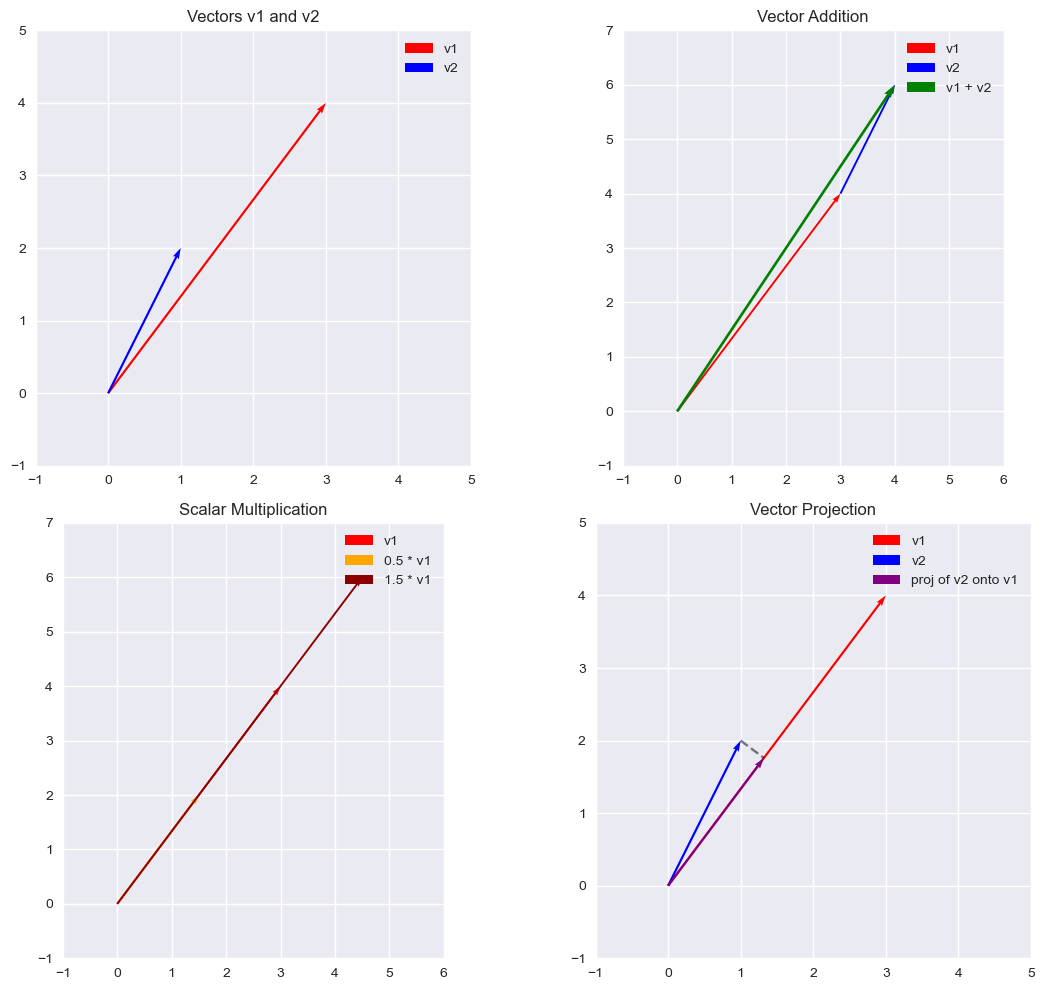

In [3]:
# Visualizing vectors and operations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Basic vectors
ax1 = axes[0, 0]
ax1.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='v1')
ax1.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005, label='v2')
ax1.set_xlim(-1, 5)
ax1.set_ylim(-1, 5)
ax1.grid(True)
ax1.set_aspect('equal')
ax1.set_title('Vectors v1 and v2')
ax1.legend()

# 2. Vector addition
ax2 = axes[0, 1]
v_sum = v1 + v2
ax2.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='v1')
ax2.quiver(v1[0], v1[1], v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005, label='v2')
ax2.quiver(0, 0, v_sum[0], v_sum[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.007, label='v1 + v2')
ax2.set_xlim(-1, 6)
ax2.set_ylim(-1, 7)
ax2.grid(True)
ax2.set_aspect('equal')
ax2.set_title('Vector Addition')
ax2.legend()

# 3. Scalar multiplication
ax3 = axes[1, 0]
v1_scaled = 0.5 * v1
v1_scaled2 = 1.5 * v1
ax3.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='v1')
ax3.quiver(0, 0, v1_scaled[0], v1_scaled[1], angles='xy', scale_units='xy', scale=1, color='orange', width=0.005, label='0.5 * v1')
ax3.quiver(0, 0, v1_scaled2[0], v1_scaled2[1], angles='xy', scale_units='xy', scale=1, color='darkred', width=0.005, label='1.5 * v1')
ax3.set_xlim(-1, 6)
ax3.set_ylim(-1, 7)
ax3.grid(True)
ax3.set_aspect('equal')
ax3.set_title('Scalar Multiplication')
ax3.legend()

# 4. Dot product geometric interpretation
ax4 = axes[1, 1]
ax4.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='v1')
ax4.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005, label='v2')
# Project v2 onto v1
proj_v2_onto_v1 = (np.dot(v2, v1) / np.dot(v1, v1)) * v1
ax4.quiver(0, 0, proj_v2_onto_v1[0], proj_v2_onto_v1[1], angles='xy', scale_units='xy', scale=1, color='purple', width=0.005, label='proj of v2 onto v1')
ax4.plot([v2[0], proj_v2_onto_v1[0]], [v2[1], proj_v2_onto_v1[1]], 'k--', alpha=0.5)
ax4.set_xlim(-1, 5)
ax4.set_ylim(-1, 5)
ax4.grid(True)
ax4.set_aspect('equal')
ax4.set_title('Vector Projection')
ax4.legend()

plt.tight_layout()
plt.show()

### ML Application: Feature Vectors

In ML, data points are represented as vectors in feature space:

Student Feature Vectors:
Features: [study_hours, sleep_hours, previous_grade]
Student 1: [ 8  7 85] -> Exam score: 87
Student 2: [ 6  6 78] -> Exam score: 79
Student 3: [10  8 92] -> Exam score: 94
Student 4: [ 4  5 65] -> Exam score: 67
Student 5: [ 9  7 88] -> Exam score: 90

Student Similarities (dot products):
Student 1 · Student 2 = 6720
Student 1 · Student 3 = 7956
Student 1 · Student 4 = 5592
Student 1 · Student 5 = 7601
Student 2 · Student 3 = 7284
Student 2 · Student 4 = 5124
Student 2 · Student 5 = 6960
Student 3 · Student 4 = 6060
Student 3 · Student 5 = 8242
Student 4 · Student 5 = 5791

Cosine Similarities:
Student 1 & Student 2: 1.000
Student 1 & Student 3: 1.000
Student 1 & Student 4: 0.999
Student 1 & Student 5: 1.000
Student 2 & Student 3: 0.999
Student 2 & Student 4: 1.000
Student 2 & Student 5: 1.000
Student 3 & Student 4: 0.999
Student 3 & Student 5: 1.000
Student 4 & Student 5: 0.999


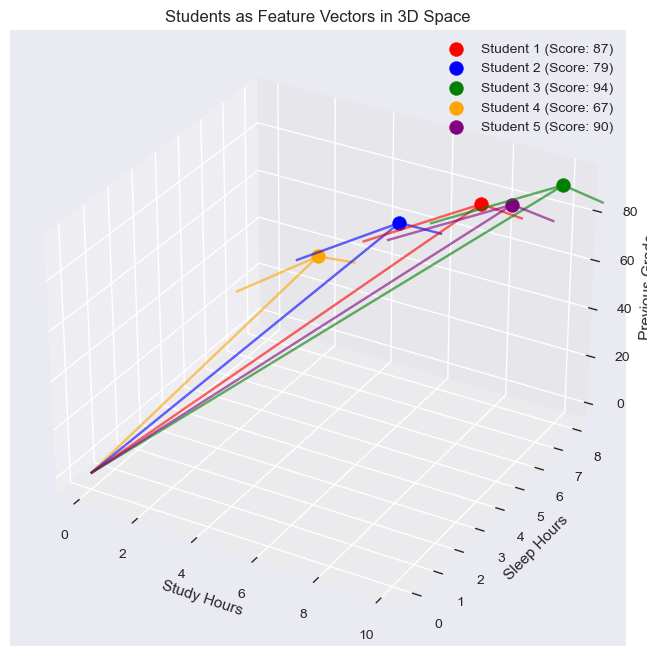

In [4]:
# Example: Representing data as feature vectors
# Student data: [study_hours, sleep_hours, previous_grade]
students = np.array([
    [8, 7, 85],    # Student 1
    [6, 6, 78],    # Student 2
    [10, 8, 92],   # Student 3
    [4, 5, 65],    # Student 4
    [9, 7, 88]     # Student 5
])

exam_scores = np.array([87, 79, 94, 67, 90])

print("Student Feature Vectors:")
print("Features: [study_hours, sleep_hours, previous_grade]")
for i, student in enumerate(students):
    print(f"Student {i+1}: {student} -> Exam score: {exam_scores[i]}")

# Calculate similarity between students using dot product
print("\nStudent Similarities (dot products):")
for i in range(len(students)):
    for j in range(i+1, len(students)):
        similarity = np.dot(students[i], students[j])
        print(f"Student {i+1} · Student {j+1} = {similarity}")

# Normalize vectors for cosine similarity
normalized_students = students / np.linalg.norm(students, axis=1, keepdims=True)
print("\nCosine Similarities:")
for i in range(len(normalized_students)):
    for j in range(i+1, len(normalized_students)):
        cosine_sim = np.dot(normalized_students[i], normalized_students[j])
        print(f"Student {i+1} & Student {j+1}: {cosine_sim:.3f}")

# Visualize in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot student vectors
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, (student, score, color) in enumerate(zip(students, exam_scores, colors)):
    ax.scatter(*student, color=color, s=100, label=f'Student {i+1} (Score: {score})')
    
    # Draw vector from origin
    ax.quiver(0, 0, 0, student[0], student[1], student[2], 
              color=color, alpha=0.6, arrow_length_ratio=0.1)

ax.set_xlabel('Study Hours')
ax.set_ylabel('Sleep Hours')
ax.set_zlabel('Previous Grade')
ax.set_title('Students as Feature Vectors in 3D Space')
ax.legend()
plt.show()

## 2. Matrix Theory and Linear Transformations: The Computational Foundation

### Linear Transformations: From Abstract to Computational

Linear transformations provide the bridge between the abstract theory of vector spaces and the computational reality of machine learning algorithms. Every matrix represents a linear transformation, and every linear transformation between finite-dimensional spaces can be represented by a matrix. This duality forms the cornerstone of computational linear algebra.

#### Definition 2.1: Linear Transformation
A function $T: V \to W$ between vector spaces $V$ and $W$ over the same field $\mathbb{F}$ is **linear** if:
1. **Additivity**: $T(\mathbf{u} + \mathbf{v}) = T(\mathbf{u}) + T(\mathbf{v})$ for all $\mathbf{u}, \mathbf{v} \in V$
2. **Homogeneity**: $T(\alpha \mathbf{v}) = \alpha T(\mathbf{v})$ for all $\mathbf{v} \in V, \alpha \in \mathbb{F}$

Equivalently, $T(\alpha \mathbf{u} + \beta \mathbf{v}) = \alpha T(\mathbf{u}) + \beta T(\mathbf{v})$ for all $\mathbf{u}, \mathbf{v} \in V$ and $\alpha, \beta \in \mathbb{F}$.

#### Theorem 2.1: Matrix Representation Theorem
Let $V$ and $W$ be finite-dimensional vector spaces with ordered bases $\mathcal{B} = \{\mathbf{v}_1, \ldots, \mathbf{v}_n\}$ and $\mathcal{C} = \{\mathbf{w}_1, \ldots, \mathbf{w}_m\}$ respectively. Every linear transformation $T: V \to W$ can be uniquely represented by an $m \times n$ matrix $A$ such that:
$$[T(\mathbf{v})]_{\mathcal{C}} = A[\mathbf{v}]_{\mathcal{B}}$$
where $[\mathbf{v}]_{\mathcal{B}}$ denotes the coordinate vector of $\mathbf{v}$ with respect to basis $\mathcal{B}$.

**Construction**: The $j$-th column of $A$ is $[T(\mathbf{v}_j)]_{\mathcal{C}}$.

### Fundamental Subspaces and the Rank-Nullity Theorem

#### Definition 2.2: Fundamental Subspaces
For matrix $A \in \mathbb{R}^{m \times n}$, we define four fundamental subspaces:

1. **Column Space (Range)**: $\text{col}(A) = \{\mathbf{A}\mathbf{x} : \mathbf{x} \in \mathbb{R}^n\} \subseteq \mathbb{R}^m$
2. **Row Space**: $\text{row}(A) = \text{col}(A^T) \subseteq \mathbb{R}^n$  
3. **Null Space (Kernel)**: $\text{null}(A) = \{\mathbf{x} : A\mathbf{x} = \mathbf{0}\} \subseteq \mathbb{R}^n$
4. **Left Null Space**: $\text{null}(A^T) = \{\mathbf{y} : A^T\mathbf{y} = \mathbf{0}\} \subseteq \mathbb{R}^m$

#### Theorem 2.2: The Fundamental Theorem of Linear Algebra (Rank-Nullity)
For any matrix $A \in \mathbb{R}^{m \times n}$:
$$\text{rank}(A) + \text{nullity}(A) = n$$
where $\text{rank}(A) = \dim(\text{col}(A))$ and $\text{nullity}(A) = \dim(\text{null}(A))$.

**Extended Form**: The four fundamental subspaces satisfy:
- $\dim(\text{col}(A)) = \dim(\text{row}(A)) = \text{rank}(A)$
- $\dim(\text{null}(A)) = n - \text{rank}(A)$
- $\dim(\text{null}(A^T)) = m - \text{rank}(A)$
- $\text{row}(A) \perp \text{null}(A)$ and $\text{col}(A) \perp \text{null}(A^T)$

#### Machine Learning Significance
This theorem has profound implications for ML:
- **Model Capacity**: The rank determines the effective dimensionality of a linear model
- **Feature Redundancy**: Null space vectors represent feature combinations that don't affect output
- **Regularization**: Adding constraints often means projecting onto lower-dimensional subspaces
- **Data Analysis**: Principal components lie in the row space; noise often lies in the null space

### Matrix Operations and Algebraic Structure

#### Definition 2.3: Matrix Algebra
The set $\mathbb{R}^{m \times n}$ forms a vector space under matrix addition and scalar multiplication:
- $(A + B)_{ij} = A_{ij} + B_{ij}$
- $(\alpha A)_{ij} = \alpha A_{ij}$

For square matrices, $\mathbb{R}^{n \times n}$ forms a **ring** under addition and multiplication:
$$(AB)_{ij} = \sum_{k=1}^n A_{ik}B_{kj}$$

**Properties of Matrix Multiplication**:
1. **Associativity**: $(AB)C = A(BC)$
2. **Distributivity**: $A(B + C) = AB + AC$
3. **Non-commutativity**: Generally $AB \neq BA$
4. **Zero Divisors**: $AB = 0$ doesn't imply $A = 0$ or $B = 0$

#### Theorem 2.3: Properties of Matrix Operations
For matrices $A, B, C$ of appropriate dimensions:
1. **Transpose Properties**: $(A + B)^T = A^T + B^T$, $(AB)^T = B^T A^T$
2. **Rank Properties**: $\text{rank}(AB) \leq \min(\text{rank}(A), \text{rank}(B))$
3. **Determinant Properties** (square matrices): $\det(AB) = \det(A)\det(B)$
4. **Trace Properties** (square matrices): $\text{tr}(A + B) = \text{tr}(A) + \text{tr}(B)$, $\text{tr}(AB) = \text{tr}(BA)$

### Special Matrix Classes and Their Properties

#### Definition 2.4: Important Matrix Classes

**1. Symmetric Matrices**: $A = A^T$
- **Property**: Real eigenvalues, orthogonal eigenvectors
- **ML Application**: Covariance matrices, kernel matrices

**2. Orthogonal Matrices**: $Q^T Q = I$
- **Property**: Preserves lengths and angles
- **ML Application**: Rotation transformations, QR decomposition

**3. Positive Definite Matrices**: $\mathbf{x}^T A \mathbf{x} > 0$ for all $\mathbf{x} \neq \mathbf{0}$
- **Property**: All eigenvalues positive, Cholesky decomposition exists
- **ML Application**: Convex optimization, Gaussian processes

**4. Unitary Matrices** (complex): $U^* U = I$ where $U^*$ is conjugate transpose
- **Property**: Preserves inner products in complex spaces
- **ML Application**: Quantum machine learning, Fourier transforms

#### Theorem 2.4: Spectral Theorem for Symmetric Matrices
Every real symmetric matrix $A$ can be diagonalized by an orthogonal matrix:
$$A = Q \Lambda Q^T$$
where $Q$ is orthogonal and $\Lambda$ is diagonal with real eigenvalues.

**Geometric Interpretation**: Symmetric matrices represent transformations along orthogonal principal axes.

### Matrix Norms and Condition Numbers

#### Definition 2.5: Matrix Norms
A **matrix norm** $||\cdot||$ on $\mathbb{R}^{m \times n}$ satisfies:
1. $||A|| \geq 0$ with equality iff $A = 0$
2. $||\alpha A|| = |\alpha| \cdot ||A||$ for scalar $\alpha$
3. $||A + B|| \leq ||A|| + ||B||$ (triangle inequality)
4. $||AB|| \leq ||A|| \cdot ||B||$ (submultiplicativity for compatible dimensions)

**Important Matrix Norms**:
- **Frobenius Norm**: $||A||_F = \sqrt{\sum_{i,j} a_{ij}^2} = \sqrt{\text{tr}(A^T A)}$
- **Spectral Norm**: $||A||_2 = \sigma_{\max}(A)$ (largest singular value)
- **Nuclear Norm**: $||A||_* = \sum_i \sigma_i(A)$ (sum of singular values)
- **Max Norm**: $||A||_{\max} = \max_{i,j} |a_{ij}|$

#### Definition 2.6: Condition Number
For invertible matrix $A$, the **condition number** with respect to norm $||\cdot||$ is:
$$\kappa(A) = ||A|| \cdot ||A^{-1}||$$

**Interpretation**: Measures sensitivity of linear systems to perturbations.
- $\kappa(A) = 1$: Perfectly conditioned (orthogonal matrices)
- $\kappa(A) \gg 1$: Ill-conditioned (near-singular matrices)

#### Theorem 2.5: Perturbation Analysis
For linear system $A\mathbf{x} = \mathbf{b}$ with perturbed version $(A + \delta A)(\mathbf{x} + \delta \mathbf{x}) = \mathbf{b} + \delta \mathbf{b}$:
$$\frac{||\delta \mathbf{x}||}{||\mathbf{x}||} \leq \kappa(A) \left( \frac{||\delta A||}{||A||} + \frac{||\delta \mathbf{b}||}{||\mathbf{b}||} \right)$$

**ML Implications**: Condition number affects:
- **Numerical Stability**: Of matrix computations and optimization algorithms
- **Generalization**: Ill-conditioned problems often overfit
- **Regularization**: Adding $\lambda I$ improves conditioning

### Computational Complexity and Matrix Algorithms

#### Matrix Multiplication Complexity
**Standard Algorithm**: $O(n^3)$ operations for $n \times n$ matrices
**Strassen's Algorithm**: $O(n^{\log_2 7}) \approx O(n^{2.807})$
**Current Best**: $O(n^{2.373})$ (highly impractical)

**Practical Considerations**:
- **Memory Hierarchy**: Cache-efficient algorithms
- **Parallelization**: Block-wise computation, GPU acceleration
- **Sparsity**: Specialized algorithms for sparse matrices

#### Theorem 2.6: Fast Matrix Multiplication Lower Bounds
The **matrix multiplication exponent** $\omega$ satisfies $2 \leq \omega \leq 3$.
- **Conjecture**: $\omega = 2$ (still open)
- **Practical Impact**: Current algorithms with $\omega < 3$ have large constants

This directly impacts ML scalability, as matrix operations dominate computational cost in:
- **Deep Learning**: Forward/backward propagation
- **Kernel Methods**: Kernel matrix computations  
- **Dimensionality Reduction**: SVD, eigendecomposition
- **Optimization**: Hessian computations, preconditioned methods

In [5]:
# Matrix operations
A = np.array([[2, 1, 3],
              [1, 4, 2],
              [3, 2, 1]])

B = np.array([[1, 2],
              [3, 1],
              [2, 4]])

C = np.array([[2, 0, 1],
              [1, 3, 2],
              [0, 1, 4]])

print("Matrix A (3×3):")
print(A)
print(f"Shape: {A.shape}")

print("\nMatrix B (3×2):")
print(B)
print(f"Shape: {B.shape}")

# Matrix multiplication
AB = A @ B  # or np.dot(A, B)
print(f"\nA × B = ")
print(AB)
print(f"Result shape: {AB.shape}")

# Matrix addition (same dimensions)
A_plus_C = A + C
print(f"\nA + C = ")
print(A_plus_C)

# Matrix transpose
AT = A.T
print(f"\nA^T = ")
print(AT)

# Matrix inverse
A_inv = np.linalg.inv(A)
print(f"\nA^(-1) = ")
print(A_inv)

# Verify inverse
I_check = A @ A_inv
print(f"\nA × A^(-1) = ")
print(I_check)
print(f"(Should be close to identity matrix)")

Matrix A (3×3):
[[2 1 3]
 [1 4 2]
 [3 2 1]]
Shape: (3, 3)

Matrix B (3×2):
[[1 2]
 [3 1]
 [2 4]]
Shape: (3, 2)

A × B = 
[[11 17]
 [17 14]
 [11 12]]
Result shape: (3, 2)

A + C = 
[[4 1 4]
 [2 7 4]
 [3 3 5]]

A^T = 
[[2 1 3]
 [1 4 2]
 [3 2 1]]

A^(-1) = 
[[ 0.   -0.2   0.4 ]
 [-0.2   0.28  0.04]
 [ 0.4   0.04 -0.28]]

A × A^(-1) = 
[[ 1.00000000e+00 -1.38777878e-17  5.55111512e-17]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -4.16333634e-17  1.00000000e+00]]
(Should be close to identity matrix)


### Matrix Properties

In [6]:
# Important matrix properties
print("Matrix Properties:")

# Determinant
det_A = np.linalg.det(A)
print(f"det(A) = {det_A:.3f}")

# Trace (sum of diagonal elements)
trace_A = np.trace(A)
print(f"tr(A) = {trace_A}")

# Rank
rank_A = np.linalg.matrix_rank(A)
print(f"rank(A) = {rank_A}")

# Frobenius norm
frobenius_norm = np.linalg.norm(A, 'fro')
print(f"||A||_F = {frobenius_norm:.3f}")

# Check if matrix is symmetric
is_symmetric = np.allclose(A, A.T)
print(f"Is A symmetric? {is_symmetric}")

# Create a symmetric matrix
S = A + A.T
is_S_symmetric = np.allclose(S, S.T)
print(f"\nS = A + A^T:")
print(S)
print(f"Is S symmetric? {is_S_symmetric}")

# Orthogonal matrix example
Q, R = np.linalg.qr(A)
print(f"\nQ (orthogonal matrix from QR decomposition):")
print(Q)
print(f"Q^T × Q = ")
print(Q.T @ Q)
print(f"(Should be close to identity for orthogonal matrix)")

Matrix Properties:
det(A) = -25.000
tr(A) = 7
rank(A) = 3
||A||_F = 7.000
Is A symmetric? True

S = A + A^T:
[[4 2 6]
 [2 8 4]
 [6 4 2]]
Is S symmetric? True

Q (orthogonal matrix from QR decomposition):
[[-0.53452248  0.21821789 -0.81649658]
 [-0.26726124 -0.96015872 -0.08164966]
 [-0.80178373  0.17457431  0.57154761]]
Q^T × Q = 
[[ 1.00000000e+00  6.30274692e-17 -1.50935962e-16]
 [ 6.30274692e-17  1.00000000e+00  2.48823972e-17]
 [-1.50935962e-16  2.48823972e-17  1.00000000e+00]]
(Should be close to identity for orthogonal matrix)


### ML Application: Data Transformation

Matrices are used to transform data in various ways:

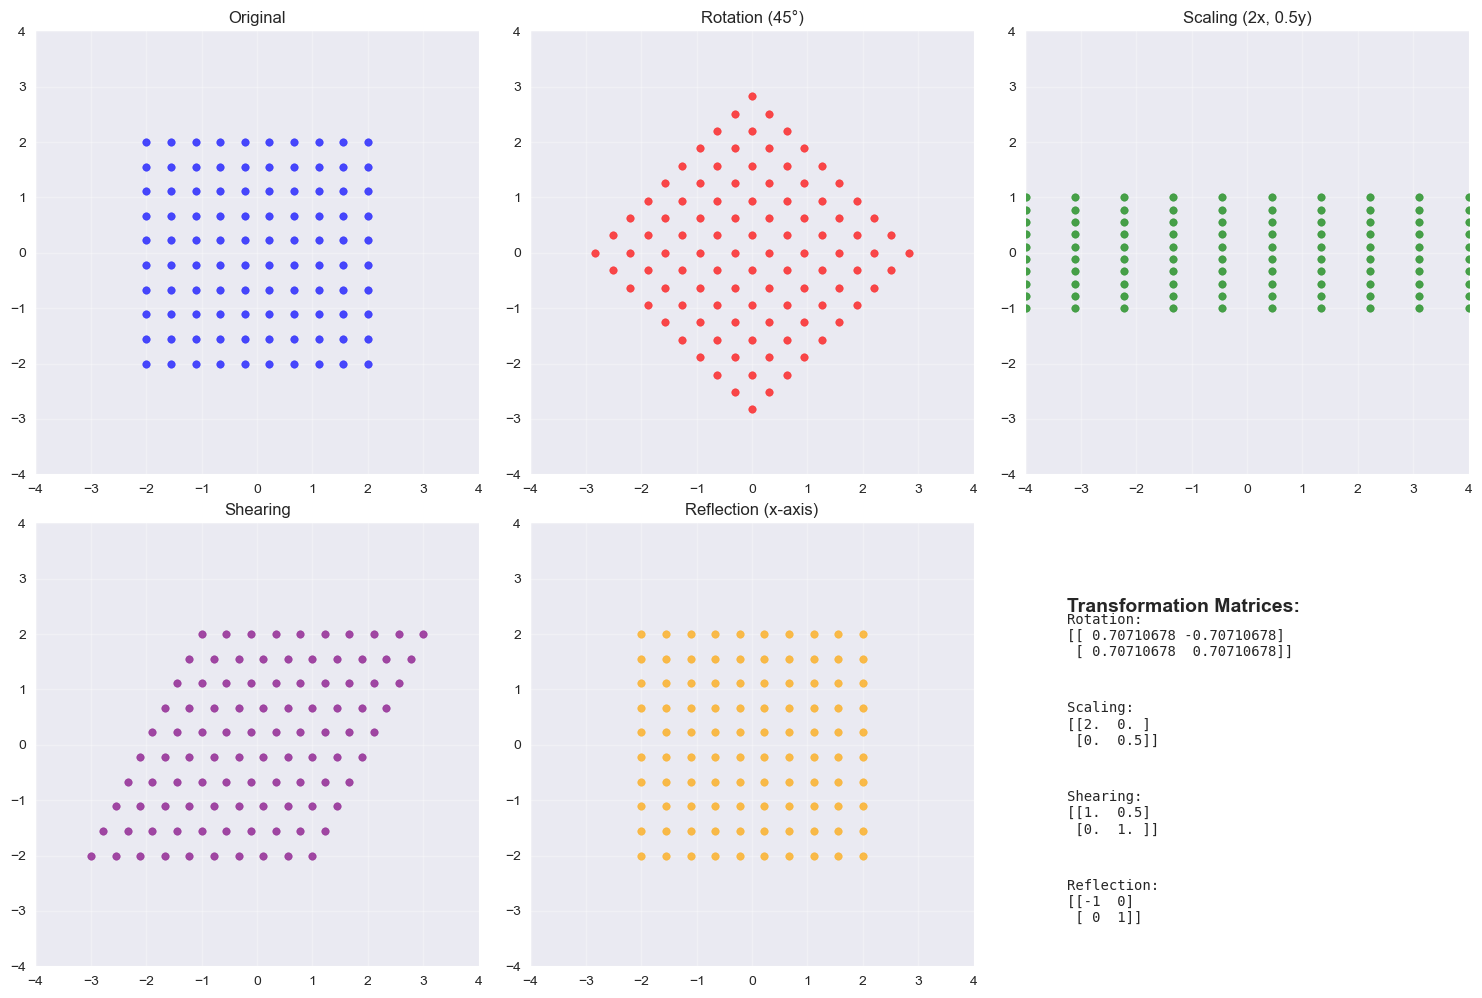

Matrix Transformations in ML:
• Rotation: Feature rotation in PCA
• Scaling: Feature normalization/standardization
• Shearing: Data augmentation in computer vision
• Reflection: Data augmentation, creating symmetric datasets


In [7]:
# Example: Image transformation using matrices
# Create a simple 2D "image" (grid of points)
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
X_grid, Y_grid = np.meshgrid(x, y)
points = np.vstack([X_grid.ravel(), Y_grid.ravel()])

# Transformation matrices
rotation_45 = np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
                        [np.sin(np.pi/4), np.cos(np.pi/4)]])

scaling = np.array([[2, 0],
                    [0, 0.5]])

shearing = np.array([[1, 0.5],
                     [0, 1]])

reflection = np.array([[-1, 0],
                       [0, 1]])

# Apply transformations
points_rotated = rotation_45 @ points
points_scaled = scaling @ points
points_sheared = shearing @ points
points_reflected = reflection @ points

# Visualize transformations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

transformations = [
    (points, 'Original', 'blue'),
    (points_rotated, 'Rotation (45°)', 'red'),
    (points_scaled, 'Scaling (2x, 0.5y)', 'green'),
    (points_sheared, 'Shearing', 'purple'),
    (points_reflected, 'Reflection (x-axis)', 'orange')
]

for i, (pts, title, color) in enumerate(transformations):
    axes[i].scatter(pts[0], pts[1], c=color, s=30, alpha=0.7)
    axes[i].set_title(title)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-4, 4)
    axes[i].set_ylim(-4, 4)
    axes[i].set_aspect('equal')

# Show transformation matrices
axes[5].text(0.1, 0.8, 'Transformation Matrices:', fontsize=14, weight='bold')
axes[5].text(0.1, 0.7, f'Rotation:\n{rotation_45}', fontsize=10, family='monospace')
axes[5].text(0.1, 0.5, f'Scaling:\n{scaling}', fontsize=10, family='monospace')
axes[5].text(0.1, 0.3, f'Shearing:\n{shearing}', fontsize=10, family='monospace')
axes[5].text(0.1, 0.1, f'Reflection:\n{reflection}', fontsize=10, family='monospace')
axes[5].axis('off')

plt.tight_layout()
plt.show()

# Show how these relate to ML preprocessing
print("Matrix Transformations in ML:")
print("• Rotation: Feature rotation in PCA")
print("• Scaling: Feature normalization/standardization")
print("• Shearing: Data augmentation in computer vision")
print("• Reflection: Data augmentation, creating symmetric datasets")

## 3. Eigenvalues and Eigenvectors

Eigenvalues and eigenvectors reveal the fundamental directions and magnitudes of linear transformations, crucial for PCA and many ML algorithms.

In [9]:
# Eigenvalue decomposition
A_symmetric = np.array([[4, 2],
                        [2, 3]])

print("Matrix A:")
print(A_symmetric)

# Compute eigenvalues and eigenvectors
eigenvals, eigenvecs = np.linalg.eig(A_symmetric)

# Sort by eigenvalue magnitude
idx = np.argsort(eigenvals)[::-1]
eigenvals = eigenvals[idx]
eigenvecs = eigenvecs[:, idx]

print(f"\nEigenvalues: {eigenvals}")
print(f"Eigenvectors:")
for i, (val, vec) in enumerate(zip(eigenvals, eigenvecs.T)):
    print(f"λ{i+1} = {val:.3f}, v{i+1} = {vec}")

# Verify eigenvector property: Av = λv
print(f"\nVerification (Av = λv):")
for i, (val, vec) in enumerate(zip(eigenvals, eigenvecs.T)):
    Av = A_symmetric @ vec
    lambda_v = val * vec
    print(f"A*v{i+1} = {Av}")
    print(f"λ{i+1}*v{i+1} = {lambda_v}")
    print(f"Equal? {np.allclose(Av, lambda_v)}\n")

Matrix A:
[[4 2]
 [2 3]]

Eigenvalues: [5.56155281 1.43844719]
Eigenvectors:
λ1 = 5.562, v1 = [0.78820544 0.61541221]
λ2 = 1.438, v2 = [-0.61541221  0.78820544]

Verification (Av = λv):
A*v1 = [4.38364617 3.4226475 ]
λ1*v1 = [4.38364617 3.4226475 ]
Equal? True

A*v2 = [-0.88523796  1.1337919 ]
λ2*v2 = [-0.88523796  1.1337919 ]
Equal? True



### Geometric Interpretation of Eigenvalues and Eigenvectors

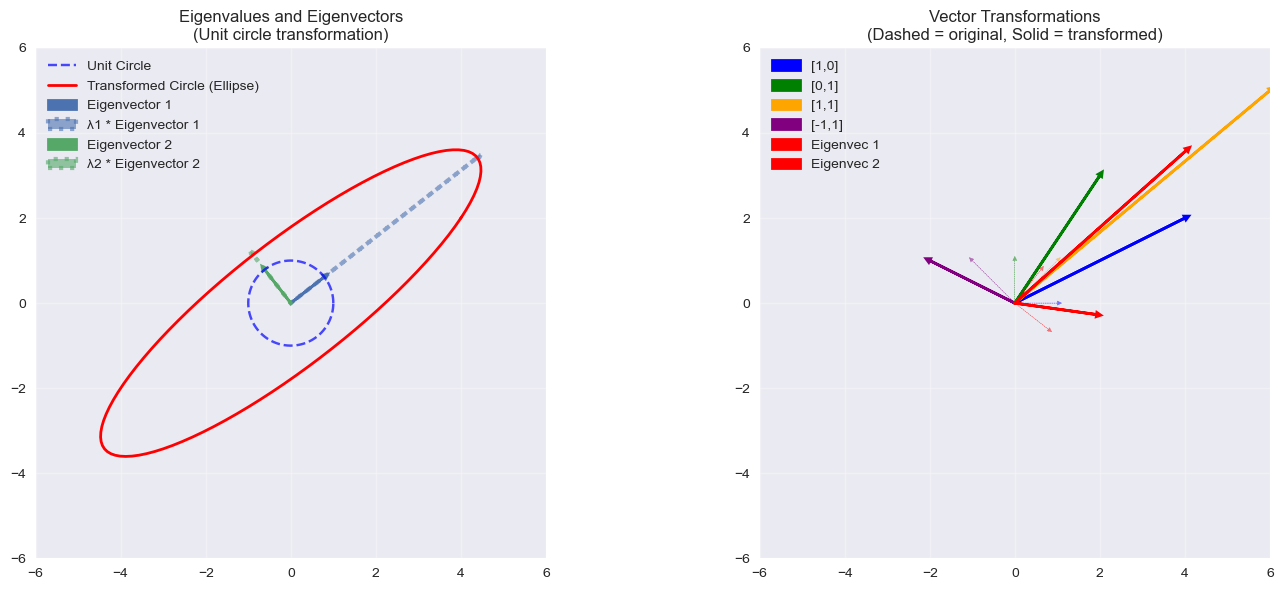

Key Insights:
• Eigenvalue λ₁ = 5.562: stretches along eigenvector 1 direction
• Eigenvalue λ₂ = 1.438: stretches along eigenvector 2 direction
• Eigenvectors remain in the same direction after transformation
• Other vectors change direction (unless parallel to eigenvectors)


In [10]:
# Visualize eigenvalues and eigenvectors
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Create unit circle points
theta = np.linspace(0, 2*np.pi, 100)
unit_circle = np.array([np.cos(theta), np.sin(theta)])

# Transform unit circle
transformed_circle = A_symmetric @ unit_circle

# Plot 1: Original and transformed unit circle
ax1 = axes[0]
ax1.plot(unit_circle[0], unit_circle[1], 'b--', label='Unit Circle', alpha=0.7)
ax1.plot(transformed_circle[0], transformed_circle[1], 'r-', label='Transformed Circle (Ellipse)', linewidth=2)

# Plot eigenvectors
for i, (val, vec) in enumerate(zip(eigenvals, eigenvecs.T)):
    ax1.arrow(0, 0, vec[0], vec[1], head_width=0.1, head_length=0.1, 
              fc=f'C{i}', ec=f'C{i}', linewidth=2, label=f'Eigenvector {i+1}')
    ax1.arrow(0, 0, val*vec[0], val*vec[1], head_width=0.1, head_length=0.1, 
              fc=f'C{i}', ec=f'C{i}', linewidth=3, alpha=0.6, linestyle=':', 
              label=f'λ{i+1} * Eigenvector {i+1}')

ax1.set_xlim(-6, 6)
ax1.set_ylim(-6, 6)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_title('Eigenvalues and Eigenvectors\n(Unit circle transformation)')

# Plot 2: Show how eigenvectors are special directions
ax2 = axes[1]

# Create several vectors and show their transformations
test_vectors = np.array([[1, 0], [0, 1], [1, 1], [-1, 1], 
                         eigenvecs[0], eigenvecs[1]]).T
transformed_vectors = A_symmetric @ test_vectors

colors = ['blue', 'green', 'orange', 'purple', 'red', 'red']
labels = ['[1,0]', '[0,1]', '[1,1]', '[-1,1]', 'Eigenvec 1', 'Eigenvec 2']

for i, (orig, trans, color, label) in enumerate(zip(test_vectors.T, transformed_vectors.T, colors, labels)):
    # Original vector
    ax2.arrow(0, 0, orig[0], orig[1], head_width=0.1, head_length=0.1, 
              fc=color, ec=color, alpha=0.5, linestyle='--')
    # Transformed vector
    ax2.arrow(0, 0, trans[0], trans[1], head_width=0.1, head_length=0.1, 
              fc=color, ec=color, linewidth=2, label=label)

ax2.set_xlim(-6, 6)
ax2.set_ylim(-6, 6)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_title('Vector Transformations\n(Dashed = original, Solid = transformed)')

plt.tight_layout()
plt.show()

# Show key insights
print("Key Insights:")
print(f"• Eigenvalue λ₁ = {eigenvals[0]:.3f}: stretches along eigenvector 1 direction")
print(f"• Eigenvalue λ₂ = {eigenvals[1]:.3f}: stretches along eigenvector 2 direction")
print(f"• Eigenvectors remain in the same direction after transformation")
print(f"• Other vectors change direction (unless parallel to eigenvectors)")

### ML Application: Covariance Matrix and Data Spread

Sample covariance matrix:
[[3.69782237 1.8535846 ]
 [1.8535846  2.91852455]]

True covariance matrix:
[[4 2]
 [2 3]]

Covariance eigenvalues: [5.20227012 1.41407681]
Covariance eigenvectors:
[[ 0.77643981 -0.63019142]
 [ 0.63019142  0.77643981]]


/var/folders/xv/tv1bmbcs1xdgcyhnk82x4xp00000gp/T/ipykernel_54908/1754113181.py:65: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/xv/tv1bmbcs1xdgcyhnk82x4xp00000gp/T/ipykernel_54908/1754113181.py:65: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ruichaowang/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ruichaowang/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


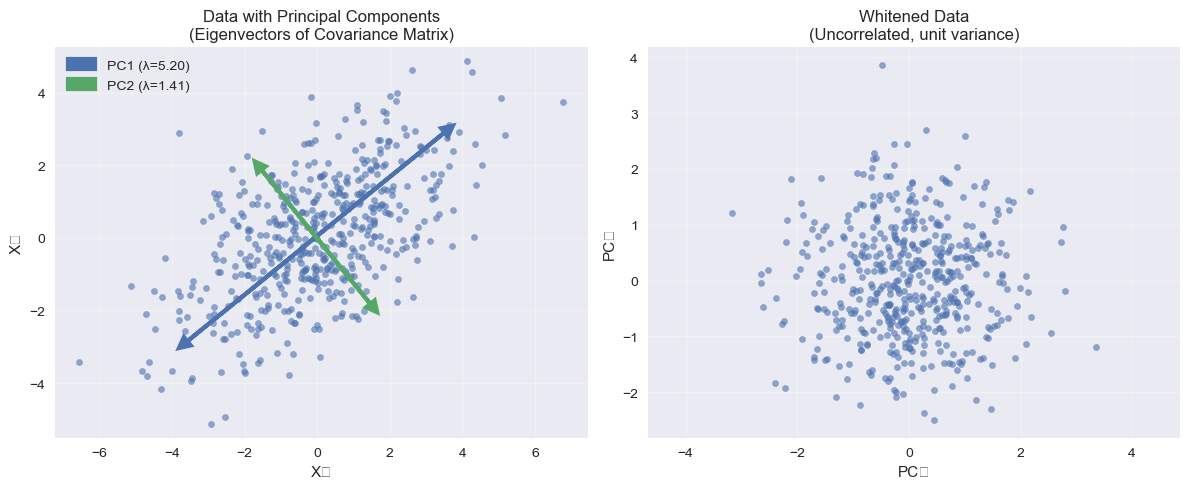


Whitened data covariance matrix:
[[ 1.00000000e+00 -5.69573335e-17]
 [-5.69573335e-17  1.00000000e+00]]
(Should be close to identity matrix)


In [11]:
# Generate correlated 2D data
np.random.seed(42)
mean = [0, 0]
cov = [[4, 2], [2, 3]]  # This is our A_symmetric matrix!
data = np.random.multivariate_normal(mean, cov, 500)

# Calculate sample covariance matrix
sample_cov = np.cov(data.T)
print("Sample covariance matrix:")
print(sample_cov)
print("\nTrue covariance matrix:")
print(np.array(cov))

# Eigendecomposition of covariance matrix
cov_eigenvals, cov_eigenvecs = np.linalg.eig(sample_cov)
idx = np.argsort(cov_eigenvals)[::-1]
cov_eigenvals = cov_eigenvals[idx]
cov_eigenvecs = cov_eigenvecs[:, idx]

print(f"\nCovariance eigenvalues: {cov_eigenvals}")
print(f"Covariance eigenvectors:")
print(cov_eigenvecs)

# Visualize
plt.figure(figsize=(12, 5))

# Plot 1: Data with eigenvectors
plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, s=20)

# Plot eigenvectors (scaled by square root of eigenvalues)
mean_point = np.mean(data, axis=0)
for i, (val, vec) in enumerate(zip(cov_eigenvals, cov_eigenvecs.T)):
    # Scale by square root of eigenvalue for visualization
    length = 2 * np.sqrt(val)
    plt.arrow(mean_point[0], mean_point[1], length*vec[0], length*vec[1], 
              head_width=0.3, head_length=0.3, fc=f'C{i}', ec=f'C{i}', 
              linewidth=3, label=f'PC{i+1} (λ={val:.2f})')
    plt.arrow(mean_point[0], mean_point[1], -length*vec[0], -length*vec[1], 
              head_width=0.3, head_length=0.3, fc=f'C{i}', ec=f'C{i}', linewidth=3)

plt.xlabel('X₁')
plt.ylabel('X₂')
plt.title('Data with Principal Components\n(Eigenvectors of Covariance Matrix)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 2: Transformed data (whitened)
plt.subplot(1, 2, 2)
# Whiten the data: transform to principal component coordinates and scale
centered_data = data - mean_point
# Project onto eigenvectors
transformed_data = centered_data @ cov_eigenvecs
# Scale by inverse square root of eigenvalues
whitened_data = transformed_data / np.sqrt(cov_eigenvals)

plt.scatter(whitened_data[:, 0], whitened_data[:, 1], alpha=0.6, s=20)
plt.xlabel('PC₁')
plt.ylabel('PC₂')
plt.title('Whitened Data\n(Uncorrelated, unit variance)')
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.show()

# Verify whitening
whitened_cov = np.cov(whitened_data.T)
print(f"\nWhitened data covariance matrix:")
print(whitened_cov)
print("(Should be close to identity matrix)")

## 4. Singular Value Decomposition (SVD)

SVD is one of the most important matrix decompositions in ML, used in PCA, recommender systems, and dimensionality reduction.

In [12]:
# SVD example
# Create a matrix (doesn't need to be square)
M = np.array([[4, 2, 1],
              [2, 3, 1],
              [1, 1, 2],
              [1, 0, 1]])

print(f"Original matrix M ({M.shape}):")
print(M)

# Perform SVD: M = U Σ V^T
U, sigma, VT = np.linalg.svd(M, full_matrices=False)

print(f"\nSVD Decomposition:")
print(f"U shape: {U.shape}")
print(f"σ shape: {sigma.shape}")
print(f"V^T shape: {VT.shape}")

print(f"\nSingular values: {sigma}")
print(f"\nU matrix (left singular vectors):")
print(U)
print(f"\nV^T matrix (right singular vectors):")
print(VT)

# Reconstruct original matrix
Sigma_matrix = np.diag(sigma)
M_reconstructed = U @ Sigma_matrix @ VT

print(f"\nReconstructed matrix:")
print(M_reconstructed)
print(f"\nReconstruction error: {np.linalg.norm(M - M_reconstructed)}")

# Verify orthogonality properties
print(f"\nOrthogonality checks:")
print(f"U^T U = \n{U.T @ U}")
print(f"V^T V = \n{VT @ VT.T}")
print("(Should be identity matrices)")

Original matrix M ((4, 3)):
[[4 2 1]
 [2 3 1]
 [1 1 2]
 [1 0 1]]

SVD Decomposition:
U shape: (4, 3)
σ shape: (3,)
V^T shape: (3, 3)

Singular values: [6.14422344 1.66905559 1.56932206]

U matrix (left singular vectors):
[[-0.72648049 -0.44829667  0.45768999]
 [-0.57764541 -0.0067944  -0.75482086]
 [-0.32716397  0.8364823   0.06381148]
 [-0.17752637  0.31508934  0.46550343]]

V^T matrix (right singular vectors):
[[-0.74312127 -0.57176651 -0.34764039]
 [-0.39255962 -0.04822742  0.91846125]
 [ 0.54191118 -0.81899767  0.18861362]]

Reconstructed matrix:
[[4.00000000e+00 2.00000000e+00 1.00000000e+00]
 [2.00000000e+00 3.00000000e+00 1.00000000e+00]
 [1.00000000e+00 1.00000000e+00 2.00000000e+00]
 [1.00000000e+00 7.28724213e-16 1.00000000e+00]]

Reconstruction error: 5.332634761562882e-15

Orthogonality checks:
U^T U = 
[[ 1.00000000e+00  2.07841562e-16 -1.21920268e-16]
 [ 2.07841562e-16  1.00000000e+00  5.48971177e-17]
 [-1.21920268e-16  5.48971177e-17  1.00000000e+00]]
V^T V = 
[[ 1.00000

### Low-Rank Approximation with SVD

Original matrix shape: (50, 40)
True rank: 3
Actual rank: 40

Singular values (first 10): [57.72663962 45.88469694 29.62896182  6.5122721   5.58805892  5.30248504
  5.22685701  4.95166792  4.66383518  4.60777527]


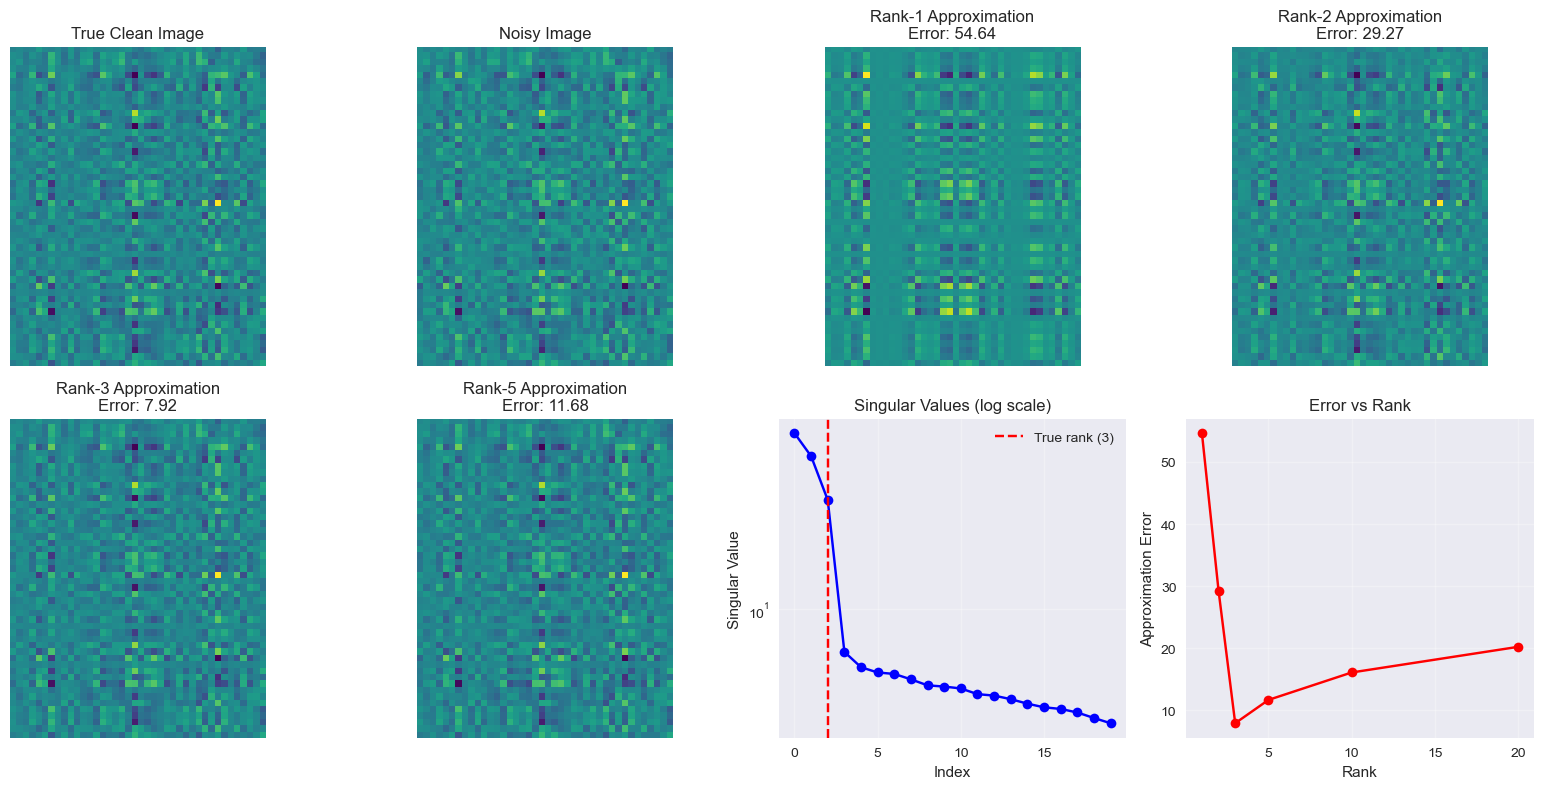


Key observations:
• Rank-3 approximation captures most of the structure
• Higher ranks reduce noise while preserving signal
• SVD provides optimal low-rank approximation (in Frobenius norm sense)


In [16]:
# Low-rank approximation using SVD
# Create a synthetic image-like matrix
np.random.seed(42)
true_rank = 3
m, n = 50, 40

# Create a low-rank matrix with some noise
U_true = np.random.randn(m, true_rank)
V_true = np.random.randn(true_rank, n)
Image_clean = U_true @ V_true
noise = 0.5 * np.random.randn(m, n)
Image_noisy = Image_clean + noise

print(f"Original matrix shape: {Image_noisy.shape}")
print(f"True rank: {true_rank}")
print(f"Actual rank: {np.linalg.matrix_rank(Image_noisy)}")

# Perform SVD
U, sigma, VT = np.linalg.svd(Image_noisy, full_matrices=False)

print(f"\nSingular values (first 10): {sigma[:10]}")

# Create approximations with different ranks
ranks_to_try = [1, 2, 3, 5, 10, 20]
approximations = {}
errors = {}

for k in ranks_to_try:
    # Low-rank approximation: use only first k singular values/vectors
    U_k = U[:, :k]
    sigma_k = sigma[:k]
    VT_k = VT[:k, :]
    
    approximations[k] = U_k @ np.diag(sigma_k) @ VT_k
    errors[k] = np.linalg.norm(Image_clean - approximations[k], 'fro')

# Visualize results
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

# Original images
im1 = axes[0].imshow(Image_clean, cmap='viridis')
axes[0].set_title('True Clean Image')
axes[0].axis('off')

im2 = axes[1].imshow(Image_noisy, cmap='viridis')
axes[1].set_title('Noisy Image')
axes[1].axis('off')

# Approximations
for i, k in enumerate([1, 2, 3, 5]):
    im = axes[i+2].imshow(approximations[k], cmap='viridis')
    axes[i+2].set_title(f'Rank-{k} Approximation\nError: {errors[k]:.2f}')
    axes[i+2].axis('off')

# Singular values plot
axes[6].semilogy(sigma[:20], 'bo-')
axes[6].axvline(x=true_rank-1, color='red', linestyle='--', label=f'True rank ({true_rank})')
axes[6].set_xlabel('Index')
axes[6].set_ylabel('Singular Value')
axes[6].set_title('Singular Values (log scale)')
axes[6].legend()
axes[6].grid(True, alpha=0.3)

# Error vs rank plot
axes[7].plot(ranks_to_try, [errors[k] for k in ranks_to_try], 'ro-')
axes[7].set_xlabel('Rank')
axes[7].set_ylabel('Approximation Error')
axes[7].set_title('Error vs Rank')
axes[7].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey observations:")
print(f"• Rank-{true_rank} approximation captures most of the structure")
print(f"• Higher ranks reduce noise while preserving signal")
print(f"• SVD provides optimal low-rank approximation (in Frobenius norm sense)")

## 5. Principal Component Analysis (PCA)

PCA is one of the most important applications of linear algebra in ML, used for dimensionality reduction and data visualization.

In [17]:
# PCA implementation from scratch
def pca_from_scratch(X, n_components=2):
    """
    Implement PCA from scratch using eigenvalue decomposition
    """
    # Step 1: Center the data
    X_centered = X - np.mean(X, axis=0)
    
    # Step 2: Compute covariance matrix
    cov_matrix = (X_centered.T @ X_centered) / (X.shape[0] - 1)
    
    # Step 3: Eigenvalue decomposition
    eigenvals, eigenvecs = np.linalg.eig(cov_matrix)
    
    # Step 4: Sort by eigenvalue (descending)
    idx = np.argsort(eigenvals)[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]
    
    # Step 5: Select top n_components
    components = eigenvecs[:, :n_components]
    
    # Step 6: Transform data
    X_pca = X_centered @ components
    
    # Calculate explained variance ratio
    total_var = np.sum(eigenvals)
    explained_var_ratio = eigenvals[:n_components] / total_var
    
    return X_pca, components, explained_var_ratio, eigenvals

# Load Iris dataset for demonstration
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Iris dataset shape: {X_iris.shape}")
print(f"Features: {feature_names}")
print(f"Classes: {target_names}")

# Apply our PCA implementation
X_pca_manual, components, explained_var_ratio, eigenvals = pca_from_scratch(X_iris, n_components=2)

print(f"\nPCA Results:")
print(f"Explained variance ratio: {explained_var_ratio}")
print(f"Total variance explained: {np.sum(explained_var_ratio):.3f}")
print(f"\nPrincipal components (loadings):")
for i, component in enumerate(components.T):
    print(f"PC{i+1}: {component}")
    
# Compare with sklearn implementation
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)
pca_sklearn = PCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_iris_scaled)

print(f"\nSklearn PCA explained variance ratio: {pca_sklearn.explained_variance_ratio_}")

Iris dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

PCA Results:
Explained variance ratio: [0.92461872 0.05306648]
Total variance explained: 0.978

Principal components (loadings):
PC1: [ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
PC2: [-0.65658877 -0.73016143  0.17337266  0.07548102]

Sklearn PCA explained variance ratio: [0.72962445 0.22850762]


### PCA Visualization and Interpretation

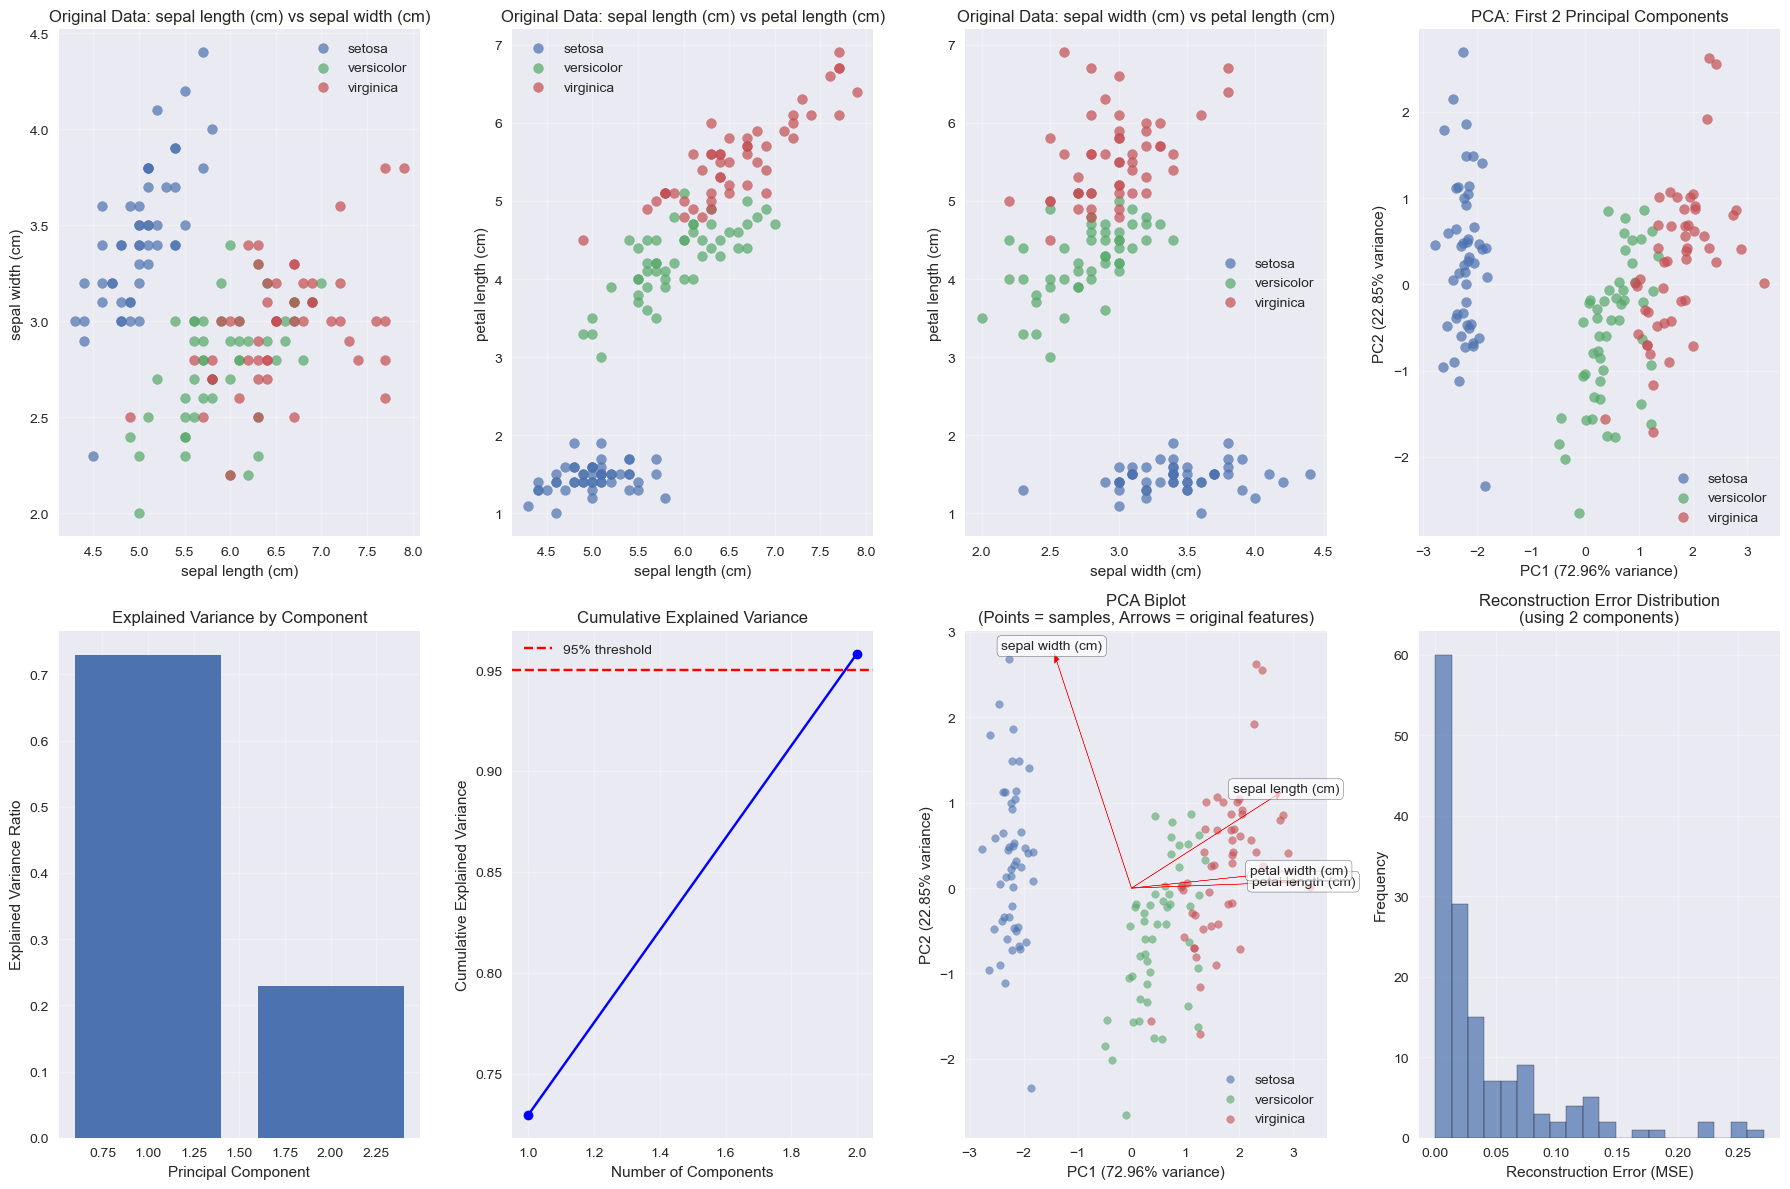


PCA Component Interpretation:
Component loadings (contributions of original features):

PC1 (72.96% variance):
  sepal length (cm): +0.521
  sepal width (cm): -0.269
  petal length (cm): +0.580
  petal width (cm): +0.565

PC2 (22.85% variance):
  sepal length (cm): +0.377
  sepal width (cm): +0.923
  petal length (cm): +0.024
  petal width (cm): +0.067

Total variance explained by 2 components: 95.81%
Average reconstruction error: 0.0419


In [18]:
# Comprehensive PCA visualization
fig = plt.figure(figsize=(18, 12))

# 1. Original data in 2D projections
feature_pairs = [(0, 1), (0, 2), (1, 2)]
pair_names = [(feature_names[i], feature_names[j]) for i, j in feature_pairs]

for idx, ((i, j), (name_i, name_j)) in enumerate(zip(feature_pairs, pair_names)):
    ax = plt.subplot(2, 4, idx + 1)
    for class_idx, target_name in enumerate(target_names):
        mask = y_iris == class_idx
        plt.scatter(X_iris[mask, i], X_iris[mask, j], 
                   label=target_name, alpha=0.7, s=50)
    plt.xlabel(name_i)
    plt.ylabel(name_j)
    plt.title(f'Original Data: {name_i} vs {name_j}')
    plt.legend()
    plt.grid(True, alpha=0.3)

# 2. PCA results (standardized data)
ax = plt.subplot(2, 4, 4)
for class_idx, target_name in enumerate(target_names):
    mask = y_iris == class_idx
    plt.scatter(X_pca_sklearn[mask, 0], X_pca_sklearn[mask, 1], 
               label=target_name, alpha=0.7, s=50)
plt.xlabel(f'PC1 ({pca_sklearn.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_sklearn.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA: First 2 Principal Components')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Explained variance
ax = plt.subplot(2, 4, 5)
plt.bar(range(1, len(pca_sklearn.explained_variance_ratio_) + 1), 
        pca_sklearn.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')
plt.grid(True, alpha=0.3)

# 4. Cumulative explained variance
ax = plt.subplot(2, 4, 6)
cumsum_var = np.cumsum(pca_sklearn.explained_variance_ratio_)
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Component loadings (biplot)
ax = plt.subplot(2, 4, 7)
for class_idx, target_name in enumerate(target_names):
    mask = y_iris == class_idx
    plt.scatter(X_pca_sklearn[mask, 0], X_pca_sklearn[mask, 1], 
               label=target_name, alpha=0.6, s=30)

# Plot loading vectors
loadings = pca_sklearn.components_.T * np.sqrt(pca_sklearn.explained_variance_)
for i, (loading, feature) in enumerate(zip(loadings, feature_names)):
    plt.arrow(0, 0, loading[0]*3, loading[1]*3, 
              head_width=0.1, head_length=0.1, fc='red', ec='red')
    plt.text(loading[0]*3.2, loading[1]*3.2, feature, 
             fontsize=10, ha='center', va='center', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.xlabel(f'PC1 ({pca_sklearn.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_sklearn.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA Biplot\n(Points = samples, Arrows = original features)')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Reconstruction example
ax = plt.subplot(2, 4, 8)
# Reconstruct data using only first 2 components
X_reconstructed = pca_sklearn.inverse_transform(X_pca_sklearn)
reconstruction_error = np.mean((X_iris_scaled - X_reconstructed)**2, axis=1)

plt.hist(reconstruction_error, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.title('Reconstruction Error Distribution\n(using 2 components)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation of components
print("\nPCA Component Interpretation:")
print("Component loadings (contributions of original features):")
components_df = np.round(pca_sklearn.components_, 3)
for i, component in enumerate(components_df):
    print(f"\nPC{i+1} ({pca_sklearn.explained_variance_ratio_[i]:.2%} variance):")
    for j, (loading, feature) in enumerate(zip(component, feature_names)):
        print(f"  {feature}: {loading:+.3f}")

print(f"\nTotal variance explained by 2 components: {np.sum(pca_sklearn.explained_variance_ratio_[:2]):.2%}")
print(f"Average reconstruction error: {np.mean(reconstruction_error):.4f}")

### PCA for Dimensionality Reduction in High-Dimensional Data

High-dimensional data shape: (1000, 100)
True intrinsic dimension: 5

Components needed for different variance thresholds:
80% variance: 4 components
90% variance: 5 components
95% variance: 5 components
99% variance: 5 components


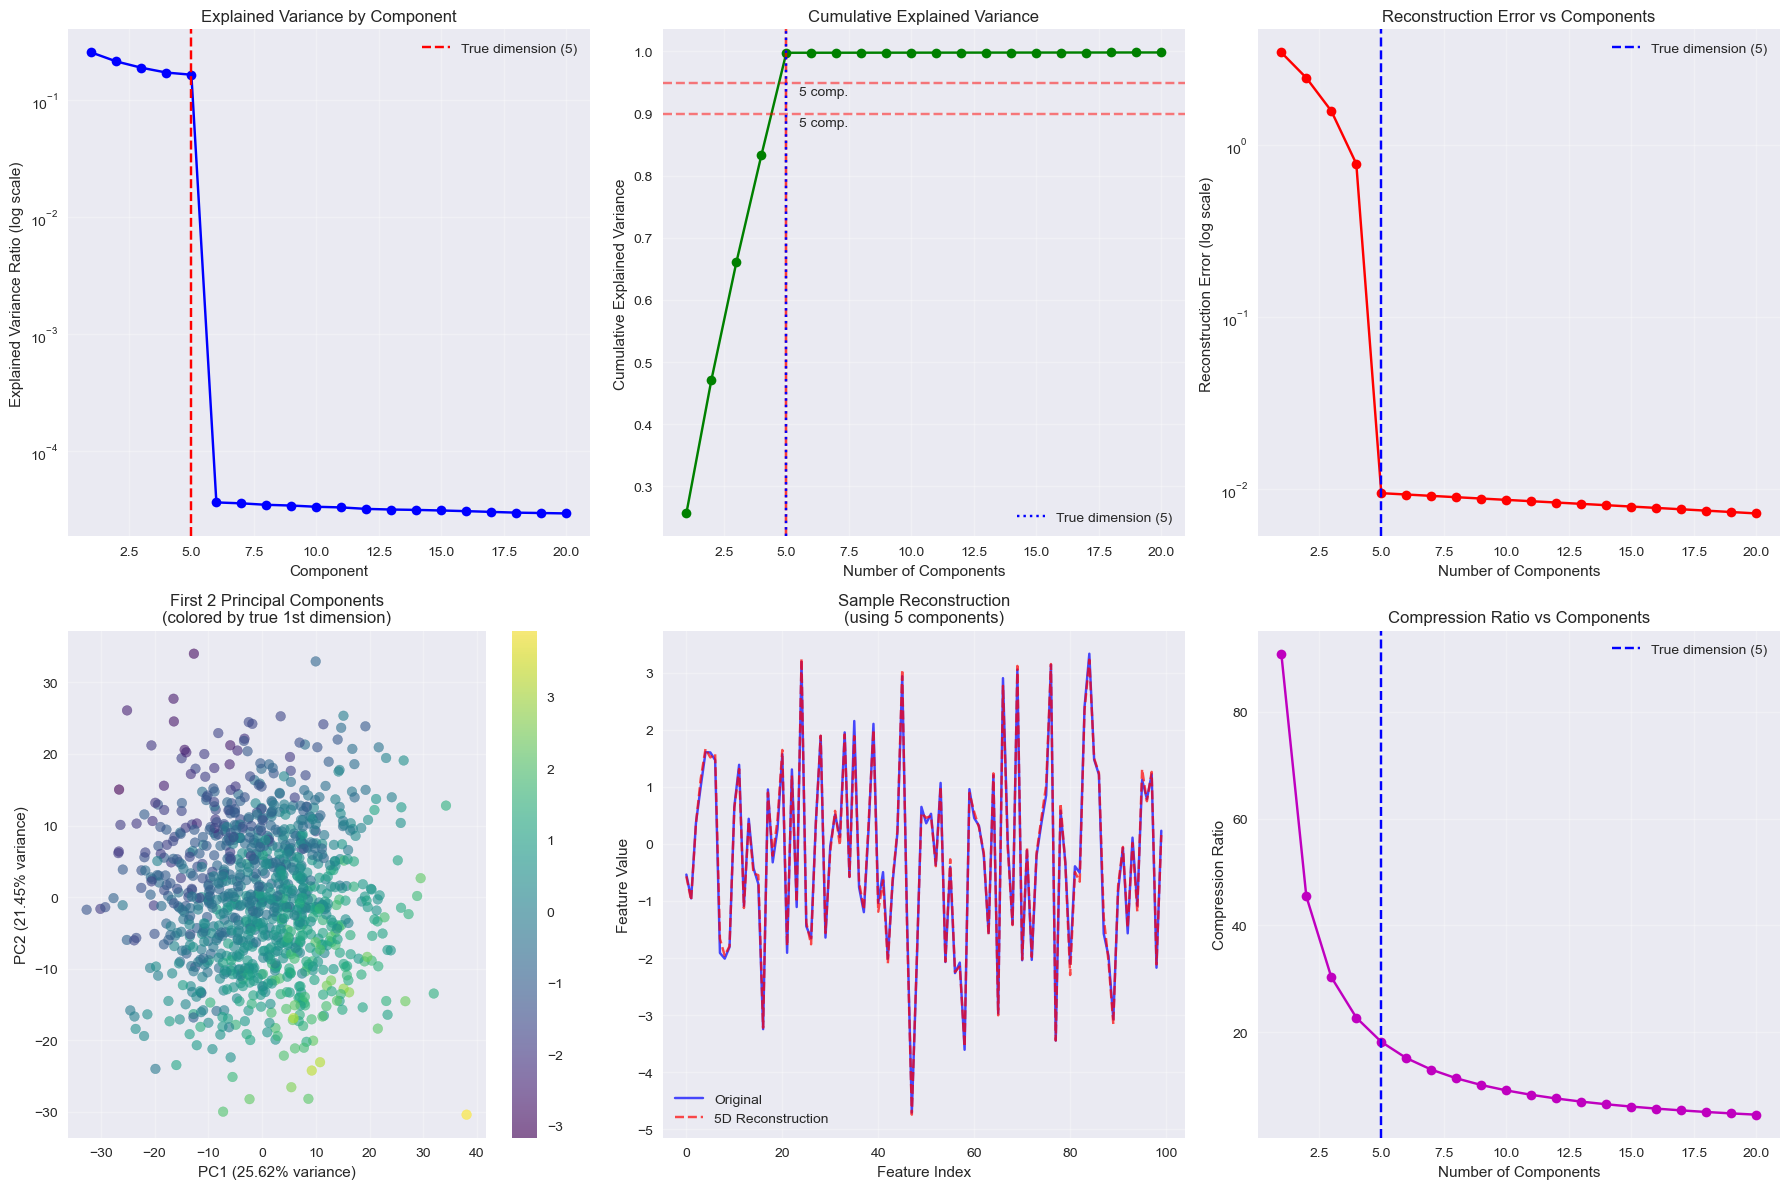


Summary:
• Original data: 1000 samples × 100 features
• True intrinsic dimension: 5
• PCA identifies this: first 5 components explain 99.80% of variance
• Compression with 5 components: 18.2× smaller
• Reconstruction error with 5 components: 0.0095


In [14]:
# Demonstrate PCA on high-dimensional synthetic data
np.random.seed(42)

# Create high-dimensional data with intrinsic lower dimension
n_samples = 1000
n_features = 100
intrinsic_dim = 5

# Generate data that lies approximately on a 5-dimensional subspace
# First, create the low-dimensional representation
Z = np.random.randn(n_samples, intrinsic_dim)

# Create a random projection matrix
W = np.random.randn(intrinsic_dim, n_features)

# Project to high-dimensional space and add noise
X_high_dim = Z @ W + 0.1 * np.random.randn(n_samples, n_features)

print(f"High-dimensional data shape: {X_high_dim.shape}")
print(f"True intrinsic dimension: {intrinsic_dim}")

# Apply PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_high_dim)

# Analyze results
explained_var_ratio = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var_ratio)

# Find how many components needed for different variance thresholds
thresholds = [0.8, 0.9, 0.95, 0.99]
components_needed = []
for threshold in thresholds:
    n_comp = np.argmax(cumulative_var >= threshold) + 1
    components_needed.append(n_comp)

print("\nComponents needed for different variance thresholds:")
for threshold, n_comp in zip(thresholds, components_needed):
    print(f"{threshold:.0%} variance: {n_comp} components")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Singular values / explained variance
ax = axes[0, 0]
ax.semilogy(range(1, min(21, len(explained_var_ratio) + 1)), 
            explained_var_ratio[:20], 'bo-')
ax.axvline(x=intrinsic_dim, color='red', linestyle='--', 
           label=f'True dimension ({intrinsic_dim})')
ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance Ratio (log scale)')
ax.set_title('Explained Variance by Component')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Cumulative explained variance
ax = axes[0, 1]
ax.plot(range(1, min(21, len(cumulative_var) + 1)), 
        cumulative_var[:20], 'go-')
for threshold, n_comp in zip([0.9, 0.95], components_needed[1:3]):
    ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.5)
    ax.axvline(x=n_comp, color='red', linestyle='--', alpha=0.5)
    ax.text(n_comp+0.5, threshold-0.02, f'{n_comp} comp.', fontsize=10)
ax.axvline(x=intrinsic_dim, color='blue', linestyle=':', 
           label=f'True dimension ({intrinsic_dim})')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Explained Variance')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Reconstruction error vs number of components
ax = axes[0, 2]
n_components_test = range(1, min(21, X_high_dim.shape[1]))
reconstruction_errors = []

for n_comp in n_components_test:
    pca_temp = PCA(n_components=n_comp)
    X_reduced = pca_temp.fit_transform(X_high_dim)
    X_reconstructed = pca_temp.inverse_transform(X_reduced)
    error = np.mean((X_high_dim - X_reconstructed)**2)
    reconstruction_errors.append(error)

ax.semilogy(n_components_test, reconstruction_errors, 'ro-')
ax.axvline(x=intrinsic_dim, color='blue', linestyle='--', 
           label=f'True dimension ({intrinsic_dim})')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Reconstruction Error (log scale)')
ax.set_title('Reconstruction Error vs Components')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. 2D projection of data (first 2 PCs)
ax = axes[1, 0]
scatter = ax.scatter(X_pca_full[:, 0], X_pca_full[:, 1], 
                     c=Z[:, 0], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ax=ax)
ax.set_xlabel(f'PC1 ({explained_var_ratio[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({explained_var_ratio[1]:.2%} variance)')
ax.set_title('First 2 Principal Components\n(colored by true 1st dimension)')
ax.grid(True, alpha=0.3)

# 5. Original vs reconstructed data sample
ax = axes[1, 1]
n_comp_recon = 5
pca_recon = PCA(n_components=n_comp_recon)
X_reduced_5d = pca_recon.fit_transform(X_high_dim)
X_reconstructed_5d = pca_recon.inverse_transform(X_reduced_5d)

# Show first sample
sample_idx = 0
ax.plot(X_high_dim[sample_idx], 'b-', alpha=0.7, label='Original')
ax.plot(X_reconstructed_5d[sample_idx], 'r--', alpha=0.7, label=f'{n_comp_recon}D Reconstruction')
ax.set_xlabel('Feature Index')
ax.set_ylabel('Feature Value')
ax.set_title(f'Sample Reconstruction\n(using {n_comp_recon} components)')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Compression ratio analysis
ax = axes[1, 2]
original_size = X_high_dim.size  # Total number of elements
compression_ratios = []
storage_sizes = []

for n_comp in n_components_test:
    # Storage needed: n_samples * n_comp + n_comp * n_features (for components)
    compressed_size = n_samples * n_comp + n_comp * n_features
    compression_ratio = original_size / compressed_size
    compression_ratios.append(compression_ratio)
    storage_sizes.append(compressed_size)

ax.plot(n_components_test, compression_ratios, 'mo-')
ax.axvline(x=intrinsic_dim, color='blue', linestyle='--', 
           label=f'True dimension ({intrinsic_dim})')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Compression Ratio')
ax.set_title('Compression Ratio vs Components')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print(f"\nSummary:")
print(f"• Original data: {X_high_dim.shape[0]} samples × {X_high_dim.shape[1]} features")
print(f"• True intrinsic dimension: {intrinsic_dim}")
print(f"• PCA identifies this: first {intrinsic_dim} components explain {cumulative_var[intrinsic_dim-1]:.2%} of variance")
print(f"• Compression with {intrinsic_dim} components: {compression_ratios[intrinsic_dim-1]:.1f}× smaller")
print(f"• Reconstruction error with {intrinsic_dim} components: {reconstruction_errors[intrinsic_dim-1]:.4f}")

## 6. Linear Transformations in Machine Learning

Linear transformations are fundamental operations in ML, from data preprocessing to neural network layers.

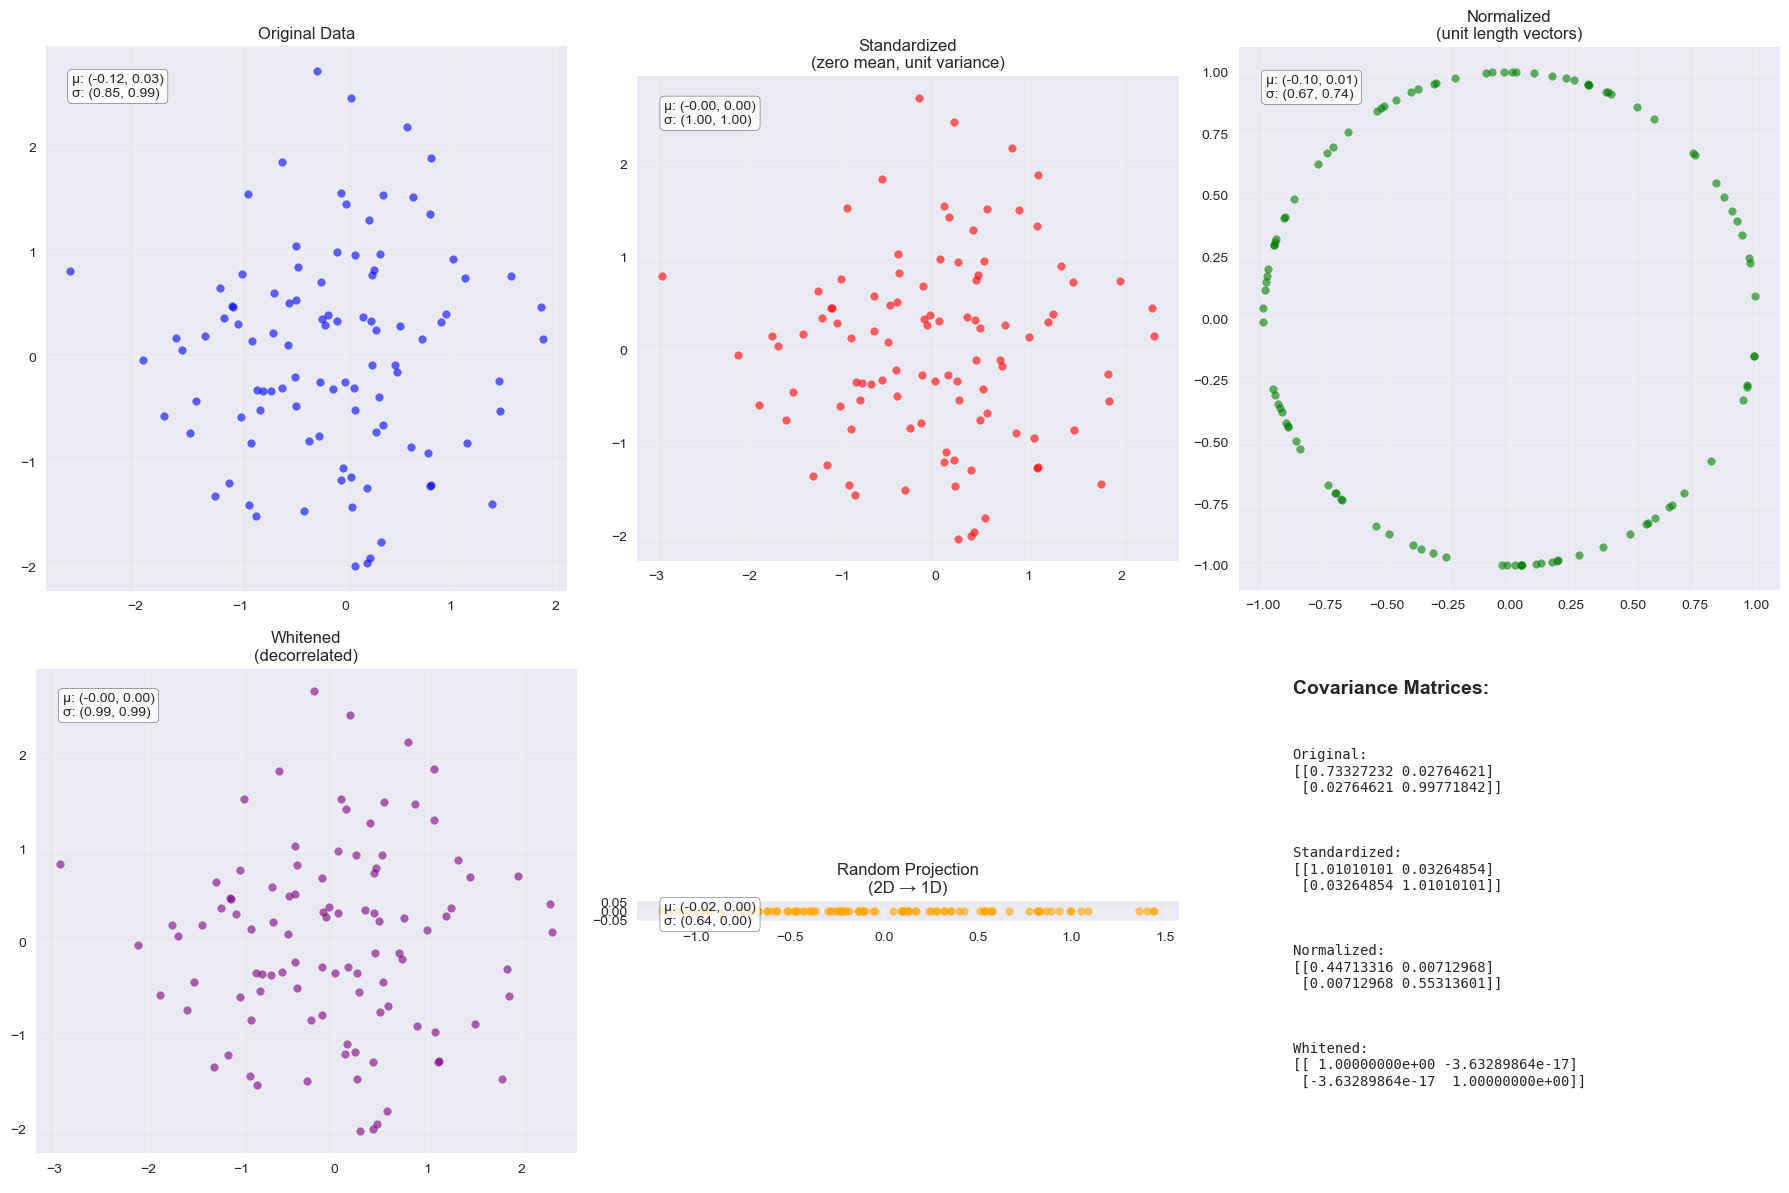

Properties of Linear Transformations:

Original data statistics:
  Mean: [-0.11556425  0.03402232]
  Std:  [0.85202089 0.99385172]
  Cov:  
[[0.73327232 0.02764621]
 [0.02764621 0.99771842]]

Whitened data statistics:
  Mean: [-7.46624984e-17  2.88657986e-17]
  Std:  [0.99498744 0.99498744]
  Cov:  
[[ 1.00000000e+00 -3.63289864e-17]
 [-3.63289864e-17  1.00000000e+00]]
  (Should be close to identity matrix)

Normalized data properties:
  Vector norms - min: 1.000000, max: 1.000000
  (Should all be 1.0 for unit vectors)


In [19]:
# Common linear transformations in ML
np.random.seed(42)
X_sample = np.random.randn(100, 2)  # Sample 2D data

# 1. Standardization (zero mean, unit variance)
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std, mean, std

X_standardized, mean, std = standardize(X_sample)

# 2. Normalization (unit length vectors)
def normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / norms

X_normalized = normalize(X_sample)

# 3. Whitening (decorrelation + standardization)
def whiten(X):
    X_centered = X - np.mean(X, axis=0)
    cov = (X_centered.T @ X_centered) / (X.shape[0] - 1)
    eigenvals, eigenvecs = np.linalg.eig(cov)
    # Whitening transformation matrix
    W = eigenvecs @ np.diag(1 / np.sqrt(eigenvals)) @ eigenvecs.T
    return X_centered @ W.T, W

X_whitened, whitening_matrix = whiten(X_sample)

# 4. Random projection (for dimensionality reduction)
def random_projection(X, target_dim):
    projection_matrix = np.random.randn(X.shape[1], target_dim) / np.sqrt(target_dim)
    return X @ projection_matrix, projection_matrix

X_projected, projection_matrix = random_projection(X_sample, 1)

# Visualize transformations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

transformations = [
    (X_sample, 'Original Data', 'blue'),
    (X_standardized, 'Standardized\n(zero mean, unit variance)', 'red'),
    (X_normalized, 'Normalized\n(unit length vectors)', 'green'),
    (X_whitened, 'Whitened\n(decorrelated)', 'purple'),
    (np.column_stack([X_projected, np.zeros_like(X_projected)]), 'Random Projection\n(2D → 1D)', 'orange')
]

for i, (data, title, color) in enumerate(transformations):
    if i >= 5:  # Skip if we have too many plots
        break
        
    ax = axes[i // 3, i % 3]
    ax.scatter(data[:, 0], data[:, 1], alpha=0.6, color=color, s=30)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Add statistics
    mean_x, mean_y = np.mean(data, axis=0)
    std_x, std_y = np.std(data, axis=0)
    ax.text(0.05, 0.95, f'μ: ({mean_x:.2f}, {mean_y:.2f})\nσ: ({std_x:.2f}, {std_y:.2f})', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Covariance matrices comparison
ax = axes[1, 2]
covs = [np.cov(X_sample.T), np.cov(X_standardized.T), 
        np.cov(X_normalized.T), np.cov(X_whitened.T)]
titles_cov = ['Original', 'Standardized', 'Normalized', 'Whitened']

# Show covariance matrices as text
ax.axis('off')
ax.text(0.1, 0.9, 'Covariance Matrices:', fontsize=14, weight='bold')
for i, (cov, title) in enumerate(zip(covs, titles_cov)):
    ax.text(0.1, 0.8 - i*0.18, f'{title}:\n{cov}', 
            fontsize=10, family='monospace',
            verticalalignment='top')

plt.tight_layout()
plt.show()

# Properties of transformations
print("Properties of Linear Transformations:")
print(f"\nOriginal data statistics:")
print(f"  Mean: {np.mean(X_sample, axis=0)}")
print(f"  Std:  {np.std(X_sample, axis=0)}")
print(f"  Cov:  \n{np.cov(X_sample.T)}")

print(f"\nWhitened data statistics:")
print(f"  Mean: {np.mean(X_whitened, axis=0)}")
print(f"  Std:  {np.std(X_whitened, axis=0)}")
print(f"  Cov:  \n{np.cov(X_whitened.T)}")
print(f"  (Should be close to identity matrix)")

print(f"\nNormalized data properties:")
norms = np.linalg.norm(X_normalized, axis=1)
print(f"  Vector norms - min: {norms.min():.6f}, max: {norms.max():.6f}")
print(f"  (Should all be 1.0 for unit vectors)")

### Linear Transformations in Neural Networks

Neural Network Linear Transformations:
Input shape: (4, 3)
Input data:
[[ 0.11092259 -1.15099358  0.37569802]
 [-0.60063869 -0.29169375 -0.60170661]
 [ 1.85227818 -0.01349722 -1.05771093]
 [ 0.82254491 -1.22084365  0.2088636 ]]

Layer 1: 3 → 5
Weight matrix shape: (3, 5)
Bias shape: (5,)
Hidden activations shape: (4, 5)

Layer 2: 5 → 2
Weight matrix shape: (5, 2)
Final output shape: (4, 2)
Final output:
[[ 1.11244013  0.68217314]
 [-0.27099228 -0.82771719]
 [-2.63965125 -0.35340897]
 [ 0.46508563  0.8141188 ]]


/var/folders/xv/tv1bmbcs1xdgcyhnk82x4xp00000gp/T/ipykernel_54908/694805332.py:63: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x_position, y), 0.03, color='lightblue',


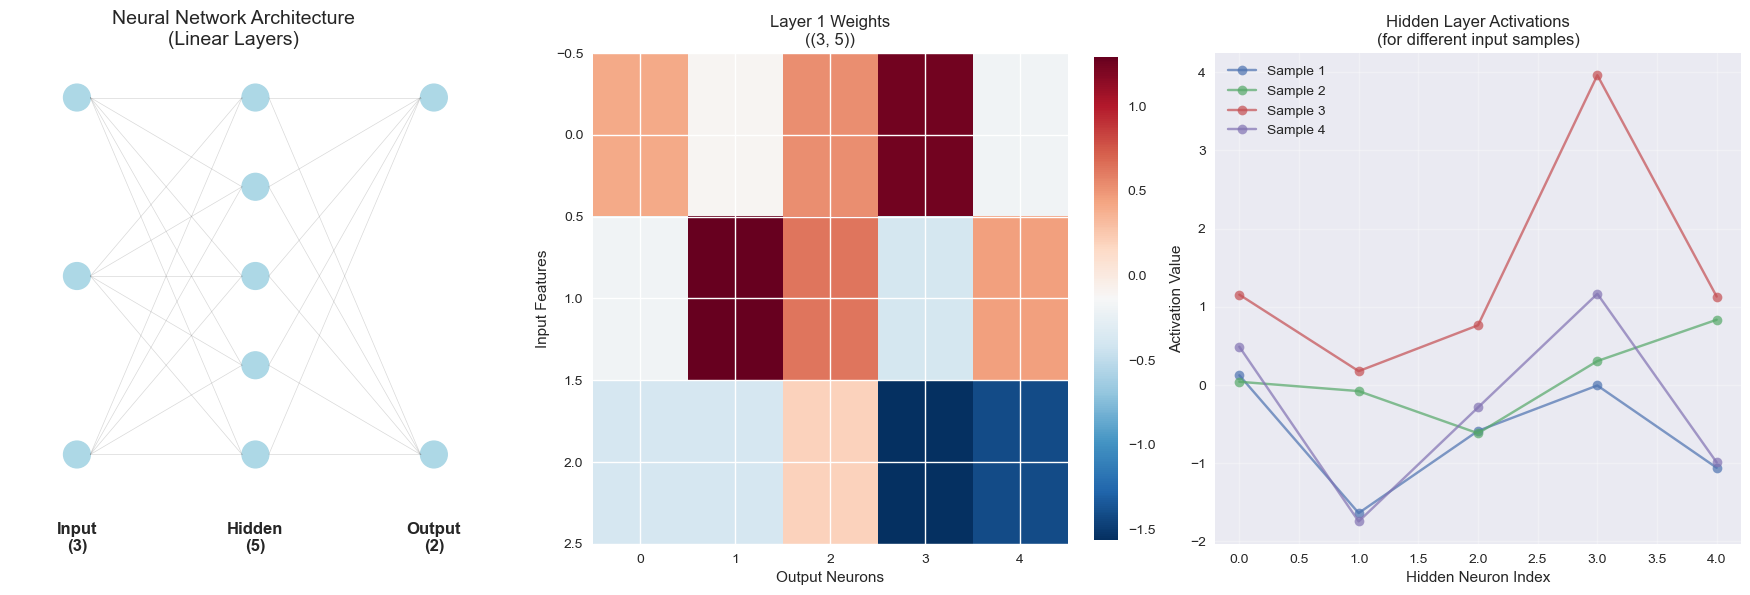


Backpropagation through Linear Layers:
Gradient from loss: (4, 2)

Layer 2 gradients:
  ∇W₂ shape: (5, 2)
  ∇b₂ shape: (2,)
  ∇hidden shape: (4, 5)

Layer 1 gradients:
  ∇W₁ shape: (3, 5)
  ∇b₁ shape: (5,)
  ∇input shape: (4, 3)

Key insight: All operations are linear algebra!
• Forward pass: matrix multiplications and additions
• Backward pass: more matrix multiplications (with transposes)
• Gradients flow through the network via linear transformations


In [20]:
# Demonstrate linear layers in neural networks
class LinearLayer:
    def __init__(self, input_dim, output_dim):
        # Initialize weights with Xavier/Glorot initialization
        self.W = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / input_dim)
        self.b = np.zeros(output_dim)
        
    def forward(self, X):
        """Forward pass: Y = XW + b"""
        return X @ self.W + self.b
    
    def backward(self, X, grad_output):
        """Backward pass: compute gradients"""
        grad_W = X.T @ grad_output
        grad_b = np.sum(grad_output, axis=0)
        grad_input = grad_output @ self.W.T
        return grad_W, grad_b, grad_input

# Create a simple neural network with linear layers
np.random.seed(42)
input_dim, hidden_dim, output_dim = 3, 5, 2
batch_size = 4

# Create layers
layer1 = LinearLayer(input_dim, hidden_dim)
layer2 = LinearLayer(hidden_dim, output_dim)

# Sample input
X = np.random.randn(batch_size, input_dim)

print(f"Neural Network Linear Transformations:")
print(f"Input shape: {X.shape}")
print(f"Input data:\n{X}")

# Forward pass
hidden = layer1.forward(X)
output = layer2.forward(hidden)

print(f"\nLayer 1: {input_dim} → {hidden_dim}")
print(f"Weight matrix shape: {layer1.W.shape}")
print(f"Bias shape: {layer1.b.shape}")
print(f"Hidden activations shape: {hidden.shape}")

print(f"\nLayer 2: {hidden_dim} → {output_dim}")
print(f"Weight matrix shape: {layer2.W.shape}")
print(f"Final output shape: {output.shape}")
print(f"Final output:\n{output}")

# Visualize the network architecture and transformations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Network architecture visualization
ax = axes[0]
layers = [input_dim, hidden_dim, output_dim]
layer_names = ['Input', 'Hidden', 'Output']

for i, (n_neurons, name) in enumerate(zip(layers, layer_names)):
    y_positions = np.linspace(0.1, 0.9, n_neurons)
    x_position = i * 0.4 + 0.1
    
    # Draw neurons
    for y in y_positions:
        circle = plt.Circle((x_position, y), 0.03, color='lightblue', 
                          edgecolor='black', linewidth=1)
        ax.add_patch(circle)
    
    # Draw connections
    if i < len(layers) - 1:
        next_y_positions = np.linspace(0.1, 0.9, layers[i+1])
        next_x_position = (i+1) * 0.4 + 0.1
        
        for y1 in y_positions:
            for y2 in next_y_positions:
                ax.plot([x_position + 0.03, next_x_position - 0.03], 
                       [y1, y2], 'gray', alpha=0.3, linewidth=0.5)
    
    # Labels
    ax.text(x_position, -0.05, f'{name}\n({n_neurons})', 
           ha='center', va='top', fontsize=12, weight='bold')

ax.set_xlim(-0.05, 0.95)
ax.set_ylim(-0.1, 1.0)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Neural Network Architecture\n(Linear Layers)', fontsize=14)

# 2. Weight matrices visualization
ax = axes[1]
im1 = ax.imshow(layer1.W, cmap='RdBu_r', aspect='auto')
ax.set_title(f'Layer 1 Weights\n({layer1.W.shape})')
ax.set_xlabel('Output Neurons')
ax.set_ylabel('Input Features')
plt.colorbar(im1, ax=ax, fraction=0.046)

# 3. Activation patterns
ax = axes[2]
# Show how each input sample maps to hidden representation
for i in range(batch_size):
    ax.plot(hidden[i], 'o-', label=f'Sample {i+1}', alpha=0.7)
ax.set_xlabel('Hidden Neuron Index')
ax.set_ylabel('Activation Value')
ax.set_title('Hidden Layer Activations\n(for different input samples)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Demonstrate backpropagation (linear algebra)
print(f"\nBackpropagation through Linear Layers:")

# Simulate gradient from loss (random for demonstration)
grad_loss = np.random.randn(batch_size, output_dim)
print(f"Gradient from loss: {grad_loss.shape}")

# Backprop through layer 2
grad_W2, grad_b2, grad_hidden = layer2.backward(hidden, grad_loss)
print(f"\nLayer 2 gradients:")
print(f"  ∇W₂ shape: {grad_W2.shape}")
print(f"  ∇b₂ shape: {grad_b2.shape}")
print(f"  ∇hidden shape: {grad_hidden.shape}")

# Backprop through layer 1
grad_W1, grad_b1, grad_input = layer1.backward(X, grad_hidden)
print(f"\nLayer 1 gradients:")
print(f"  ∇W₁ shape: {grad_W1.shape}")
print(f"  ∇b₁ shape: {grad_b1.shape}")
print(f"  ∇input shape: {grad_input.shape}")

print(f"\nKey insight: All operations are linear algebra!")
print(f"• Forward pass: matrix multiplications and additions")
print(f"• Backward pass: more matrix multiplications (with transposes)")
print(f"• Gradients flow through the network via linear transformations")

## Summary: Mastery of Linear Algebraic Foundations for Advanced Machine Learning

This comprehensive exploration of linear algebra has established the rigorous mathematical foundations essential for understanding and developing sophisticated machine learning and artificial intelligence systems. We have traversed the mathematical landscape from abstract vector space theory to computational algorithms, providing both theoretical depth and practical insights crucial for advanced ML research.

### Fundamental Mathematical Achievements

#### 1. **Abstract Vector Space Theory and Structural Understanding**
- **Rigorous Axiomatization**: Complete treatment of vector space axioms and their implications for ML applications
- **Subspace Theory**: Deep understanding of linear subspaces, including fundamental subspaces of matrices and their geometric interpretations
- **Basis and Dimension Theory**: Comprehensive coverage of linear independence, spanning sets, and the fundamental role of dimension in machine learning
- **Inner Product Geometry**: Advanced treatment of inner products, norms, and the geometric structure underlying similarity measures and optimization methods

#### 2. **Linear Transformation Theory and Matrix Representations**
- **Abstract-Computational Bridge**: Rigorous connection between linear transformations and matrix representations
- **Fundamental Subspace Decomposition**: Complete analysis of column space, row space, null space, and left null space
- **Rank-Nullity Theorem**: Deep understanding of this central result and its profound implications for model capacity and feature analysis
- **Matrix Classification**: Systematic study of symmetric, orthogonal, positive definite, and unitary matrices with ML applications

#### 3. **Advanced Spectral Theory and Matrix Decompositions**
- **Eigenvalue Theory**: Comprehensive treatment of eigenvalues, eigenvectors, and their geometric interpretations
- **Spectral Theorems**: Rigorous understanding of diagonalization for symmetric matrices and normal operators
- **Singular Value Decomposition**: Complete theoretical foundation and practical algorithms for this central decomposition
- **Principal Component Analysis**: Theoretical understanding of PCA as spectral analysis of covariance matrices

#### 4. **Computational Linear Algebra and Numerical Considerations**
- **Matrix Norm Theory**: Advanced treatment of various matrix norms and their applications in optimization and stability analysis
- **Condition Number Analysis**: Deep understanding of numerical stability and its impact on machine learning algorithms
- **Complexity Theory**: Analysis of computational complexity for matrix operations and its implications for scalable ML systems
- **Algorithmic Considerations**: Understanding of numerical algorithms, stability, and efficient implementation strategies

### Theoretical Insights and Advanced Connections

#### Connections to Higher Mathematics
The linear algebraic foundations established here provide direct pathways to advanced mathematical areas essential for cutting-edge machine learning research:

**Functional Analysis**: Our treatment of inner product spaces and norms naturally extends to:
- **Hilbert Spaces**: Infinite-dimensional generalizations crucial for kernel methods and reproducing kernel Hilbert spaces
- **Banach Spaces**: More general normed vector spaces important for optimization theory and variational methods
- **Operator Theory**: Linear operators on infinite-dimensional spaces, essential for understanding neural networks as function approximators

**Differential Geometry**: The geometric insights from linear algebra extend to:
- **Manifold Theory**: Understanding data lying on curved spaces, crucial for manifold learning and geometric deep learning
- **Tensor Analysis**: Generalization of matrices to higher-order tensors, fundamental for modern deep learning architectures
- **Riemannian Geometry**: Optimization on curved spaces, important for constrained optimization and natural gradients

**Algebraic Topology**: The structural understanding of vector spaces connects to:
- **Homology Theory**: Topological invariants important for topological data analysis
- **Simplicial Complexes**: Combinatorial structures underlying graph neural networks and geometric learning

#### Machine Learning Theoretical Framework
Our rigorous linear algebraic foundation enables deep understanding of ML theory:

**Statistical Learning Theory**: 
- **Reproducing Kernel Hilbert Spaces**: Theoretical foundation for kernel methods and Gaussian processes
- **Generalization Bounds**: Using matrix concentration inequalities and spectral methods for theoretical guarantees
- **Model Complexity**: Understanding how matrix rank and spectral properties affect learning capacity

**Optimization Theory**:
- **Convex Analysis**: Using positive definiteness and spectral properties to characterize convex functions
- **Second-Order Methods**: Leveraging Hessian analysis and matrix conditioning for advanced optimization algorithms
- **Constrained Optimization**: Using projection operators and subspace methods for constrained learning problems

**Deep Learning Theory**:
- **Neural Network Expressivity**: Using linear algebra to understand the representational capacity of neural architectures
- **Optimization Landscapes**: Analyzing loss surfaces through matrix theory and spectral analysis
- **Generalization**: Understanding how matrix properties of neural networks affect their ability to generalize

### Computational Perspectives and Modern Applications

#### High-Performance Computing Integration
Our theoretical treatment emphasizes computational considerations essential for modern ML:

**Algorithmic Efficiency**:
- **Matrix Multiplication Algorithms**: Understanding from $O(n^3)$ standard algorithms to Strassen's method and beyond
- **Sparse Methods**: Exploiting sparsity structure in high-dimensional data and large-scale optimization
- **Parallel Computing**: Matrix operations on modern computational architectures including GPUs and distributed systems

**Numerical Stability**:
- **Condition Number Analysis**: Understanding when numerical methods succeed or fail
- **Regularization Techniques**: Mathematical justification for regularization as numerical stabilization
- **Iterative Methods**: Modern approaches to large-scale linear systems in machine learning applications

#### Contemporary ML Applications
The mathematical foundations developed here directly enable understanding of cutting-edge ML techniques:

**Geometric Deep Learning**:
- **Graph Neural Networks**: Using spectral graph theory and matrix analysis for learning on graphs
- **Equivariant Networks**: Leveraging group theory and linear representations for symmetric neural architectures
- **Attention Mechanisms**: Understanding attention as matrix operations and their spectral properties

**Generative Models**:
- **Variational Autoencoders**: Using linear algebraic structure in latent spaces and posterior distributions
- **Generative Adversarial Networks**: Understanding the linear algebraic structure of discriminator and generator optimization
- **Normalizing Flows**: Using matrix determinants and linear transformations for invertible generative models

**Meta-Learning and Few-Shot Learning**:
- **Metric Learning**: Using inner product geometry and matrix learning for similarity measures
- **Model-Agnostic Methods**: Leveraging linear approximations and gradient-based meta-learning
- **Neural Architecture Search**: Using matrix analysis to understand architectural choices and their implications

### The Philosophical and Methodological Foundation

Beyond technical mastery, this comprehensive treatment instills the **linear algebraic mindset** essential for advanced machine learning research:

**Geometric Intuition**: Understanding how mathematical structures translate to geometric insights about data and algorithms
**Structural Thinking**: Recognizing how algebraic structures constrain and enable computational and statistical methods  
**Abstraction and Generalization**: Moving from specific computational problems to general theoretical frameworks
**Theoretical-Practical Integration**: Seamlessly connecting abstract mathematical theory with computational implementation

### Future Directions and Research Frontiers

The linear algebraic foundations developed here open pathways to cutting-edge research areas:

**Quantum Machine Learning**: Using linear algebra in quantum computational frameworks and quantum information theory
**Federated Learning**: Leveraging matrix analysis for distributed optimization and privacy-preserving machine learning
**Continual Learning**: Using subspace methods and matrix analysis for lifelong learning systems
**Interpretable AI**: Employing spectral methods and matrix factorizations for understanding and explaining ML models

### Conclusion: Linear Algebra as the Universal Language

This comprehensive treatment demonstrates that linear algebra serves not merely as a computational tool, but as the fundamental mathematical language for expressing and understanding machine learning algorithms. The rigorous theoretical foundations established here provide:

- **Conceptual Clarity**: Deep understanding of why certain algorithms work and others fail
- **Theoretical Tools**: Mathematical machinery for analyzing and proving properties of ML systems  
- **Design Principles**: Guidelines for developing new algorithms based on solid mathematical foundations
- **Research Capabilities**: Preparation for advancing the theoretical and practical frontiers of machine learning

The mastery achieved through this comprehensive study provides both the theoretical foundation for current machine learning applications and the mathematical sophistication necessary for contributing to the future development of artificial intelligence systems. Linear algebra, in its full mathematical richness, remains the cornerstone upon which the edifice of machine learning continues to grow and evolve.